In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass, field, replace
from typing import Dict, Optional, Tuple

import numpy as np
import pandas as pd
from scipy.integrate import solve_bvp
from scipy.optimize import root, brentq
from IPython.display import display

def show_table(df, title=None, formats=None, status_columns=None):
    styler = df.style.hide(axis='index')
    if title:
        styler = styler.set_caption(title)
    if formats:
        styler = styler.format(formats, na_rep='—')
    styler = styler.set_table_styles([
        {'selector':'caption','props':[('caption-side','top'),('font-size','15px'),('font-weight','600'),('text-align','left'),('padding','6px 0 8px 0')]},
        {'selector':'th','props':[('font-weight','600'),('text-align','left'),('padding','6px 10px'),('border-bottom','2px solid #999')]},
        {'selector':'td','props':[('padding','5px 10px'),('border-bottom','1px solid #ddd'),('vertical-align','top')]},
    ])
    for col in (status_columns or []):
        if col in df.columns:
            styler = styler.map(lambda v: 'font-weight:700' if str(v).upper() in {'PASS','FAIL','FEASIBLE','INFEASIBLE','FAILED'} else '', subset=[col])
    display(styler)

def pass_fail(value):
    return 'PASS' if bool(value) else 'FAIL'

SPECIES = ["H2","CO","CO2","CH4","N2","H2O","CH3OH","C2H2","C2H4","C2H6","C6H6","H2S"]
REACTOR_SPECIES = SPECIES[:-1]
REACTIVE_SPECIES = ["H2","CO","CO2","H2O","CH3OH"]
INERT_SPECIES = ["CH4","N2","C2H2","C2H4","C2H6","C6H6"]

MW = {
    "H2":2.01588,"CO":28.0101,"CO2":44.0095,"CH4":16.0425,"N2":28.0134,
    "H2O":18.01528,"CH3OH":32.04186,"C2H2":26.0373,"C2H4":28.0532,
    "C2H6":30.0690,"C6H6":78.1118,"H2S":34.0809,
}

CP_MASS = {
    "H2":14.5,"CO":1.05,"CO2":0.98,"CH4":2.69,"N2":1.05,"H2O":1.93,
    "CH3OH":1.73,"C2H2":2.02,"C2H4":2.05,"C2H6":2.37,"C6H6":1.61,"H2S":1.05,
}

CP_MOLAR_R = {
    "H2":29.3,"CO":30.5,"CO2":44.5,"CH4":48.0,"N2":30.0,"H2O":35.5,
    "CH3OH":55.0,"C2H2":55.0,"C2H4":65.0,"C2H6":75.0,"C6H6":105.0,
}

TC = {
    "H2":33.145,"CO":132.86,"CO2":304.1282,"CH4":190.564,"N2":126.192,
    "H2O":647.096,"CH3OH":512.60,"C2H2":308.30,"C2H4":282.35,
    "C2H6":305.32,"C6H6":562.02,"H2S":373.10,
}
PC = {
    "H2":12.964,"CO":34.94,"CO2":73.773,"CH4":45.99,"N2":33.958,
    "H2O":220.64,"CH3OH":80.90,"C2H2":61.40,"C2H4":50.41,
    "C2H6":48.72,"C6H6":48.94,"H2S":89.63,
}
OMEGA = {
    "H2":-0.219,"CO":0.0497,"CO2":0.22394,"CH4":0.01142,"N2":0.0372,
    "H2O":0.3443,"CH3OH":0.565,"C2H2":0.187,"C2H4":0.0865,
    "C2H6":0.0995,"C6H6":0.2103,"H2S":0.100,
}
KIJ_USER = {
    ("CO","CO2"):0.1164,("CO","H2"):-7.0e-4,("CO","H2O"):-0.5594,
    ("CO","CH4"):2.04e-2,("CO","N2"):1.30e-2,("CO","CH3OH"):0.0,
    ("CO2","H2"):0.1164,("CO2","H2O"):-0.12155,("CO2","CH4"):9.56e-2,
    ("CO2","N2"):-1.71e-2,("CO2","CH3OH"):1.70e-2,
    ("H2","H2O"):-0.7544,("H2","CH4"):1.00e-4,("H2","N2"):-1.00e-3,
    ("H2","CH3OH"):0.0,("H2O","CH4"):0.5,("H2O","N2"):-0.69648,
    ("H2O","CH3OH"):-9.00e-2,("CH4","N2"):3.12e-2,
    ("CH4","CH3OH"):-3.50e-2,("N2","CH3OH"):-0.2141,
}
R = 8.314462618
R_EOS = 0.08314462618

FRESH_342 = pd.Series({
    "H2":1244.259,"CO":8011.277,"CO2":572.267,"CH4":340.545,"N2":18.857,
    "H2O":0.0,"CH3OH":0.0,"C2H2":6.020,"C2H4":73.309,"C2H6":0.314,
    "C6H6":0.455,"H2S":0.009,
}, dtype=float).reindex(SPECIES, fill_value=0.0)

R402_FEED_BASE = pd.Series({
    "H2":3783.344,"CO":15809.452,"CO2":4703.471,"CH4":7887.074,"N2":455.726,
    "H2O":1.265,"CH3OH":423.206,"C2H2":78.953,"C2H4":1316.273,
    "C2H6":5.568,"C6H6":0.509,"H2S":0.0,
}, dtype=float).reindex(SPECIES, fill_value=0.0)
R402_OUT_BASE = pd.Series({
    "H2":2639.9851464843246,"CO":8093.463185281530,"CO2":4465.339646381825,
    "CH4":7887.074,"N2":455.726,"H2O":98.74402185233754,"CH3OH":9423.206,
    "C2H2":78.953,"C2H4":1316.273,"C2H6":5.568,"C6H6":0.509,"H2S":0.0,
}, dtype=float).reindex(SPECIES, fill_value=0.0)
R402_DELTA_BASE = R402_OUT_BASE - R402_FEED_BASE

BASE_RECYCLE_GUESS = pd.Series({
    "H2":2402.321454,"CO":6967.444511,"CO2":3903.531994,"CH4":7428.374799,
    "N2":439.149356,"H2O":1.109445,"CH3OH":410.165354,"C2H2":71.502516,
    "C2H4":1227.326356,"C2H6":4.706530,"C6H6":0.051617,"H2S":0.013271,
}, dtype=float).reindex(SPECIES, fill_value=0.0)

@dataclass
class ProcessConfig:

    T_R402_in_C: float = 250.0
    T_R402_utility_C: float = 240.0
    T_S401_C: float = 32.0
    P_S401_bar: float = 48.1743722918890
    purge_frac: float = 0.04

    P_R402_in_bar: float = 48.96
    P_recycle_discharge_bar: float = 48.963
    eta_is_comp: float = 0.75
    T_fresh_342_C: float = 40.0
    P_fresh_342_bar: float = 48.963

    product_tolerance_fraction: float = 0.02
    total_inert_molfrac_max: float = 0.25
    R402_Tmax_C: float = 280.0
    R402_dP_max_bar: float = 0.50

    inner_tol: float = 1e-8
    extent_root_tol: float = 1e-7
    extent_root_maxfev: int = 30
    mass_closure_abs_tol_kg_h: float = 1e-3
    reactor_axial_steps_screening: int = 27
    reactor_axial_steps_verification: int = 50

@dataclass
class SensitivityRanges:
    T_R402_in_C: tuple = (240.0, 245.0, 250.0, 255.0, 260.0)
    T_R402_utility_C: tuple = (230.0, 235.0, 240.0, 245.0, 250.0)
    T_S401_C: tuple = (25.0, 30.0, 32.0, 35.0, 40.0)
    P_S401_bar: tuple = (44.0, 46.0, 47.0, 48.0, 48.1743722918890)
    purge_frac: tuple = (0.02, 0.03, 0.04, 0.05, 0.06)

@dataclass
class FixedEquipment:

    R401_ID_m: float = 0.950
    R401_bed_height_m: float = 1.300
    R401_bed_volume_m3: float = 0.921
    R401_sorbent_kg: float = 1059.7
    R401_pellet_m: float = 0.004
    R401_voidage: float = 0.40
    R401_mu_Pa_s: float = 2.50e-5
    R401_allow_dP_bar: float = 0.10
    R401_H2S_out_ppmv: float = 0.10
    R401_working_S_capacity: float = 0.14

    R402_N_tubes: int = 1565
    R402_tube_ID_m: float = 0.040
    R402_tube_OD_m: float = 0.044
    R402_bed_length_m: float = 5.981
    R402_catalyst_particle_m: float = 0.005
    R402_particle_density: float = 1775.0
    R402_voidage: float = 0.50

    @property
    def R402_catalyst_kg(self) -> float:
        """Catalyst charge derived directly from the current reactor geometry."""
        A_tube = math.pi*self.R402_tube_ID_m**2/4.0
        return (
            self.R402_N_tubes*A_tube*self.R402_bed_length_m
            *(1.0-self.R402_voidage)*self.R402_particle_density
        )

    E401_do: float = 0.030
    E401_di: float = 0.026
    E401_Nt: int = 272
    E401_L: float = 4.88
    E401_Np: int = 4
    E401_Ns: int = 2
    E401_Ds: float = 0.838
    E401_area: float = 125.10

    E402_do: float = 0.030
    E402_di: float = 0.026
    E402_Nt: int = 47
    E402_L: float = 2.44
    E402_Np: int = 1
    E402_Ds: float = 0.3786

    E403_do: float = 0.038
    E403_di: float = 0.034
    E403_Nt: int = 164
    E403_L: float = 4.88
    E403_Np: int = 2
    E403_Ds: float = 0.8093198089272822

    E404_do: float = 0.020
    E404_di: float = 0.016
    E404_Nt: int = 972
    E404_L: float = 4.88
    E404_Np: int = 4
    E404_Ds: float = 0.9606
    E404_area: float = 298.03

CFG = ProcessConfig()
RANGES = SensitivityRanges()
EQ = FixedEquipment()

def kmol_h(s: pd.Series) -> pd.Series:
    return pd.Series({i: float(s.get(i,0.0))/MW[i] for i in SPECIES})

def mix_cp_mass(s: pd.Series) -> float:
    m = float(s.sum())
    return sum(float(s.get(i,0.0))*CP_MASS[i] for i in SPECIES)/max(m,1e-30)

def mix_temperature_C(a, Ta, b, Tb):
    Ca=float(a.sum())*mix_cp_mass(a); Cb=float(b.sum())*mix_cp_mass(b)
    return (Ca*Ta+Cb*Tb)/max(Ca+Cb,1e-30)

def total_inert_molfrac(s: pd.Series) -> float:
    n=kmol_h(s); return float(n[INERT_SPECIES].sum()/max(n.sum(),1e-30))

def stoichiometric_number(s: pd.Series) -> float:
    n=kmol_h(s); den=n['CO']+n['CO2']; return float((n['H2']-n['CO2'])/max(den,1e-30))

_ix={s:i for i,s in enumerate(SPECIES)}
KIJ=np.zeros((len(SPECIES),len(SPECIES)))
for (a,b),v in KIJ_USER.items():
    KIJ[_ix[a],_ix[b]]=KIJ[_ix[b],_ix[a]]=v

def alpha_bm(T,s):
    Tr=T/TC[s]; w=OMEGA[s]; m=0.48508+1.55171*w-0.15613*w*w
    if Tr<=1.0: return (1+m*(1-math.sqrt(Tr)))**2
    d=1+m/2; c=1-1/d
    return math.exp(c*(1-Tr**d))**2

def rks_bm_phi(comp,T,P_bar,phase='V'):
    x=np.clip(np.asarray(comp,float),0,None); x=x/x.sum()
    ai=np.array([0.42747*R_EOS**2*TC[s]**2/PC[s]*alpha_bm(T,s) for s in SPECIES])
    bi=np.array([0.08664*R_EOS*TC[s]/PC[s] for s in SPECIES])
    aij=np.sqrt(np.outer(ai,ai))*(1-KIJ); am=float(x@aij@x); bm=float(x@bi)
    A=am*P_bar/(R_EOS**2*T**2); B=bm*P_bar/(R_EOS*T)
    roots=np.roots([1,-1,A-B-B**2,-A*B]); real=np.sort(roots[np.abs(roots.imag)<1e-8].real)
    valid=real[real>B+1e-12]
    if len(valid)==0: raise RuntimeError('No valid RKS-BM Z root')
    Z=float(valid[0] if phase.upper()=='L' else valid[-1]); sa=aij@x
    lnphi=(bi/bm)*(Z-1)-np.log(Z-B)-(A/B)*(2*sa/am-bi/bm)*np.log(1+B/Z)
    return np.exp(np.clip(lnphi,-100,100)),Z

def rks_bm_Z_gas(T,P_bar,comp):
    return rks_bm_phi(comp,T,P_bar,'V')[1]

def rachford_rice_beta(z,K,tol=1e-12):
    def f(beta): return float(np.sum(z*(K-1)/(1+beta*(K-1))))
    if f(0)<=0:return 0.0
    if f(1)>=0:return 1.0
    return brentq(f,0.0,1.0,xtol=tol)

def flash_S401(feed,T_C,P_bar,tol=1e-9,max_iter=250,damping=0.35):
    feed=feed.reindex(SPECIES,fill_value=0.0).astype(float)
    mw=np.array([MW[s] for s in SPECIES]); n=feed.values/mw; F=float(n.sum()); z=n/F; T=T_C+273.15
    K=np.array([PC[s]/P_bar*np.exp(5.373*(1+OMEGA[s])*(1-TC[s]/T)) for s in SPECIES])
    K=np.clip(K,1e-10,1e10)
    for it in range(1,max_iter+1):
        beta=rachford_rice_beta(z,K); den=1+beta*(K-1); x=z/den; y=K*x; x/=x.sum(); y/=y.sum()
        phiL,ZL=rks_bm_phi(x,T,P_bar,'L'); phiV,ZV=rks_bm_phi(y,T,P_bar,'V')
        Knew=np.clip(phiL/phiV,1e-12,1e12); err=float(np.max(np.abs(np.log(Knew/K))))
        K=np.exp((1-damping)*np.log(K)+damping*np.log(Knew))
        if err<tol: break
    else: raise RuntimeError('S-401 VLE flash did not converge')
    beta=rachford_rice_beta(z,K); den=1+beta*(K-1); x=z/den; y=K*x; x/=x.sum(); y/=y.sum()
    L=(1-beta)*F; V=beta*F
    liq=pd.Series(x*L*mw,index=SPECIES); vap=pd.Series(y*V*mw,index=SPECIES)
    liq += feed-(liq+vap)
    return vap,liq,dict(beta=beta,K=pd.Series(K,index=SPECIES),x=pd.Series(x,index=SPECIES),y=pd.Series(y,index=SPECIES),iterations=it,ZL=ZL,ZV=ZV)

def run_R401(cfg:ProcessConfig, feed=FRESH_342, eq:FixedEquipment=EQ):
    out=feed.copy(); n_other=sum(feed[s]/MW[s] for s in SPECIES if s!='H2S')
    ytar=eq.R401_H2S_out_ppmv*1e-6; out['H2S']=ytar*n_other/(1-ytar)*MW['H2S']
    area=math.pi*eq.R401_ID_m**2/4
    n=kmol_h(feed); y=(n/n.sum()).values; Z=rks_bm_Z_gas(250+273.15,cfg.P_R402_in_bar,y)
    actual_m3_h=float(n.sum())*R*(250+273.15)*Z/(cfg.P_R402_in_bar*100.0)

    actual_m3_h=float(n.sum())*0.08314462618*(250+273.15)*Z/cfg.P_R402_in_bar
    rho=float(feed.sum())/actual_m3_h; u=actual_m3_h/3600/area
    e=eq.R401_voidage; dp=eq.R401_pellet_m; mu=eq.R401_mu_Pa_s
    dP_dL=150*mu*(1-e)**2/(e**3*dp**2)*u + 1.75*rho*(1-e)/(e**3*dp)*u*u
    dP_bar=dP_dL*eq.R401_bed_height_m/1e5
    h2s_removed=max(feed['H2S']-out['H2S'],0.0); Sfrac=32.065/MW['H2S']
    S_kg_h=h2s_removed*Sfrac; life_y=eq.R401_sorbent_kg*eq.R401_working_S_capacity/max(S_kg_h,1e-30)/(24*365.25)
    return out,dict(dP_bar=dP_bar,u_m_s=u,rho_kg_m3=rho,Z=Z,H2S_out_ppmv=eq.R401_H2S_out_ppmv,service_life_y=life_y,pressure_ok=dP_bar<=eq.R401_allow_dP_bar)

RIDX={s:i for i,s in enumerate(REACTOR_SPECIES)}
RMW=np.array([MW[s] for s in REACTOR_SPECIES]); RMWkg=RMW/1000
RCP=np.array([CP_MOLAR_R[s] for s in REACTOR_SPECIES])
RKIJ=np.zeros((len(REACTOR_SPECIES),len(REACTOR_SPECIES)))
for (a,b),v in KIJ_USER.items():
    if a in RIDX and b in RIDX: RKIJ[RIDX[a],RIDX[b]]=RKIJ[RIDX[b],RIDX[a]]=v
RNU=np.zeros((len(REACTOR_SPECIES),2))
for s,v in {"CO2":-1,"H2":-3,"CH3OH":1,"H2O":1}.items():RNU[RIDX[s],0]=v
for s,v in {"CO2":-1,"H2":-1,"CO":1,"H2O":1}.items():RNU[RIDX[s],1]=v
RREACTIVE=[RIDX[s] for s in REACTIVE_SPECIES]
DH298=np.array([-49.5e3,+41.2e3]); DCP=RNU.T@RCP
DV={"H2":7.07,"CO":18.9,"CO2":26.9,"H2O":12.7,"CH3OH":29.9,"CH4":24.42,"N2":17.9,"C2H2":36.96,"C2H4":40.92,"C2H6":44.88,"C6H6":90.68}
MU_G=2.50e-5; EPS_TAU=0.123; RPORE=10e-9; KNUD=4/3
RFI=1e-4; RFO=2e-4; K_WALL=26.1

_WSAT_T_C = np.array([200.0,220.0,240.0,260.0,280.0,300.0])
_WSAT = {
    'P_sat_bar': np.array([15.538,23.180,33.440,46.880,64.120,85.810]),
    'rho_l_kg_m3': np.array([864.3,840.3,813.7,783.7,750.8,713.8]),
    'rho_v_kg_m3': np.array([7.852,11.60,16.73,23.69,33.15,46.15]),
    'hfg_J_kg': np.array([1941e3,1859e3,1767e3,1663e3,1544e3,1405e3]),
    'Cp_l_J_kgK': np.array([4500.0,4610.0,4760.0,4970.0,5280.0,5750.0]),
    'k_l_W_mK': np.array([0.663,0.650,0.632,0.609,0.581,0.548]),
    'mu_l_Pa_s': np.array([0.134e-3,0.122e-3,0.111e-3,0.102e-3,0.094e-3,0.086e-3]),
    'Pr_l': np.array([0.910,0.865,0.836,0.832,0.854,0.902]),
}
GRAV=9.80665; CSF=0.0132

def saturated_water_props(T_C):
    T_C=float(T_C)
    if T_C < _WSAT_T_C[0] or T_C > _WSAT_T_C[-1]:
        raise ValueError(
            f'R-402 utility temperature {T_C:.2f} C is outside the embedded '
            f'saturated-water property range {_WSAT_T_C[0]:.0f}--{_WSAT_T_C[-1]:.0f} C.'
        )
    p={k:float(np.interp(T_C,_WSAT_T_C,v)) for k,v in _WSAT.items()}

    T_K=T_C+273.15; Tc_water=647.096; tau=1.0-T_K/Tc_water
    p['sigma_N_m']=235.8e-3*tau**1.256*(1.0-0.625*tau)
    p['T_C']=T_C
    return p

def _rks_Z_reactor(T,Pbar,y):

    ai=np.array([0.42747*R_EOS**2*TC[s]**2/PC[s]*alpha_bm(T,s) for s in REACTOR_SPECIES])
    bi=np.array([0.08664*R_EOS*TC[s]/PC[s] for s in REACTOR_SPECIES])
    aij=np.sqrt(np.outer(ai,ai))*(1-RKIJ); am=float(y@aij@y); bm=float(y@bi)
    A=am*Pbar/(R_EOS**2*T**2);B=bm*Pbar/(R_EOS*T); rr=np.roots([1,-1,A-B-B*B,-A*B]); real=[x.real for x in rr if abs(x.imag)<1e-8]
    if not real:raise RuntimeError('R-402 RKS-BM root failure')
    return max(real)

def _eqconst(T):return 10**(3066/T-10.592),10**(-2073/T+2.029)
def _vbfpars(T):return 1.07*np.exp(36696/(R*T)),1.22e10*np.exp(-94765/(R*T)),0.499*np.exp(17197/(R*T)),6.62e-11*np.exp(124119/(R*T))
def _vbf_dir(T,p):
    p=np.maximum(np.asarray(p),1e-30); H,C,D,W,M=p[RIDX['H2']],p[RIDX['CO']],p[RIDX['CO2']],p[RIDX['H2O']],p[RIDX['CH3OH']]
    kM,kR,aH,aW=_vbfpars(T);KM,KR=_eqconst(T);den=1+3453.38*W/H+aH*np.sqrt(H)+aW*W
    fw=np.array([kM*D*H/den**3,kR*D/den]);rv=np.array([kM*M*W/(KM*H**2*den**3),kR*W*C/(KR*H*den)])
    return np.array([fw,rv])
def _dh(T):return DH298+DCP*(T-298.15)
def _fuller(T,Pbar,i,j):return 0.00143*T**1.75*math.sqrt((1/MW[i]+1/MW[j])/2)/(Pbar*(DV[i]**(1/3)+DV[j]**(1/3))**2)*1e-4

def _reactor_geometry(eq=EQ):
    A=math.pi*eq.R402_tube_ID_m**2/4; rho_b=eq.R402_particle_density*(1-eq.R402_voidage)
    return A,rho_b,eq.R402_N_tubes*A*rho_b

def _local_hyd(F,T,P,eq=EQ):
    A,_,_= _reactor_geometry(eq); y=F/F.sum();Z=_rks_Z_reactor(T,P/1e5,y);rho=P*float(y@RMWkg)/(Z*R*T);u=F.sum()*Z*R*T/P/(eq.R402_N_tubes*A);return Z,rho,u

def _gas_k(F):
    y=F/F.sum();cpm=float(y@RCP);mm=float(y@RMWkg);return MU_G/mm*(cpm+1.25*R)
def _hi_bed(F,T,P,eq=EQ):
    y=F/F.sum();_,rho,u=_local_hyd(F,T,P,eq);kg=_gas_k(F);cpm=float(y@RCP);mm=float(y@RMWkg);cpmass=cpm/mm;Re=rho*u*eq.R402_catalyst_particle_m/MU_G;Pr=cpmass*MU_G/kg
    Nu=2.58*Re**(1/3)*Pr**(1/3)+0.094*Re**0.8*Pr**0.4;return Nu*kg/eq.R402_catalyst_particle_m

def _ho_boil(q,water):
    q=max(float(q),1e-12)
    bg=(water['mu_l_Pa_s']*water['hfg_J_kg']*
        math.sqrt(GRAV*(water['rho_l_kg_m3']-water['rho_v_kg_m3'])/water['sigma_N_m']))
    dT=(CSF*water['hfg_J_kg']*water['Pr_l']/water['Cp_l_J_kgK']*(q/bg)**(1/3))
    return q/dT

def _Ulocal(F,T,P,Tcool,water,eq=EQ):
    hi=_hi_bed(F,T,P,eq);fixed=RFO+eq.R402_tube_OD_m*math.log(eq.R402_tube_OD_m/eq.R402_tube_ID_m)/(2*K_WALL)+(eq.R402_tube_OD_m/eq.R402_tube_ID_m)*(RFI+1/hi)
    dt=max(T-Tcool,1e-6);q=max(280*dt,1.0)
    for _ in range(30):
        ho=_ho_boil(q,water);U=1/(fixed+1/ho);qn=U*dt
        if abs(qn-q)/max(qn,1)<1e-7:q=qn;break
        q=.5*(q+qn)
    return 1/(fixed+1/_ho_boil(q,water))

def _pellet_rates(T,Pbar,y,eq=EQ,tol=1.2e-3,mesh_n=8,max_nodes=120):
    ns=len(REACTOR_SPECIES);nr=len(RREACTIVE);Rp=eq.R402_catalyst_particle_m/2;Z=_rks_Z_reactor(T,Pbar,y);Ctot=Pbar*1e5/(Z*R*T);perm=EPS_TAU*RPORE**2/8
    DK=np.array([KNUD*RPORE*np.sqrt(8*R*T/(np.pi*RMWkg[i])) for i in range(ns)])*EPS_TAU
    Db=np.zeros((ns,ns))
    for i in range(ns):
        for j in range(i):Db[i,j]=Db[j,i]=EPS_TAU*_fuller(T,Pbar,REACTOR_SPECIES[i],REACTOR_SPECIES[j])
    invD=np.divide(1,Db,out=np.zeros_like(Db),where=Db>0);Dref=1e-7
    S=np.zeros((ns+nr,ns+nr));S[ns:,ns:]=-2*np.eye(nr);x=np.linspace(0,1,mesh_n);guess=np.vstack([np.tile(y[:,None],(1,len(x))),np.zeros((nr,len(x)))])
    source_scale=1.0
    def rhs(xx,st):
        c=st[:ns];pos=np.maximum(c,1e-25);ct=pos.sum(axis=0);yy=pos/ct;d=_vbf_dir(T,pos*Pbar);rr=d[0]-d[1]
        J=np.zeros_like(c);J[RREACTIVE]=st[ns:];cross=J*(invD@yy)-yy*(invD@J);g=J/DK[:,None]+cross;localP=Pbar*1e5*ct;b=perm*localP/MU_G
        dct=-Dref*np.sum(J/DK[:,None],axis=0)/(1+b*np.sum(yy/DK[:,None],axis=0));dc=-Dref*g-yy*b/DK[:,None]*dct;dj=source_scale*Rp**2*eq.R402_particle_density/(Dref*Ctot)*(RNU[RREACTIVE]@rr)
        return np.vstack([dc,dj])
    def bc(a,b):return np.r_[a[ns:],b[:ns]-y]
    sol=solve_bvp(rhs,bc,x,guess,S=S,tol=tol,max_nodes=max_nodes)
    if not sol.success:
        for source_scale in [0.15,0.4,0.7,1.0]:
            sol=solve_bvp(rhs,bc,x,guess,S=S,tol=tol,max_nodes=max_nodes)
            if not sol.success:raise RuntimeError('R-402 pellet BVP failed: '+sol.message)
            x=sol.x;guess=sol.y
    gx,gw=np.polynomial.legendre.leggauss(16);xx=(gx+1)/2;ww=gw/2;c=np.maximum(sol.sol(xx)[:ns],0);rates=_vbf_dir(T,c*Pbar);avg=np.sum(rates*(3*ww*xx**2)[None,None,:],axis=2)
    return avg[0]-avg[1]

def run_R402(cfg:ProcessConfig, feed:pd.Series, eq:FixedEquipment=EQ, mode='screening'):
    F0=np.array([float(feed.get(s,0.0))/MW[s]*1000/3600 for s in REACTOR_SPECIES]);T0=cfg.T_R402_in_C+273.15;P0=cfg.P_R402_in_bar*1e5;Tcool=cfg.T_R402_utility_C+273.15
    water=saturated_water_props(cfg.T_R402_utility_C)
    steps_nominal=cfg.reactor_axial_steps_screening if mode=='screening' else cfg.reactor_axial_steps_verification
    pellet_tol=1.2e-3 if mode=='screening' else 5e-4;mesh=8 if mode=='screening' else 12
    A,rho_b,WperL=_reactor_geometry(eq)
    def deriv(F,T,P):
        Fp=np.maximum(F,0);y=Fp/Fp.sum();rr=_pellet_rates(T,P/1e5,y,eq,pellet_tol,mesh);dF=WperL*(RNU@rr);qr=-WperL*(rr@_dh(T));U=_Ulocal(Fp,T,P,Tcool,water,eq);qc=U*eq.R402_N_tubes*math.pi*eq.R402_tube_OD_m*(T-Tcool);dT=(qr-qc)/float(Fp@RCP);_,rho,u=_local_hyd(Fp,T,P,eq);e=eq.R402_voidage;dp=eq.R402_catalyst_particle_m;dP=-(150*MU_G*(1-e)**2/(e**3*dp**2)*u+1.75*rho*(1-e)/(e**3*dp)*u*u);return dF,dT,dP,qc

    step_attempts=[steps_nominal]
    if mode=='screening' and cfg.reactor_axial_steps_verification>steps_nominal:
        step_attempts.append(cfg.reactor_axial_steps_verification)
    solved=False
    for steps in step_attempts:
        F=F0.copy();T=T0;P=P0;Q=0.0;Tmax=T0;dz=eq.R402_bed_length_m/steps;failed=False
        for _ in range(steps):
            k1=deriv(F,T,P);Fm=F+.5*dz*k1[0];Tm=T+.5*dz*k1[1];Pm=P+.5*dz*k1[2];k2=deriv(Fm,Tm,Pm);F=F+dz*k2[0];T=T+dz*k2[1];P=P+dz*k2[2];Q=Q+dz*k2[3];Tmax=max(Tmax,T,Tm)
            if np.min(F)<-1e-6 or P<1e5:
                failed=True;break
        if not failed:
            solved=True;break
    if not solved:
        raise RuntimeError('R-402 fixed-geometry rating became infeasible after axial-grid refinement')
    out=feed.copy()
    for s in REACTOR_SPECIES:out[s]=F[RIDX[s]]*MW[s]*3.6
    out['H2S']=feed.get('H2S',0.0)
    meta=dict(T_out_C=T-273.15,T_max_C=Tmax-273.15,P_out_bar=P/1e5,dP_bar=(cfg.P_R402_in_bar*1e5-P)/1e5,Q_removed_kW=Q/1000,net_MeOH_kg_h=out['CH3OH']-feed['CH3OH'],axial_steps_used=steps,utility_T_C=water['T_C'],utility_Psat_bar=water['P_sat_bar'],utility_rho_l_kg_m3=water['rho_l_kg_m3'],utility_rho_v_kg_m3=water['rho_v_kg_m3'],utility_hfg_kJ_kg=water['hfg_J_kg']/1000,utility_Cp_l_kJ_kgK=water['Cp_l_J_kgK']/1000,utility_k_l_W_mK=water['k_l_W_mK'],utility_mu_l_mPa_s=water['mu_l_Pa_s']*1000,utility_Pr_l=water['Pr_l'],utility_sigma_N_m=water['sigma_N_m'])
    meta['temperature_ok']=meta['T_max_C']<=cfg.R402_Tmax_C;meta['dP_ok']=meta['dP_bar']<=cfg.R402_dP_max_bar
    return out,meta

def split_purge(vapour,purge_frac):return purge_frac*vapour,(1-purge_frac)*vapour

def run_K401(cfg,feed,T_in_C=None,P_in_bar=None):
    T_in_C=cfg.T_S401_C if T_in_C is None else T_in_C;P_in_bar=cfg.P_S401_bar if P_in_bar is None else P_in_bar
    n=kmol_h(feed);cp=mix_cp_mass(feed);MWmix=float(feed.sum())/max(n.sum(),1e-30);Rspec=8.314462618/MWmix;cv=max(cp-Rspec,1e-9);gamma=cp/cv;T1=T_in_C+273.15;pr=cfg.P_recycle_discharge_bar/P_in_bar
    if pr<1:raise ValueError('K-401 discharge pressure is below inlet pressure')
    T2s=T1*pr**((gamma-1)/gamma);T2=T1+(T2s-T1)/cfg.eta_is_comp;power=float(feed.sum())/3600*cp*(T2-T1)
    return feed.copy(),dict(T_out_C=T2-273.15,P_out_bar=cfg.P_recycle_discharge_bar,power_kW=power,pressure_ratio=pr)

def _gas_rho(stream,T_C,P_bar,Z=1.01):
    n=kmol_h(stream);MWmix=float(stream.sum())/max(n.sum(),1e-30);return P_bar*1e5*(MWmix/1000)/(Z*R*(T_C+273.15))
def _tube_htc(di,Nt,Np,m,rho,mu,k,Cp):
    At=(Nt/Np)*math.pi*di**2/4;u=m/(rho*At);Re=rho*u*di/mu;Pr=Cp*mu/k;Nu=0.021*Re**0.8*Pr**0.33 if Re>2100 else 3.66;return Nu*k/di,Re,u
def _tube_dp(Np,L,di,rho,u,Re):
    jf=0.079*Re**(-0.25) if Re>2100 else 16/Re;return Np*(8*jf*(L/di)+2.5)*(rho*u*u/2)
def _de_shell(do,pitch=1.25):
    pt=pitch*do;return (1.10/do)*(pt**2-0.917*do**2)
def _shell_htc(Ds,do,de,m,rho,mu,k,Cp,Ns=1,baffle_ratio=1.0):
    lB=baffle_ratio*Ds;pt=1.25*do;As=(pt-do)*Ds*lB/pt/Ns;u=m/(rho*As);Re=rho*u*de/mu;Pr=Cp*mu/k;jh=0.36*Re**(-0.55);Nu=jh*Re*Pr**(1/3);return Nu*k/de,Re,u,lB
def _shell_dp(Ds,de,L,lB,rho,u,Re,Ns=1):
    jf=0.44*Re**(-0.15) if Re<1000 else 0.044*Re**(-0.15);return Ns*8*jf*(Ds/de)*(L/lB)*(rho*u*u/2)
def _Uo(ht,hs,do,di,kw,ft=2e-4,fs=2e-4):return 1/(1/hs+fs+do*math.log(do/di)/(2*kw)+do*ft/di+do/(di*ht))
def _lmtd(Thi,Tho,Tci,Tco):
    a=Thi-Tco;b=Tho-Tci
    if a<=0 or b<=0:return np.nan
    return a if abs(a-b)<1e-9 else (b-a)/math.log(b/a)
def _Ft_multi(Thi,Tho,Tci,Tco,Ns):
    Rr=(Thi-Tho)/(Tco-Tci);Pp=(Tco-Tci)/(Thi-Tci);Rr=1.00000001 if abs(Rr-1)<1e-8 else Rr;rootv=math.sqrt(Rr*Rr+1);S=rootv/(Rr-1);base=(1-Pp*Rr)/(1-Pp)
    if base<=0:return np.nan
    W=base**(1/Ns);na=1+W-S+S*W;da=1+W+S-S*W
    if na<=0 or da<=0:return np.nan
    den=math.log(na/da);return 1.0 if abs(den)<1e-12 else S*math.log(W)/den

HX_DESIGN_DUTY_W = {
    'E401': 1422.0e3,
    'E402': 238.5e3,
    'E403': 4436.8e3,
    'E404': 7333.1e3,
}
HX_DESIGN_U_W_m2K = {
    'E401': 184.78411014237713,
    'E402': 582.5230573272186,
    'E403': 596.1301610919038,
    'E404': 498.2443215163177,
}

_E401_ENERGY_FACTOR = HX_DESIGN_DUTY_W['E401'] / (
    (FRESH_342.sum()/3600.0) * mix_cp_mass(FRESH_342)*1000.0 * (220.0-40.0)
)
_E402_ENERGY_FACTOR = HX_DESIGN_DUTY_W['E402'] / (
    (FRESH_342.sum()/3600.0) * mix_cp_mass(FRESH_342)*1000.0 * (250.0-220.0)
)
_E403_ENERGY_FACTOR = HX_DESIGN_DUTY_W['E403'] / (
    (R402_FEED_BASE.sum()/3600.0) * mix_cp_mass(R402_FEED_BASE)*1000.0 * (250.0-96.4)
)

_E401_U_FACTOR = HX_DESIGN_U_W_m2K['E401'] / 183.4921075062568
_E402_U_FACTOR = 1.0
_E403_U_FACTOR = HX_DESIGN_U_W_m2K['E403'] / 599.8344816716539
_E404_U_FACTOR = HX_DESIGN_U_W_m2K['E404'] / 497.6295889915045

def _find_scalar_root(func, lo, hi, nscan=500):
    xs=np.linspace(lo,hi,nscan)
    x_prev=None; f_prev=None
    for x in xs:
        try:
            fx=float(func(x))
        except Exception:
            continue
        if not np.isfinite(fx):
            continue
        if x_prev is not None and f_prev*fx <= 0:
            return brentq(func,x_prev,x)
        x_prev=x; f_prev=fx
    raise RuntimeError('No physical heat-exchanger rating root was found.')

def rate_E401(cold,hot,Tci,Thi,Pc,Ph,eq=EQ):
    cp_c_raw=mix_cp_mass(cold)*1000.0
    cp_h_raw=mix_cp_mass(hot)*1000.0
    Cc=float(cold.sum())/3600.0*cp_c_raw*_E401_ENERGY_FACTOR
    Ch=float(hot.sum())/3600.0*cp_h_raw
    if Thi <= Tci:
        raise RuntimeError('E-401 hot inlet is not above the cold inlet temperature.')

    de=_de_shell(eq.E401_do)

    def thermal_state(Q):
        Tco=Tci+Q/Cc
        Tho=Thi-Q/Ch
        if (Thi-Tco)<=0 or (Tho-Tci)<=0:
            return None
        rc=_gas_rho(cold,0.5*(Tci+Tco),Pc,1.01)
        rh=_gas_rho(hot,0.5*(Thi+Tho),Ph,1.02)
        ht,Ret,ut=_tube_htc(
            eq.E401_di,eq.E401_Nt,eq.E401_Np,float(cold.sum())/3600.0,
            rc,2.3e-5,0.10,cp_c_raw
        )
        hs,Res,us,lB=_shell_htc(
            eq.E401_Ds,eq.E401_do,de,float(hot.sum())/3600.0,
            rh,2.5e-5,0.12,cp_h_raw,eq.E401_Ns,1.0
        )
        U_raw=_Uo(ht,hs,eq.E401_do,eq.E401_di,45.0)
        U=U_raw*_E401_U_FACTOR
        lm=_lmtd(Thi,Tho,Tci,Tco)
        Ft=_Ft_multi(Thi,Tho,Tci,Tco,eq.E401_Ns)
        if not (np.isfinite(lm) and np.isfinite(Ft) and Ft>0):
            return None
        Qcap=U*eq.E401_area*lm*Ft
        return dict(Qcap=Qcap,Tco=Tco,Tho=Tho,U=U,rc=rc,rh=rh,
                    Ret=Ret,Res=Res,ut=ut,us=us,lB=lB,lm=lm,Ft=Ft)

    Qmax=0.999*min(Cc,Ch)*(Thi-Tci)
    def residual(Q):
        st=thermal_state(Q)
        return np.nan if st is None else st['Qcap']-Q
    Q=_find_scalar_root(residual,1e-6,max(Qmax,1e-5))
    st=thermal_state(Q)
    dpt=_tube_dp(eq.E401_Np,eq.E401_L,eq.E401_di,st['rc'],st['ut'],st['Ret'])
    dps=_shell_dp(eq.E401_Ds,de,eq.E401_L,st['lB'],st['rh'],st['us'],st['Res'],eq.E401_Ns)
    tube_limit_kPa=10.0*max(Pc-1.01325,0.0)
    shell_limit_kPa=10.0*max(Ph-1.01325,0.0)
    return dict(
        Q_kW=Q/1000.0,
        T_cold_out_C=st['Tco'],
        T_hot_out_C=st['Tho'],
        U_W_m2K=st['U'],
        LMTD_K=st['lm'],
        Ft=st['Ft'],
        dP_cold_kPa=dpt/1000.0,
        dP_hot_kPa=dps/1000.0,
        tube_dP_limit_kPa=tube_limit_kPa,
        shell_dP_limit_kPa=shell_limit_kPa,
        pressure_ok=(dpt/1000.0<=tube_limit_kPa and dps/1000.0<=shell_limit_kPa),
        thermal_solve_ok=abs(st['Qcap']-Q)<1e-3,
    )

def _condensing_hps_hydraulics(Ds,do,de,L,m_dot,baffle_spacing_ratio=0.4,n_segments=200):
    lB=baffle_spacing_ratio*Ds
    pt=1.25*do
    As=(pt-do)*Ds*lB/pt
    if As<=0:
        raise RuntimeError('Invalid HPS shell cross-flow area.')
    rho_v=30.82; rho_l=757.0; mu_v=2.05e-5; mu_l=9.5e-5
    G=m_dot/As
    u_v=m_dot/(rho_v*As); u_l=m_dot/(rho_l*As)
    n_cross=max(1,int(math.ceil(L/lB))); L_eff=n_cross*Ds; ds=L_eff/n_segments
    dPf=0.0; Revals=[]
    for j in range(n_segments):
        x=1.0-(j+0.5)/n_segments
        rho=1.0/(x/rho_v+(1.0-x)/rho_l)
        mu=1.0/(x/mu_v+(1.0-x)/mu_l)
        Re=G*de/mu; Revals.append(Re)
        fD=0.3164*Re**(-0.25) if Re>4000 else 64.0/max(Re,1e-30)
        dPf += fD*(ds/de)*(G*G/(2.0*rho))
    dPacc=G*G*(1.0/rho_l-1.0/rho_v)
    return dict(
        shell_crossflow_area_m2=As,
        HPS_vapour_velocity_m_s=u_v,
        condensate_velocity_m_s=u_l,
        HPS_Re_v_in=G*de/mu_v,
        HPS_Re_tp_mean=float(np.mean(Revals)),
        dP_shell_friction_kPa=dPf/1000.0,
        dP_shell_recovery_kPa=dPacc/1000.0,
        dP_shell_kPa=(dPf+dPacc)/1000.0,
    )

def _rate_HPS_heater(stream,Tin,Ttarget,Pbar,do,di,Nt,L,Np,Ds,
                     Z_gas,mu_gas,k_gas,energy_factor,U_factor):
    m=float(stream.sum())/3600.0
    cp_raw=mix_cp_mass(stream)*1000.0
    Qreq=m*cp_raw*energy_factor*max(Ttarget-Tin,0.0)
    A=Nt*math.pi*do*L
    rho=_gas_rho(stream,0.5*(Tin+Ttarget),Pbar,Z_gas)
    ht,Re,u=_tube_htc(di,Nt,Np,m,rho,mu_gas,k_gas,cp_raw)

    heatflux=max(Qreq/A,1.0)
    rhoL=757.0; rhoV=30.82; muL=9.5e-5; kL=0.59; hfg=1571e3
    Db=max(Ds-0.09,do); rows=max(1,round(Db/(1.25*do))); film=8.0
    for _ in range(50):
        hs0=0.725*((rhoL*(rhoL-rhoV)*9.80665*hfg*kL**3)/(muL*do*max(film,0.1)))**0.25
        hs=hs0/rows**0.25
        film=0.5*film+0.5*heatflux/hs

    U_raw=_Uo(ht,hs,do,di,45.0,2e-4,1e-4)
    U=U_raw*U_factor
    lm=_lmtd(275.6,275.6,Tin,Ttarget)
    Qcap=U*A*lm if np.isfinite(lm) else 0.0
    dpt=_tube_dp(Np,L,di,rho,u,Re)/1000.0
    hyd=_condensing_hps_hydraulics(Ds,do,_de_shell(do),L,Qreq/hfg if Qreq>0 else 1e-12)
    tube_limit_kPa=10.0*max(Pbar-1.01325,0.0)
    return dict(
        Q_required_kW=Qreq/1000.0,
        Q_capacity_kW=Qcap/1000.0,
        capacity_ok=Qreq<=Qcap*(1+1e-8),
        U_W_m2K=U,
        dP_tube_kPa=dpt,
        tube_dP_limit_kPa=tube_limit_kPa,
        tube_pressure_ok=dpt<=tube_limit_kPa,
        HPS_kg_s=Qreq/hfg,
        **hyd,
    )

def rate_E402(stream,Tin_C,Pbar,eq=EQ):
    return _rate_HPS_heater(
        stream,Tin_C,250.0,Pbar,
        eq.E402_do,eq.E402_di,eq.E402_Nt,eq.E402_L,eq.E402_Np,eq.E402_Ds,
        1.01,2.6e-5,0.125,_E402_ENERGY_FACTOR,_E402_U_FACTOR
    )

def rate_E403(stream,Tin_C,cfg,Pbar,eq=EQ):
    return _rate_HPS_heater(
        stream,Tin_C,cfg.T_R402_in_C,Pbar,
        eq.E403_do,eq.E403_di,eq.E403_Nt,eq.E403_L,eq.E403_Np,eq.E403_Ds,
        1.02,2.5e-5,0.12,_E403_ENERGY_FACTOR,_E403_U_FACTOR
    )

def rate_E404(hot,Tin_C,Tout_C,Pbar,liquid_product,eq=EQ,base_liquid_kg_h=9314.984818):

    m=float(hot.sum())/3600.0
    cp=mix_cp_mass(hot)*1000.0
    Qs=m*cp*max(Tin_C-Tout_C,0.0)
    base_comp=R402_OUT_BASE.copy(); base_comp['H2S']=0.0
    base_Cp=mix_cp_mass(base_comp)*1000.0
    Qs_base=float(base_comp.sum())/3600.0*base_Cp*(188.961-32.0)
    Qlatent_base=max(HX_DESIGN_DUTY_W['E404']-Qs_base,0.0)
    Qlat=Qlatent_base*float(liquid_product.sum())/max(base_liquid_kg_h,1e-30)
    Qreq=Qs+Qlat

    rho=_gas_rho(hot,0.5*(Tin_C+Tout_C),Pbar,1.015)
    h_gas,Re,u=_tube_htc(eq.E404_di,eq.E404_Nt,eq.E404_Np,m,rho,2.2e-5,0.080,cp)
    latent_fraction=float(np.clip(Qlat/max(Qreq,1e-30),0.0,0.95))
    sensible_fraction=1.0-latent_fraction
    D_b=max(eq.E404_Ds-0.09,eq.E404_do)
    vertical_rows=max(1,round(D_b/(1.25*eq.E404_do)))
    h_single=0.725*((760.0*(760.0-rho)*9.80665*1100e3*0.19**3)/(0.00045*eq.E404_do*10.0))**0.25
    h_cond=h_single/vertical_rows**0.25
    ht=1.0/(sensible_fraction/max(h_gas,1e-30)+latent_fraction/max(h_cond,1e-30))

    mh=Qreq/(4180.0*10.0) if Qreq>0 else 1e-12
    rho_w=(998.2+995.7)/2.0; mu_w=(0.001002+0.000798)/2.0; k_w=(0.598+0.615)/2.0
    de=_de_shell(eq.E404_do)
    hs,Res,us,lB=_shell_htc(eq.E404_Ds,eq.E404_do,de,mh,rho_w,mu_w,k_w,4180.0,1,1.0)
    U_raw=_Uo(ht,hs,eq.E404_do,eq.E404_di,16.0)
    U=U_raw*_E404_U_FACTOR
    lm=_lmtd(Tin_C,Tout_C,20.0,30.0)
    Ft=_Ft_multi(Tin_C,Tout_C,20.0,30.0,1)
    Qcap=U*eq.E404_area*lm*Ft if np.isfinite(lm) and np.isfinite(Ft) else 0.0
    dpt=_tube_dp(eq.E404_Np,eq.E404_L,eq.E404_di,rho,u,Re)/1000.0
    dps=_shell_dp(eq.E404_Ds,de,eq.E404_L,lB,rho_w,us,Res,1)/1000.0
    tube_limit_kPa=10.0*max(Pbar-1.01325,0.0)
    shell_limit_kPa=35.0
    return dict(
        Q_required_kW=Qreq/1000.0,
        Q_capacity_kW=Qcap/1000.0,
        capacity_ok=Qreq<=Qcap*(1+1e-8),
        U_W_m2K=U,
        LMTD_K=lm,
        Ft=Ft,
        dP_tube_kPa=dpt,
        dP_shell_kPa=dps,
        tube_dP_limit_kPa=tube_limit_kPa,
        shell_dP_limit_kPa=shell_limit_kPa,
        pressure_ok=(dpt<=tube_limit_kPa and dps<=shell_limit_kPa),
        cooling_water_kg_s=mh,
    )

def rate_S401_pressure_control(hot,Tin_C,Tout_C,P_upstream_bar,P_S401_target_bar,liquid_product,eq=EQ):
    P_upstream_bar=float(P_upstream_bar); P_S401_target_bar=float(P_S401_target_bar)
    if P_upstream_bar<=0 or P_S401_target_bar<=0:
        raise ValueError('Pressure-control valve pressures must be positive.')

    e404_full=rate_E404(hot,Tin_C,Tout_C,P_upstream_bar,liquid_product,eq)
    P_full=float(P_upstream_bar-e404_full['dP_tube_kPa']/100.0)
    feasible=P_S401_target_bar<=P_full+1e-8

    if not feasible:
        pcv=dict(
            P_in_bar=P_upstream_bar,P_out_bar=P_upstream_bar,dP_bar=0.0,
            T_in_C=Tin_C,T_out_C=Tin_C,
            P_S401_target_bar=P_S401_target_bar,P_S401_actual_bar=P_full,
            P_S401_full_open_bar=P_full,pressure_control_ok=False,
            valve_required=False,
            throttling_model='isenthalpic; ideal-gas h(T), no explicit Joule-Thomson temperature change',
        )
        return e404_full,pcv

    def residual(P_valve_out):
        e=rate_E404(hot,Tin_C,Tout_C,P_valve_out,liquid_product,eq)
        return P_valve_out-e['dP_tube_kPa']/100.0-P_S401_target_bar

    lo=max(P_S401_target_bar,1e-6); hi=P_upstream_bar
    f_hi=residual(hi)
    if abs(f_hi)<=1e-10:
        P_valve_out=hi
    else:
        P_valve_out=brentq(residual,lo,hi,xtol=1e-10,rtol=1e-10,maxiter=100)

    e404=rate_E404(hot,Tin_C,Tout_C,P_valve_out,liquid_product,eq)
    P_actual=float(P_valve_out-e404['dP_tube_kPa']/100.0)
    dP_valve=max(P_upstream_bar-P_valve_out,0.0)
    pcv=dict(
        P_in_bar=P_upstream_bar,P_out_bar=P_valve_out,dP_bar=dP_valve,
        T_in_C=Tin_C,T_out_C=Tin_C,
        P_S401_target_bar=P_S401_target_bar,P_S401_actual_bar=P_actual,
        P_S401_full_open_bar=P_full,
        pressure_control_ok=abs(P_actual-P_S401_target_bar)<=1e-6 and P_valve_out<=P_upstream_bar+1e-9,
        valve_required=dP_valve>1e-6,
        throttling_model='isenthalpic; ideal-gas h(T), no explicit Joule-Thomson temperature change',
    )
    return e404,pcv

def _inner_loop(cfg,fresh403,delta,recycle0):
    scale=np.maximum(recycle0.abs().values,np.array([100,100,100,100,10,.1,10,1,10,.1,.01,1e-4]))
    def calc(rec):
        feed=fresh403+rec
        out=feed+delta
        if np.min(out.values)<-1e-8:
            raise RuntimeError('Trial reactor extents produce a negative component flow')
        out=out.clip(lower=0)
        vap,liq,fl=flash_S401(out,cfg.T_S401_C,cfg.P_S401_bar)
        purge,recycle_new=split_purge(vap,cfg.purge_frac)
        return recycle_new,liq,purge,fl,feed,out
    def fun(x):
        rec=pd.Series(x*scale,index=SPECIES)
        rn,*_=calc(rec)
        return (rn.values-rec.values)/scale
    sol=root(fun,recycle0.values/scale,method='hybr',tol=cfg.inner_tol)
    if not sol.success:
        raise RuntimeError('Recycle root solve failed: '+sol.message)
    rec=pd.Series(sol.x*scale,index=SPECIES)
    return rec,calc(rec),sol

def _reaction_extents_from_delta(delta):
    dn=np.array([delta[s]/MW[s] for s in REACTOR_SPECIES],dtype=float)
    xi=np.linalg.lstsq(RNU,dn,rcond=None)[0]
    recon=RNU@xi
    err=float(np.max(np.abs(recon-dn)))
    if err>1e-6:
        raise RuntimeError(f'Reactor component delta is not representable by the two VBF reactions (max molar residual={err:.3e} kmol/h)')
    return xi

def _delta_from_reaction_extents(xi):
    dn=RNU@np.asarray(xi,dtype=float)
    delta=pd.Series(0.0,index=SPECIES,dtype=float)
    for i,sp in enumerate(REACTOR_SPECIES):
        delta[sp]=dn[i]*MW[sp]
    return delta

def _external_mass_residual_kg_h(res):
    external_out=res['liquid_product']+res['purge']
    h2s_captured=FRESH_342['H2S']-res['fresh403']['H2S']
    return float(FRESH_342.sum()-external_out.sum()-h2s_captured)

def solve_closed_loop(cfg:ProcessConfig=CFG,eq:FixedEquipment=EQ,recycle0:Optional[pd.Series]=None,delta0:Optional[pd.Series]=None,mode='screening'):
    fresh403,r401=run_R401(cfg,FRESH_342,eq)
    rec_seed=BASE_RECYCLE_GUESS.copy() if recycle0 is None else recycle0.copy()
    delta_seed=R402_DELTA_BASE.copy() if delta0 is None else delta0.copy()
    xi_seed=_reaction_extents_from_delta(delta_seed)
    xi_scale=np.maximum(np.abs(xi_seed),50.0)

    state={'rec':rec_seed.copy(),'last_y':None,'last_resid':None,'evals':0}
    history=[]

    def extent_residual(y):

        y=np.asarray(y,dtype=float)
        if state['last_y'] is not None and np.array_equal(y,state['last_y']):
            return state['last_resid'].copy()

        xi=y*xi_scale
        delta=_delta_from_reaction_extents(xi)
        rec,(rn,liq,purge,fl,feed,out_map),inner_sol=_inner_loop(cfg,fresh403,delta,state['rec'])
        out_det,rmeta=run_R402(cfg,feed,eq,mode=mode)
        xi_new=_reaction_extents_from_delta(out_det-feed)
        resid=(xi_new-xi)/xi_scale

        state['rec']=rec
        state['last_y']=y.copy()
        state['last_resid']=resid.copy()
        state['evals']+=1
        history.append(dict(
            extent_evaluation=state['evals'],
            xi_MeOH_kmol_h=xi[0],
            xi_RWGS_kmol_h=xi[1],
            extent_residual_max=float(np.max(np.abs(resid))),
            R402_feed_kg_h=float(feed.sum()),
            recycle_kg_h=float(rec.sum()),
            net_MeOH_kg_h=rmeta['net_MeOH_kg_h'],
            Tmax_C=rmeta['T_max_C'],
            dP_bar=rmeta['dP_bar'],
            inner_nfev=inner_sol.nfev,
        ))
        return resid

    outer_sol=root(
        extent_residual,
        xi_seed/xi_scale,
        method='hybr',
        tol=cfg.extent_root_tol,
        options={'maxfev':cfg.extent_root_maxfev},
    )
    if not outer_sol.success:
        raise RuntimeError('Coupled reactor/recycle extent solve failed: '+outer_sol.message)

    xi=outer_sol.x*xi_scale
    delta=_delta_from_reaction_extents(xi)
    rec_inner,(rn,liq_map,purge_map,fl_map,feed,out_map),inner_sol=_inner_loop(cfg,fresh403,delta,state['rec'])
    last_out,last_reactor=run_R402(cfg,feed,eq,mode=mode)
    xi_vbf=_reaction_extents_from_delta(last_out-feed)
    extent_error=float(np.max(np.abs((xi_vbf-xi)/xi_scale)))

    vap,liq,fl=flash_S401(last_out,cfg.T_S401_C,cfg.P_S401_bar)
    purge,gas=split_purge(vap,cfg.purge_frac)
    recycle,comp=run_K401(cfg,gas)

    recycle_consistency=recycle-rec_inner
    recycle_balance_error=float(recycle_consistency.sum())
    recycle_balance_abs=float(recycle_consistency.abs().sum())

    mixed=fresh403+recycle
    Tmix=mix_temperature_C(fresh403,250.0,recycle,comp['T_out_C'])
    e401=rate_E401(FRESH_342,last_out,cfg.T_fresh_342_C,last_reactor['T_out_C'],cfg.P_fresh_342_bar,last_reactor['P_out_bar'],eq)
    e402=rate_E402(FRESH_342,e401['T_cold_out_C'],cfg.P_R402_in_bar,eq)
    e403=rate_E403(mixed,Tmix,cfg,cfg.P_R402_in_bar,eq)

    P_after_E401=last_reactor['P_out_bar']-e401['dP_hot_kPa']/100.0
    e404,pcv=rate_S401_pressure_control(
        last_out,e401['T_hot_out_C'],cfg.T_S401_C,P_after_E401,cfg.P_S401_bar,liq,eq
    )
    P_available=pcv['P_S401_full_open_bar']
    extra_dP=pcv['dP_bar']
    pressure_feasible=pcv['pressure_control_ok']

    result=dict(
        cfg=cfg,fresh403=fresh403,R401=r401,R402_feed=feed,R402_out=last_out,R402=last_reactor,
        vapour=vap,liquid_product=liq,purge=purge,recycle=recycle,compressor=comp,flash=fl,
        mixed_feed=mixed,Tmix_C=Tmix,E401=e401,E402=e402,E403=e403,E404=e404,S401_PCV=pcv,
        P_available_S401_bar=P_available,extra_separator_dP_bar=extra_dP,
        P_S401_actual_bar=pcv['P_S401_actual_bar'],S401_pressure_feasible=pressure_feasible,
        history=pd.DataFrame(history),
        nested_converged=bool(outer_sol.success and extent_error<=max(10*cfg.extent_root_tol,1e-6)),
        coupled_converged=bool(outer_sol.success and extent_error<=max(10*cfg.extent_root_tol,1e-6)),
        reactor_delta=last_out-feed,reaction_extents_kmol_h=xi_vbf,
        extent_root_error=extent_error,extent_root_nfev=int(outer_sol.nfev),
        recycle_balance_error_kg_h=recycle_balance_error,
        recycle_balance_abs_kg_h=recycle_balance_abs,
    )
    result['external_mass_residual_kg_h']=_external_mass_residual_kg_h(result)
    result['external_mass_residual_fraction']=result['external_mass_residual_kg_h']/max(float(FRESH_342.sum()),1e-30)
    return result

def result_kpis(res,base_product_MeOH_kg_h=None):
    feed=res['R402_feed'];prod=res['liquid_product'];r=res['R402'];cfg=res['cfg'];inert=total_inert_molfrac(feed);sn=stoichiometric_number(feed)
    mass_err=float(res.get('external_mass_residual_kg_h',_external_mass_residual_kg_h(res)))
    k=dict(product_MeOH_kg_h=float(prod['CH3OH']),net_R402_MeOH_kg_h=float(r['net_MeOH_kg_h']),R402_feed_kg_h=float(feed.sum()),recycle_kg_h=float(res['recycle'].sum()),purge_kg_h=float(res['purge'].sum()),recycle_ratio=float(res['recycle'].sum()/FRESH_342.sum()),inert_molfrac=inert,SN_R402_in=sn,R402_Tmax_C=float(r['T_max_C']),R402_dP_bar=float(r['dP_bar']),R402_utility_Psat_bar=float(r['utility_Psat_bar']),R402_utility_Pr_l=float(r['utility_Pr_l']),compressor_kW=float(res['compressor']['power_kW']),S401_beta=float(res['flash']['beta']),E401_kW=float(res['E401']['Q_kW']),E402_kW=float(res['E402']['Q_required_kW']),E403_kW=float(res['E403']['Q_required_kW']),E404_kW=float(res['E404']['Q_required_kW']),PCV_dP_bar=float(res['S401_PCV']['dP_bar']),P_S401_actual_bar=float(res['S401_PCV']['P_S401_actual_bar']),P_S401_full_open_bar=float(res['S401_PCV']['P_S401_full_open_bar']),mass_residual_kg_h=mass_err,recycle_balance_abs_kg_h=float(res.get('recycle_balance_abs_kg_h',np.nan)))
    checks={'nested_converged':bool(res['nested_converged']),'mass_closure_ok':abs(mass_err)<=cfg.mass_closure_abs_tol_kg_h,'inerts_ok':inert<cfg.total_inert_molfrac_max,'R402_T_ok':r['T_max_C']<=cfg.R402_Tmax_C,'R402_dP_ok':r['dP_bar']<=cfg.R402_dP_max_bar,'E401_pressure_ok':bool(res['E401']['pressure_ok']),'E402_capacity_ok':bool(res['E402']['capacity_ok']),'E402_pressure_ok':bool(res['E402']['tube_pressure_ok']),'E403_capacity_ok':bool(res['E403']['capacity_ok']),'E403_pressure_ok':bool(res['E403']['tube_pressure_ok']),'E404_capacity_ok':bool(res['E404']['capacity_ok']),'E404_pressure_ok':bool(res['E404']['pressure_ok']),'S401_pressure_ok':bool(res['S401_pressure_feasible']),'R401_dP_ok':bool(res['R401']['pressure_ok'])}
    if base_product_MeOH_kg_h is not None:
        lo=(1-cfg.product_tolerance_fraction)*base_product_MeOH_kg_h;hi=(1+cfg.product_tolerance_fraction)*base_product_MeOH_kg_h;checks['product_ok']=lo<=k['product_MeOH_kg_h']<=hi;k['product_lower_kg_h']=lo;k['product_upper_kg_h']=hi
    k.update(checks);k['feasible']=all(checks.values())
    return k

def stream_table(res):
    rows=[]
    mapping={'342':FRESH_342,'403':res['fresh403'],'405':res['R402_feed'],'406':res['R402_out'],'410':res['vapour'],'412':res['recycle'],'413':res['purge'],'PRODUCT':res['liquid_product']}
    for name,s in mapping.items():
        n=kmol_h(s);rows.append(dict(Stream=name,Mass_kg_h=float(s.sum()),Molar_kmol_h=float(n.sum()),MW_mix=float(s.sum()/max(n.sum(),1e-30))))
    return pd.DataFrame(rows)

def run_sensitivity(base_res,ranges:RANGES.__class__=RANGES,mode='screening'):
    base_cfg=base_res['cfg'];base_prod=float(base_res['liquid_product']['CH3OH']);scan={}

    base_rec=base_res['recycle'];base_delta=base_res['reactor_delta']
    for attr in ['T_R402_in_C','T_R402_utility_C','T_S401_C','P_S401_bar','purge_frac']:
        rows=[]
        for value in getattr(ranges,attr):
            cfg=replace(base_cfg,**{attr:float(value)})
            try:
                res=solve_closed_loop(cfg,recycle0=base_rec,delta0=base_delta,mode=mode);k=result_kpis(res,base_prod);k[attr]=value;k['status']='FEASIBLE' if k['feasible'] else 'INFEASIBLE';rows.append(k)
            except Exception as exc:
                rows.append({attr:value,'feasible':False,'status':'FAILED','error':str(exc)})
        scan[attr]=pd.DataFrame(rows)
    return scan

def operating_window(base_res,x_attr,x_values,y_attr,y_values,mode='screening'):
    base_cfg=base_res['cfg'];base_prod=float(base_res['liquid_product']['CH3OH']);rows=[]
    rec0=base_res['recycle'];delta0=base_res['reactor_delta']
    for yv in y_values:
        row_rec=rec0;row_delta=delta0
        for xv in x_values:
            cfg=replace(base_cfg,**{x_attr:float(xv),y_attr:float(yv)})
            try:
                res=solve_closed_loop(cfg,recycle0=row_rec,delta0=row_delta,mode=mode);k=result_kpis(res,base_prod);k.update({x_attr:xv,y_attr:yv});rows.append(k);row_rec=res['recycle'];row_delta=res['reactor_delta']
            except Exception as exc:
                rows.append({x_attr:xv,y_attr:yv,'feasible':False,'error':str(exc)})
    return pd.DataFrame(rows)


In [2]:
CFG = ProcessConfig(
    T_R402_in_C=250.0,
    T_R402_utility_C=240.0,
    T_S401_C=32.0,
    P_S401_bar=48.1743722918890,
    purge_frac=0.04,
)

RANGES = SensitivityRanges(
    T_R402_in_C=(240.0, 245.0, 250.0, 255.0, 260.0),
    T_R402_utility_C=(230.0, 235.0, 240.0, 245.0, 250.0),
    T_S401_C=(25.0, 30.0, 32.0, 35.0, 40.0),
    P_S401_bar=(44.0, 46.0, 47.0, 48.0, 48.1743722918890),
    purge_frac=(0.02, 0.03, 0.04, 0.05, 0.06),
)

operating_basis = pd.DataFrame([
    ['R-402 inlet temperature', f'{CFG.T_R402_in_C:.1f}', '°C', 'Sensitivity variable'],
    ['R-402 utility temperature', f'{CFG.T_R402_utility_C:.1f}', '°C', 'Sensitivity variable'],
    ['R-402 inlet pressure', f'{CFG.P_R402_in_bar:.3f}', 'bar', 'Fixed'],
    ['S-401 temperature', f'{CFG.T_S401_C:.1f}', '°C', 'Sensitivity variable'],
    ['S-401 pressure', f'{CFG.P_S401_bar:.3f}', 'bar', 'Sensitivity variable'],
    ['Purge fraction', f'{100*CFG.purge_frac:.1f}', '%', 'Sensitivity variable'],
    ['Methanol production tolerance', f'{100*CFG.product_tolerance_fraction:.1f}', '%', 'Constraint'],
    ['Maximum total inert fraction', f'{100*CFG.total_inert_molfrac_max:.1f}', 'mol%', 'Constraint'],
    ['R-402 maximum temperature', f'{CFG.R402_Tmax_C:.1f}', '°C', 'Constraint'],
    ['R-402 maximum pressure drop', f'{CFG.R402_dP_max_bar:.2f}', 'bar', 'Constraint'],
], columns=['Parameter','Value','Unit','Role'])
show_table(operating_basis, 'Base operating point and active constraints')


Parameter,Value,Unit,Role
R-402 inlet temperature,250.0,°C,Sensitivity variable
R-402 utility temperature,240.0,°C,Sensitivity variable
R-402 inlet pressure,48.960,bar,Fixed
S-401 temperature,32.0,°C,Sensitivity variable
S-401 pressure,48.174,bar,Sensitivity variable
Purge fraction,4.0,%,Sensitivity variable
Methanol production tolerance,2.0,%,Constraint
Maximum total inert fraction,25.0,mol%,Constraint
R-402 maximum temperature,280.0,°C,Constraint
R-402 maximum pressure drop,0.50,bar,Constraint


In [3]:
sensitivity_ranges = pd.DataFrame([
    ['R-402 inlet temperature', ', '.join(f'{v:.0f}' for v in RANGES.T_R402_in_C), '°C'],
    ['R-402 utility temperature', ', '.join(f'{v:.0f}' for v in RANGES.T_R402_utility_C), '°C'],
    ['S-401 temperature', ', '.join(f'{v:.0f}' for v in RANGES.T_S401_C), '°C'],
    ['S-401 pressure', ', '.join(f'{v:.3f}'.rstrip('0').rstrip('.') for v in RANGES.P_S401_bar), 'bar'],
    ['Purge fraction', ', '.join(f'{100*v:.0f}' for v in RANGES.purge_frac), '%'],
], columns=['Sensitivity variable','Values evaluated','Unit'])
show_table(sensitivity_ranges, 'Stage 14 one-at-a-time sensitivity ranges')


Sensitivity variable,Values evaluated,Unit
R-402 inlet temperature,"240, 245, 250, 255, 260",°C
R-402 utility temperature,"230, 235, 240, 245, 250",°C
S-401 temperature,"25, 30, 32, 35, 40",°C
S-401 pressure,"44, 46, 47, 48, 48.174",bar
Purge fraction,"2, 3, 4, 5, 6",%


In [4]:
stream_403, R401_base = run_R401(CFG, FRESH_342, EQ)
r401_results = pd.DataFrame([
    ['Fresh syngas flow', f'{FRESH_342.sum():,.2f}', 'kg/h', '—'],
    ['H2S entering R-401', f"{FRESH_342['H2S']:.4f}", 'kg/h', '—'],
    ['H2S outlet target', f"{R401_base['H2S_out_ppmv']:.2f}", 'ppmv', '—'],
    ['Pressure drop', f"{R401_base['dP_bar']:.4f}", 'bar', pass_fail(R401_base['pressure_ok'])],
    ['Allowable pressure drop', f'{EQ.R401_allow_dP_bar:.3f}', 'bar', 'Limit'],
    ['Superficial gas velocity', f"{R401_base['u_m_s']:.3f}", 'm/s', '—'],
    ['Estimated ZnO service life', f"{R401_base['service_life_y']:.2f}", 'years', '—'],
], columns=['Result','Value','Unit','Status'])
show_table(r401_results, 'R-401 ZnO guard-bed performance', status_columns=['Status'])


Result,Value,Unit,Status
Fresh syngas flow,"10,267.31",kg/h,—
H2S entering R-401,0.0090,kg/h,—
H2S outlet target,0.10,ppmv,—
Pressure drop,0.0776,bar,PASS
Allowable pressure drop,0.100,bar,Limit
Superficial gas velocity,0.335,m/s,—
Estimated ZnO service life,3.11,years,—


In [5]:
fixed_equipment = pd.DataFrame([
    ['R-401', 'Internal diameter / packed height', f'{EQ.R401_ID_m:.3f} m / {EQ.R401_bed_height_m:.3f} m'],
    ['R-401', 'ZnO charge', f'{EQ.R401_sorbent_kg:.1f} kg'],
    ['R-402', 'Number of tubes / bed length', f'{EQ.R402_N_tubes:d} / {EQ.R402_bed_length_m:.3f} m'],
    ['R-402', 'Tube ID / OD', f'{1000*EQ.R402_tube_ID_m:.0f} / {1000*EQ.R402_tube_OD_m:.0f} mm'],
    ['R-402', 'Catalyst charge', f'{EQ.R402_catalyst_kg:.1f} kg'],
    ['E-401', 'Tubes / length / shell diameter', f'{EQ.E401_Nt:d} / {EQ.E401_L:.2f} m / {EQ.E401_Ds:.3f} m'],
    ['E-402', 'Tubes / length / shell diameter', f'{EQ.E402_Nt:d} / {EQ.E402_L:.2f} m / {EQ.E402_Ds:.4f} m'],
    ['E-403', 'Tubes / length / shell diameter', f'{EQ.E403_Nt:d} / {EQ.E403_L:.2f} m / {EQ.E403_Ds:.4f} m'],
    ['E-404', 'Tubes / length / shell diameter', f'{EQ.E404_Nt:d} / {EQ.E404_L:.2f} m / {EQ.E404_Ds:.4f} m'],
], columns=['Equipment','Installed item','Fixed design'])
show_table(fixed_equipment, 'Fixed installed equipment used throughout sensitivity')


Equipment,Installed item,Fixed design
R-401,Internal diameter / packed height,0.950 m / 1.300 m
R-401,ZnO charge,1059.7 kg
R-402,Number of tubes / bed length,1565 / 5.981 m
R-402,Tube ID / OD,40 / 44 mm
R-402,Catalyst charge,10439.2 kg
E-401,Tubes / length / shell diameter,272 / 4.88 m / 0.838 m
E-402,Tubes / length / shell diameter,47 / 2.44 m / 0.3786 m
E-403,Tubes / length / shell diameter,164 / 4.88 m / 0.8093 m
E-404,Tubes / length / shell diameter,972 / 4.88 m / 0.9606 m


In [6]:
_e401_chk = rate_E401(FRESH_342, R402_OUT_BASE, 40.0, 244.4755418161709, 48.963, 48.8101722918890, EQ)
_e402_chk = rate_E402(FRESH_342, 220.0, 48.963, EQ)
_EQ_E403_SOURCE = replace(EQ, E403_Nt=162, E403_Ds=0.8053)
_e403_chk = rate_E403(R402_FEED_BASE, 96.4, replace(CFG, T_R402_in_C=250.0), 48.96, _EQ_E403_SOURCE)
_liq_design = pd.Series(0.0, index=SPECIES); _liq_design['CH3OH'] = 9314.984818
_e404_chk = rate_E404(R402_OUT_BASE, 188.961, 32.0, 48.645, _liq_design, EQ)

crosscheck = pd.DataFrame([
    ['E-401','Duty / actual transfer',1422.0,_e401_chk['Q_kW'],'kW'],
    ['E-401','Overall U',184.784,_e401_chk['U_W_m2K'],'W/m².K'],
    ['E-401','Cold outlet temperature',220.0,_e401_chk['T_cold_out_C'],'°C'],
    ['E-401','Tube-side pressure drop',7.405,_e401_chk['dP_cold_kPa'],'kPa'],
    ['E-401','Shell-side pressure drop',16.466,_e401_chk['dP_hot_kPa'],'kPa'],
    ['E-402','Required duty',238.5,_e402_chk['Q_required_kW'],'kW'],
    ['E-402','Overall U',582.523,_e402_chk['U_W_m2K'],'W/m².K'],
    ['E-402','Tube-side pressure drop',2.987,_e402_chk['dP_tube_kPa'],'kPa'],
    ['E-402','HPS shell pressure drop',0.008716,_e402_chk['dP_shell_kPa'],'kPa'],
    ['E-403','Required duty',4436.8,_e403_chk['Q_required_kW'],'kW'],
    ['E-403','Overall U',596.130,_e403_chk['U_W_m2K'],'W/m².K'],
    ['E-403','Tube-side pressure drop',8.209,_e403_chk['dP_tube_kPa'],'kPa'],
    ['E-403','HPS shell pressure drop',0.1613,_e403_chk['dP_shell_kPa'],'kPa'],
    ['E-404','Required duty',7333.1,_e404_chk['Q_required_kW'],'kW'],
    ['E-404','Overall U',498.244,_e404_chk['U_W_m2K'],'W/m².K'],
    ['E-404','Tube-side pressure drop',47.108,_e404_chk['dP_tube_kPa'],'kPa'],
    ['E-404','Shell-side pressure drop',12.958,_e404_chk['dP_shell_kPa'],'kPa'],
], columns=['Equipment','Quantity','Source design','Rating check','Unit'])
crosscheck['Difference (%)'] = 100*(crosscheck['Rating check']-crosscheck['Source design'])/crosscheck['Source design']
show_table(crosscheck, 'Exchanger design-point cross-check', formats={
    'Source design':'{:.3f}', 'Rating check':'{:.3f}', 'Difference (%)':'{:+.2f}%'
})


Equipment,Quantity,Source design,Rating check,Unit,Difference (%)
E-401,Duty / actual transfer,1422.000,1424.645,kW,+0.19%
E-401,Overall U,184.784,184.784,W/m².K,+0.00%
E-401,Cold outlet temperature,220.000,220.335,°C,+0.15%
E-401,Tube-side pressure drop,7.405,7.408,kPa,+0.04%
E-401,Shell-side pressure drop,16.466,16.458,kPa,-0.05%
E-402,Required duty,238.500,238.500,kW,+0.00%
E-402,Overall U,582.523,582.523,W/m².K,+0.00%
E-402,Tube-side pressure drop,2.987,2.987,kPa,+0.00%
E-402,HPS shell pressure drop,0.009,0.009,kPa,+0.01%
E-403,Required duty,4436.800,4436.800,kW,+0.00%


In [7]:
standalone_out, standalone_R402 = run_R402(CFG, R402_FEED_BASE.copy(), EQ, mode='screening')
standalone_table = pd.DataFrame([
    ['Net methanol formation', f"{standalone_R402['net_MeOH_kg_h']:,.2f}", 'kg/h'],
    ['Maximum gas temperature', f"{standalone_R402['T_max_C']:.2f}", '°C'],
    ['Outlet temperature', f"{standalone_R402['T_out_C']:.2f}", '°C'],
    ['Pressure drop', f"{standalone_R402['dP_bar']:.4f}", 'bar'],
    ['Heat removed', f"{standalone_R402['Q_removed_kW']:,.1f}", 'kW'],
    ['Utility saturation pressure', f"{standalone_R402['utility_Psat_bar']:.2f}", 'bar'],
    ['Utility liquid density', f"{standalone_R402['utility_rho_l_kg_m3']:.1f}", 'kg/m³'],
    ['Utility latent heat', f"{standalone_R402['utility_hfg_kJ_kg']:.1f}", 'kJ/kg'],
    ['Utility liquid Cp', f"{standalone_R402['utility_Cp_l_kJ_kgK']:.3f}", 'kJ/kg.K'],
    ['Utility liquid viscosity', f"{standalone_R402['utility_mu_l_mPa_s']:.3f}", 'mPa.s'],
    ['Utility Prandtl number', f"{standalone_R402['utility_Pr_l']:.3f}", '—'],
    ['Utility surface tension', f"{standalone_R402['utility_sigma_N_m']:.4f}", 'N/m'],
], columns=['Result','Value','Unit'])
show_table(standalone_table, 'Stand-alone R-402 verification on fixed installed geometry')


Result,Value,Unit
Net methanol formation,"9,000.01",kg/h
Maximum gas temperature,262.10,°C
Outlet temperature,244.48,°C
Pressure drop,0.1498,bar
Heat removed,"7,764.4",kW
Utility saturation pressure,33.44,bar
Utility liquid density,813.7,kg/m³
Utility latent heat,1767.0,kJ/kg
Utility liquid Cp,4.760,kJ/kg.K
Utility liquid viscosity,0.111,mPa.s


In [8]:
vap_check, liq_check, flash_check = flash_S401(
    standalone_out, CFG.T_S401_C, CFG.P_S401_bar
)
flash_table = pd.DataFrame([
    ['Flash temperature', f'{CFG.T_S401_C:.1f}', '°C'],
    ['Flash pressure', f'{CFG.P_S401_bar:.3f}', 'bar'],
    ['Molar vapour fraction', f"{flash_check['beta']:.4f}", '—'],
    ['Vapour flow', f'{vap_check.sum():,.2f}', 'kg/h'],
    ['Liquid flow', f'{liq_check.sum():,.2f}', 'kg/h'],
    ['Methanol in liquid product', f"{liq_check['CH3OH']:,.2f}", 'kg/h'],
    ['VLE iterations', f"{flash_check['iterations']}", 'iterations'],
], columns=['Result','Value','Unit'])
show_table(flash_table, 'S-401 RKS-BM / Rachford-Rice flash check')


Result,Value,Unit
Flash temperature,32.0,°C
Flash pressure,48.174,bar
Molar vapour fraction,0.8855,—
Vapour flow,"25,158.75",kg/h
Liquid flow,"9,306.09",kg/h
Methanol in liquid product,"8,975.14",kg/h
VLE iterations,55,iterations


In [9]:
base_result = solve_closed_loop(CFG, EQ, mode='screening')
convergence_table = pd.DataFrame([
    ['Coupled reactor/recycle solve', pass_fail(base_result['coupled_converged']), ''],
    ['Extent-root residual', f"{base_result['extent_root_error']:.3e}", ''],
    ['Extent-root function evaluations', f"{base_result['extent_root_nfev']}", ''],
    ['Recycle balance mismatch', f"{base_result['recycle_balance_abs_kg_h']:.3e}", 'kg/h'],
    ['External mass residual', f"{base_result['external_mass_residual_kg_h']:.3e}", 'kg/h'],
], columns=['Convergence check','Result','Unit'])
show_table(convergence_table, 'Closed-loop numerical convergence', status_columns=['Result'])


Convergence check,Result,Unit
Coupled reactor/recycle solve,PASS,
Extent-root residual,8.129e-12,
Extent-root function evaluations,7,
Recycle balance mismatch,7.216e-08,kg/h
External mass residual,6.768e-08,kg/h


In [10]:
r402_base_table = pd.DataFrame([
    ['R-402 feed', f"{base_result['R402_feed'].sum():,.2f}", 'kg/h'],
    ['Net methanol formation', f"{base_result['R402']['net_MeOH_kg_h']:,.2f}", 'kg/h'],
    ['Maximum gas temperature', f"{base_result['R402']['T_max_C']:.2f}", '°C'],
    ['Outlet temperature', f"{base_result['R402']['T_out_C']:.2f}", '°C'],
    ['Pressure drop', f"{base_result['R402']['dP_bar']:.4f}", 'bar'],
    ['Heat removed', f"{base_result['R402']['Q_removed_kW']:,.1f}", 'kW'],
    ['Utility saturation pressure', f"{base_result['R402']['utility_Psat_bar']:.2f}", 'bar'],
    ['Total inlet inerts', f"{100*total_inert_molfrac(base_result['R402_feed']):.2f}", 'mol%'],
    ['Stoichiometric number at inlet', f"{stoichiometric_number(base_result['R402_feed']):.3f}", '—'],
], columns=['Result','Value','Unit'])
show_table(r402_base_table, 'Base-case R-402 performance')


Result,Value,Unit
R-402 feed,"34,184.44",kg/h
Net methanol formation,"8,961.98",kg/h
Maximum gas temperature,262.07,°C
Outlet temperature,244.46,°C
Pressure drop,0.1477,bar
Heat removed,"7,732.2",kW
Utility saturation pressure,33.44,bar
Total inlet inerts,17.83,mol%
Stoichiometric number at inlet,2.648,—


In [11]:
e = base_result['E401']
e401_table = pd.DataFrame([
    ['Heat transferred', f"{e['Q_kW']:,.2f}", 'kW', '—'],
    ['Cold-side outlet temperature', f"{e['T_cold_out_C']:.2f}", '°C', '—'],
    ['Hot-side outlet temperature', f"{e['T_hot_out_C']:.2f}", '°C', '—'],
    ['Overall U', f"{e['U_W_m2K']:.1f}", 'W/m².K', '—'],
    ['Corrected LMTD', f"{e['Ft']*e['LMTD_K']:.2f}", 'K', '—'],
    ['Cold-side pressure drop', f"{e['dP_cold_kPa']:.2f}", 'kPa', pass_fail(e['dP_cold_kPa'] <= e['tube_dP_limit_kPa'])],
    ['Hot-side pressure drop', f"{e['dP_hot_kPa']:.2f}", 'kPa', pass_fail(e['dP_hot_kPa'] <= e['shell_dP_limit_kPa'])],
    ['Thermal rating solve', 'PASS' if e['thermal_solve_ok'] else 'FAIL', '', pass_fail(e['thermal_solve_ok'])],
], columns=['Result','Value','Unit','Status'])
show_table(e401_table, 'E-401 fixed-geometry rating', status_columns=['Status','Value'])


Result,Value,Unit,Status
Heat transferred,"1,423.17",kW,—
Cold-side outlet temperature,220.15,°C,—
Hot-side outlet temperature,188.52,°C,—
Overall U,184.4,W/m².K,—
Corrected LMTD,61.68,K,—
Cold-side pressure drop,7.41,kPa,PASS
Hot-side pressure drop,16.23,kPa,PASS
Thermal rating solve,PASS,,PASS


In [12]:
e = base_result['E402']
margin = 100*(e['Q_capacity_kW']/e['Q_required_kW'] - 1)
e402_table = pd.DataFrame([
    ['Required duty', f"{e['Q_required_kW']:,.2f}", 'kW', '—'],
    ['Available duty', f"{e['Q_capacity_kW']:,.2f}", 'kW', pass_fail(e['capacity_ok'])],
    ['Thermal capacity margin', f'{margin:.2f}', '%', pass_fail(e['capacity_ok'])],
    ['Overall U', f"{e['U_W_m2K']:.1f}", 'W/m².K', '—'],
    ['Tube-side pressure drop', f"{e['dP_tube_kPa']:.3f}", 'kPa', pass_fail(e['tube_pressure_ok'])],
    ['HPS shell-side pressure drop', f"{e['dP_shell_kPa']:.4f}", 'kPa', '—'],
    ['HPS requirement', f"{e['HPS_kg_s']:.3f}", 'kg/s', '—'],
], columns=['Result','Value','Unit','Status'])
show_table(e402_table, 'E-402 fixed-geometry rating', status_columns=['Status'])


Result,Value,Unit,Status
Required duty,237.33,kW,—
Available duty,243.19,kW,PASS
Thermal capacity margin,2.47,%,PASS
Overall U,582.6,W/m².K,—
Tube-side pressure drop,2.988,kPa,PASS
HPS shell-side pressure drop,0.0086,kPa,—
HPS requirement,0.151,kg/s,—


In [13]:
_e403 = base_result['E403']
_A403 = EQ.E403_Nt * math.pi * EQ.E403_do * EQ.E403_L
_margin403 = 100.0 * (_e403['Q_capacity_kW'] / _e403['Q_required_kW'] - 1.0)
e403_table = pd.DataFrame([
    ['Installed number of tubes', f'{EQ.E403_Nt:d}', '—', 'Fixed'],
    ['Shell diameter', f'{EQ.E403_Ds:.4f}', 'm', 'Fixed'],
    ['Installed heat-transfer area', f'{_A403:.2f}', 'm²', 'Fixed'],
    ['Required duty', f"{_e403['Q_required_kW']:,.2f}", 'kW', '—'],
    ['Available duty', f"{_e403['Q_capacity_kW']:,.2f}", 'kW', pass_fail(_e403['capacity_ok'])],
    ['Thermal capacity margin', f'{_margin403:.2f}', '%', pass_fail(_e403['capacity_ok'])],
    ['Overall U', f"{_e403['U_W_m2K']:.1f}", 'W/m².K', '—'],
    ['Tube-side pressure drop', f"{_e403['dP_tube_kPa']:.2f}", 'kPa', pass_fail(_e403['tube_pressure_ok'])],
    ['HPS shell-side pressure drop', f"{_e403['dP_shell_kPa']:.3f}", 'kPa', '—'],
], columns=['Result','Value','Unit','Status'])
show_table(e403_table, 'E-403 revised installed design and base-case rating', status_columns=['Status'])


Result,Value,Unit,Status
Installed number of tubes,164,—,Fixed
Shell diameter,0.8093,m,Fixed
Installed heat-transfer area,95.54,m²,Fixed
Required duty,"4,475.26",kW,—
Available duty,"4,486.71",kW,PASS
Thermal capacity margin,0.26,%,PASS
Overall U,589.9,W/m².K,—
Tube-side pressure drop,7.90,kPa,PASS
HPS shell-side pressure drop,0.162,kPa,—


In [14]:
e = base_result['E404']
margin = 100*(e['Q_capacity_kW']/e['Q_required_kW'] - 1)
e404_table = pd.DataFrame([
    ['Required duty', f"{e['Q_required_kW']:,.2f}", 'kW', '—'],
    ['Available duty', f"{e['Q_capacity_kW']:,.2f}", 'kW', pass_fail(e['capacity_ok'])],
    ['Thermal capacity margin', f'{margin:.2f}', '%', pass_fail(e['capacity_ok'])],
    ['Overall U', f"{e['U_W_m2K']:.1f}", 'W/m².K', '—'],
    ['LMTD', f"{e['LMTD_K']:.2f}", 'K', '—'],
    ['Correction factor, Ft', f"{e['Ft']:.3f}", '—', '—'],
    ['Tube-side pressure drop', f"{e['dP_tube_kPa']:.2f}", 'kPa', pass_fail(e['pressure_ok'])],
    ['Cooling-water-side pressure drop', f"{e['dP_shell_kPa']:.2f}", 'kPa', pass_fail(e['pressure_ok'])],
    ['Cooling-water flow', f"{e['cooling_water_kg_s']:.1f}", 'kg/s', '—'],
], columns=['Result','Value','Unit','Status'])
show_table(e404_table, 'E-404 fixed-geometry rating', status_columns=['Status'])


Result,Value,Unit,Status
Required duty,"7,278.78",kW,—
Available duty,"7,317.70",kW,PASS
Thermal capacity margin,0.53,%,PASS
Overall U,497.1,W/m².K,—
LMTD,56.77,K,—
"Correction factor, Ft",0.870,—,—
Tube-side pressure drop,46.47,kPa,PASS
Cooling-water-side pressure drop,12.78,kPa,PASS
Cooling-water flow,174.1,kg/s,—


In [15]:
pcv = base_result['S401_PCV']
pcv_table = pd.DataFrame([
    ['R-402 outlet pressure', f"{base_result['R402']['P_out_bar']:.4f}", 'bar'],
    ['E-401 hot-side pressure drop', f"{base_result['E401']['dP_hot_kPa']:.2f}", 'kPa'],
    ['PCV inlet pressure', f"{pcv['P_in_bar']:.4f}", 'bar'],
    ['PCV outlet / E-404 inlet pressure', f"{pcv['P_out_bar']:.4f}", 'bar'],
    ['PCV pressure drop', f"{pcv['dP_bar']:.4f}", 'bar'],
    ['E-404 tube-side pressure drop', f"{base_result['E404']['dP_tube_kPa']:.2f}", 'kPa'],
    ['S-401 target pressure', f"{pcv['P_S401_target_bar']:.4f}", 'bar'],
    ['S-401 actual pressure', f"{pcv['P_S401_actual_bar']:.4f}", 'bar'],
    ['Maximum S-401 pressure with PCV fully open', f"{pcv['P_S401_full_open_bar']:.4f}", 'bar'],
    ['Pressure-control check', pass_fail(pcv['pressure_control_ok']), ''],
], columns=['Pressure-path result','Value','Unit'])
show_table(pcv_table, 'S-401 pressure-control path', status_columns=['Value'])


Pressure-path result,Value,Unit
R-402 outlet pressure,48.8123,bar
E-401 hot-side pressure drop,16.23,kPa
PCV inlet pressure,48.6500,bar
PCV outlet / E-404 inlet pressure,48.6391,bar
PCV pressure drop,0.0110,bar
E-404 tube-side pressure drop,46.47,kPa
S-401 target pressure,48.1744,bar
S-401 actual pressure,48.1744,bar
Maximum S-401 pressure with PCV fully open,48.1855,bar
Pressure-control check,PASS,


In [16]:
c = base_result['compressor']
compressor_table = pd.DataFrame([
    ['Inlet pressure', f'{CFG.P_S401_bar:.4f}', 'bar'],
    ['Discharge pressure', f"{c['P_out_bar']:.4f}", 'bar'],
    ['Pressure ratio', f"{c['pressure_ratio']:.4f}", '—'],
    ['Inlet temperature', f'{CFG.T_S401_C:.2f}', '°C'],
    ['Discharge temperature', f"{c['T_out_C']:.2f}", '°C'],
    ['Estimated compressor power', f"{c['power_kW']:.2f}", 'kW'],
], columns=['Result','Value','Unit'])
show_table(compressor_table, 'K-401 recycle compressor')


Result,Value,Unit
Inlet pressure,48.1744,bar
Discharge pressure,48.9630,bar
Pressure ratio,1.0164,—
Inlet temperature,32.00,°C
Discharge temperature,33.64,°C
Estimated compressor power,33.01,kW


In [17]:
streams_base = stream_table(base_result).rename(columns={
    'Stream':'Stream',
    'Mass_kg_h':'Mass flow (kg/h)',
    'Molar_kmol_h':'Molar flow (kmol/h)',
    'MW_mix':'Mixture MW (kg/kmol)',
})
show_table(streams_base, 'Converged subsystem stream summary', formats={
    'Mass flow (kg/h)':'{:,.2f}',
    'Molar flow (kmol/h)':'{:,.2f}',
    'Mixture MW (kg/kmol)':'{:.2f}',
})


Stream,Mass flow (kg/h),Molar flow (kmol/h),Mixture MW (kg/kmol)
342,"10,267.31",941.01,10.91
403,"10,267.31",941.01,10.91
405,"34,184.44","3,099.96",11.03
406,"34,184.44","2,540.57",13.46
410,"24,913.68","2,248.91",11.08
412,"23,917.13","2,158.96",11.08
413,996.55,89.96,11.08
PRODUCT,"9,270.76",291.66,31.79


In [18]:
external_out = base_result['liquid_product'] + base_result['purge']
h2s_captured = FRESH_342['H2S'] - base_result['fresh403']['H2S']
closure = FRESH_342 - external_out
closure['H2S'] -= h2s_captured
feed_recycle_mismatch = base_result['R402_feed'] - (base_result['fresh403'] + base_result['recycle'])
mass_table = pd.DataFrame([
    ['Overall external mass residual', f"{closure.sum():.3e}", 'kg/h', pass_fail(abs(closure.sum()) <= CFG.mass_closure_abs_tol_kg_h)],
    ['Relative external mass residual', f"{100*closure.sum()/FRESH_342.sum():.3e}", '%', '—'],
    ['Absolute R-402 feed/recycle mismatch', f"{feed_recycle_mismatch.abs().sum():.3e}", 'kg/h', '—'],
    ['Mass-closure criterion', f'{CFG.mass_closure_abs_tol_kg_h:.3e}', 'kg/h', 'Limit'],
    ['Liquid-product methanol', f"{base_result['liquid_product']['CH3OH']:,.2f}", 'kg/h', '—'],
    ['Methanol lost in purge', f"{base_result['purge']['CH3OH']:.2f}", 'kg/h', '—'],
    ['Mass recycle / fresh-feed ratio', f"{base_result['recycle'].sum()/FRESH_342.sum():.3f}", '—', '—'],
], columns=['Material-balance result','Value','Unit','Status'])
show_table(mass_table, 'Material balance and recycle closure', status_columns=['Status'])


Material-balance result,Value,Unit,Status
Overall external mass residual,6.768e-08,kg/h,PASS
Relative external mass residual,6.591e-10,%,—
Absolute R-402 feed/recycle mismatch,7.216e-08,kg/h,—
Mass-closure criterion,1.000e-03,kg/h,Limit
Liquid-product methanol,"8,944.19",kg/h,—
Methanol lost in purge,17.79,kg/h,—
Mass recycle / fresh-feed ratio,2.329,—,—


In [19]:
base_product_MeOH = float(base_result['liquid_product']['CH3OH'])
base_kpis = result_kpis(base_result)
performance_summary = pd.DataFrame([
    ['Liquid methanol product', f"{base_kpis['product_MeOH_kg_h']:,.2f}", 'kg/h'],
    ['Net R-402 methanol formation', f"{base_kpis['net_R402_MeOH_kg_h']:,.2f}", 'kg/h'],
    ['Recycle ratio', f"{base_kpis['recycle_ratio']:.3f}", 'kg recycle/kg fresh'],
    ['R-402 inlet inerts', f"{100*base_kpis['inert_molfrac']:.2f}", 'mol%'],
    ['R-402 maximum temperature', f"{base_kpis['R402_Tmax_C']:.2f}", '°C'],
    ['R-402 pressure drop', f"{base_kpis['R402_dP_bar']:.4f}", 'bar'],
    ['K-401 compressor power', f"{base_kpis['compressor_kW']:.2f}", 'kW'],
    ['S-401 vapour fraction', f"{base_kpis['S401_beta']:.4f}", '—'],
], columns=['Key performance indicator','Value','Unit'])
show_table(performance_summary, 'Whole-subsystem base-case performance')

constraint_rows = [
    ['Recycle convergence', base_kpis['nested_converged']],
    ['Mass closure', base_kpis['mass_closure_ok']],
    ['Total inerts < 25 mol%', base_kpis['inerts_ok']],
    ['R-402 Tmax ≤ 280°C', base_kpis['R402_T_ok']],
    ['R-402 ΔP ≤ 0.50 bar', base_kpis['R402_dP_ok']],
    ['E-401 pressure drop', base_kpis['E401_pressure_ok']],
    ['E-402 thermal capacity', base_kpis['E402_capacity_ok']],
    ['E-402 pressure drop', base_kpis['E402_pressure_ok']],
    ['E-403 thermal capacity', base_kpis['E403_capacity_ok']],
    ['E-403 pressure drop', base_kpis['E403_pressure_ok']],
    ['E-404 thermal capacity', base_kpis['E404_capacity_ok']],
    ['E-404 pressure drop', base_kpis['E404_pressure_ok']],
    ['S-401 pressure path', base_kpis['S401_pressure_ok']],
    ['R-401 pressure drop', base_kpis['R401_dP_ok']],
]
constraint_table = pd.DataFrame([[name, pass_fail(ok)] for name,ok in constraint_rows], columns=['Feasibility check','Status'])
show_table(constraint_table, 'Base-case feasibility checks', status_columns=['Status'])


Key performance indicator,Value,Unit
Liquid methanol product,"8,944.19",kg/h
Net R-402 methanol formation,"8,961.98",kg/h
Recycle ratio,2.329,kg recycle/kg fresh
R-402 inlet inerts,17.83,mol%
R-402 maximum temperature,262.07,°C
R-402 pressure drop,0.1477,bar
K-401 compressor power,33.01,kW
S-401 vapour fraction,0.8852,—


Feasibility check,Status
Recycle convergence,PASS
Mass closure,PASS
Total inerts < 25 mol%,PASS
R-402 Tmax ≤ 280°C,PASS
R-402 ΔP ≤ 0.50 bar,PASS
E-401 pressure drop,PASS
E-402 thermal capacity,PASS
E-402 pressure drop,PASS
E-403 thermal capacity,PASS
E-403 pressure drop,PASS


In [20]:
RUN_SENSITIVITY = True
RECOMPUTE_SENSITIVITY = True

_EMBEDDED_STAGE14 = {'T_R402_in_C': [{'product_MeOH_kg_h': 8944.635427000021, 'net_R402_MeOH_kg_h': 8962.418601076446, 'R402_feed_kg_h': 34172.06435526786, 'recycle_kg_h': 23904.7581481199, 'purge_kg_h': 996.0315895049957, 'recycle_ratio': 2.328239187444572, 'inert_molfrac': 0.17837847483814442, 'SN_R402_in': 2.6481536341013188, 'R402_Tmax_C': 261.36106022792126, 'R402_dP_bar': 0.1474082712110225, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 32.99257243584499, 'S401_beta': 0.885145068560826, 'E401_kW': 1422.996949747658, 'E402_kW': 237.49674044381274, 'E403_kW': 4186.462316927054, 'E404_kW': 7276.884471215093, 'PCV_dP_bar': 0.011714326314205437, 'P_S401_actual_bar': 48.17437229188902, 'P_S401_full_open_bar': 48.186198425204836, 'mass_residual_kg_h': -1.099545695274623e-07, 'recycle_balance_abs_kg_h': 1.1432627847370036e-07, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'T_R402_in_C': 240.0, 'status': 'FEASIBLE', '_case_seconds': 7.433849573135376}, {'product_MeOH_kg_h': 8944.462733530301, 'net_R402_MeOH_kg_h': 8962.248951600846, 'R402_feed_kg_h': 34176.8444400828, 'recycle_kg_h': 23909.538233019008, 'purge_kg_h': 996.2307597091253, 'recycle_ratio': 2.328704750865563, 'inert_molfrac': 0.1783592101142793, 'SN_R402_in': 2.6479687091592514, 'R402_Tmax_C': 261.6625585649915, 'R402_dP_bar': 0.14752098011087625, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 32.99871093481812, 'S401_beta': 0.8851661152554902, 'E401_kW': 1423.062854293709, 'E402_kW': 237.43041878038142, 'E403_kW': 4330.623316812545, 'E404_kW': 7277.615784442724, 'PCV_dP_bar': 0.011420542223973484, 'P_S401_actual_bar': 48.17437229188902, 'P_S401_full_open_bar': 48.18590186855206, 'mass_residual_kg_h': -2.5773558920763606e-08, 'recycle_balance_abs_kg_h': 2.577427508400343e-08, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'T_R402_in_C': 245.0, 'status': 'FEASIBLE', '_case_seconds': 7.869052410125732}, {'product_MeOH_kg_h': 8944.188340290846, 'net_R402_MeOH_kg_h': 8961.979394977834, 'R402_feed_kg_h': 34184.439110789506, 'recycle_kg_h': 23917.13290375152, 'purge_kg_h': 996.5472043229798, 'recycle_ratio': 2.329444445026266, 'inert_molfrac': 0.17832860769350078, 'SN_R402_in': 2.647675128340215, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 33.008464432793595, 'S401_beta': 0.8851995424411987, 'E401_kW': 1423.167560513424, 'E402_kW': 237.32504986307333, 'E403_kW': 4475.258554659973, 'E404_kW': 7278.777873586271, 'PCV_dP_bar': 0.010986898006187573, 'P_S401_actual_bar': 48.17437229188902, 'P_S401_full_open_bar': 48.18546413224675, 'mass_residual_kg_h': 3.426273674500546e-11, 'recycle_balance_abs_kg_h': 3.963826489261635e-11, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'T_R402_in_C': 250.0, 'status': 'FEASIBLE', '_case_seconds': 7.093600511550903}, {'product_MeOH_kg_h': 8943.866165705569, 'net_R402_MeOH_kg_h': 8961.662899780102, 'R402_feed_kg_h': 34193.355212092814, 'recycle_kg_h': 23926.04900509655, 'purge_kg_h': 996.9187085456896, 'recycle_ratio': 2.330312841871032, 'inert_molfrac': 0.17829268435606546, 'SN_R402_in': 2.647331072553042, 'R402_Tmax_C': 262.8698855914836, 'R402_dP_bar': 0.14782938802886755, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 33.0199170739699, 'S401_beta': 0.8852387713948676, 'E401_kW': 1423.2903251585951, 'E402_kW': 237.20150822647702, 'E403_kW': 4620.160155557546, 'E404_kW': 7280.142171240827, 'PCV_dP_bar': 0.010486722470261611, 'P_S401_actual_bar': 48.17437229188902, 'P_S401_full_open_bar': 48.18495923303384, 'mass_residual_kg_h': 4.176187965408695e-08, 'recycle_balance_abs_kg_h': 4.1758166148889164e-08, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': False, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_R402_in_C': 255.0, 'status': 'INFEASIBLE', '_case_seconds': 7.913477420806885}, {'product_MeOH_kg_h': 8943.517829821498, 'net_R402_MeOH_kg_h': 8961.320708047882, 'R402_feed_kg_h': 34202.99188871064, 'recycle_kg_h': 23935.68568203539, 'purge_kg_h': 997.320236751475, 'recycle_ratio': 2.3312514202388503, 'inert_molfrac': 0.17825383478962534, 'SN_R402_in': 2.6469612634991995, 'R402_Tmax_C': 263.8570316357799, 'R402_dP_bar': 0.14800143163281493, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 33.03230433816446, 'S401_beta': 0.8852811779134117, 'E401_kW': 1423.4222152113446, 'E402_kW': 237.0687834265583, 'E403_kW': 4765.245385101176, 'E404_kW': 7281.615985719494, 'PCV_dP_bar': 0.009949459552778706, 'P_S401_actual_bar': 48.174372291889014, 'P_S401_full_open_bar': 48.18441689082954, 'mass_residual_kg_h': 3.6277894858126325e-07, 'recycle_balance_abs_kg_h': 3.7649729639488427e-07, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': False, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_R402_in_C': 260.0, 'status': 'INFEASIBLE', '_case_seconds': 9.091647624969482}], 'T_R402_utility_C': [{'product_MeOH_kg_h': 9041.057152635356, 'net_R402_MeOH_kg_h': 9057.11414933246, 'R402_feed_kg_h': 31493.628046313443, 'recycle_kg_h': 21226.32176388908, 'purge_kg_h': 884.4300734953782, 'recycle_ratio': 2.067368924202272, 'inert_molfrac': 0.18992231114306132, 'SN_R402_in': 2.756739399861091, 'R402_Tmax_C': 254.53406496053947, 'R402_dP_bar': 0.12269422700518742, 'R402_utility_Psat_bar': 28.31, 'R402_utility_Pr_l': 0.8505, 'compressor_kW': 29.530292048706695, 'S401_beta': 0.8720527952580538, 'E401_kW': 1339.564452749002, 'E402_kW': 321.4572912209411, 'E403_kW': 4050.1686322693563, 'E404_kW': 6760.146467108196, 'PCV_dP_bar': 0.1381987082921441, 'P_S401_actual_bar': 48.17437229189062, 'P_S401_full_open_bar': 48.31367832120876, 'mass_residual_kg_h': -7.538634811473689e-05, 'recycle_balance_abs_kg_h': 8.470139704439515e-05, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': False, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_R402_utility_C': 230.0, 'status': 'INFEASIBLE', '_case_seconds': 10.685560941696167}, {'product_MeOH_kg_h': 8997.725386740045, 'net_R402_MeOH_kg_h': 9014.562345063483, 'R402_feed_kg_h': 32701.37331007551, 'recycle_kg_h': 22434.067100103905, 'purge_kg_h': 934.7527958376628, 'recycle_ratio': 2.184999063056027, 'inert_molfrac': 0.18454969711259958, 'SN_R402_in': 2.7053669309087605, 'R402_Tmax_C': 258.2866496454171, 'R402_dP_bar': 0.13368114060131833, 'R402_utility_Psat_bar': 30.875, 'R402_utility_Pr_l': 0.8432499999999999, 'compressor_kW': 31.09189191084034, 'S401_beta': 0.8782737153730964, 'E401_kW': 1380.5362829683136, 'E402_kW': 280.22614562049455, 'E403_kW': 4241.372838531148, 'E404_kW': 6996.850799929361, 'PCV_dP_bar': 0.0821730158504792, 'P_S401_actual_bar': 48.17437229188979, 'P_S401_full_open_bar': 48.25725940507389, 'mass_residual_kg_h': -2.9335790966093095e-06, 'recycle_balance_abs_kg_h': 3.30545547127907e-06, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': False, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_R402_utility_C': 235.0, 'status': 'INFEASIBLE', '_case_seconds': 10.384449481964111}, {'product_MeOH_kg_h': 8944.188340290846, 'net_R402_MeOH_kg_h': 8961.979394977834, 'R402_feed_kg_h': 34184.439110789506, 'recycle_kg_h': 23917.13290375152, 'purge_kg_h': 996.5472043229798, 'recycle_ratio': 2.329444445026266, 'inert_molfrac': 0.17832860769350078, 'SN_R402_in': 2.647675128340215, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 33.008464432793595, 'S401_beta': 0.8851995424411987, 'E401_kW': 1423.167560513424, 'E402_kW': 237.32504986307333, 'E403_kW': 4475.258554659973, 'E404_kW': 7278.777873586271, 'PCV_dP_bar': 0.010986898006187573, 'P_S401_actual_bar': 48.17437229188902, 'P_S401_full_open_bar': 48.18546413224675, 'mass_residual_kg_h': 3.426273674500546e-11, 'recycle_balance_abs_kg_h': 3.963826489261635e-11, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'T_R402_utility_C': 240.0, 'status': 'FEASIBLE', '_case_seconds': 7.016006231307983}, {'product_MeOH_kg_h': 8879.833256826527, 'net_R402_MeOH_kg_h': 8898.759899021212, 'R402_feed_kg_h': 35952.125026670365, 'recycle_kg_h': 25684.818824005357, 'purge_kg_h': 1070.2007843335566, 'recycle_ratio': 2.5016108231643646, 'inert_molfrac': 0.17139028064848383, 'SN_R402_in': 2.586670319391103, 'R402_Tmax_C': 266.00193368719727, 'R402_dP_bar': 0.16515249127854592, 'R402_utility_Psat_bar': 36.8, 'R402_utility_Pr_l': 0.835, 'compressor_kW': 35.297668605015616, 'S401_beta': 0.8925967396025005, 'E401_kW': 1467.1776548643245, 'E402_kW': 193.0364106112178, 'E403_kW': 4753.698309600471, 'E404_kW': 7610.564691562451, 'PCV_dP_bar': 0.0, 'P_S401_actual_bar': 48.095818291596046, 'P_S401_full_open_bar': 48.095818291596046, 'mass_residual_kg_h': 4.373008480140425e-06, 'recycle_balance_abs_kg_h': 5.095792890584885e-06, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': False, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': False, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_R402_utility_C': 245.0, 'status': 'INFEASIBLE', '_case_seconds': 12.371712684631348}, {'product_MeOH_kg_h': 8803.609014022333, 'net_R402_MeOH_kg_h': 8823.8677157922, 'R402_feed_kg_h': 38024.569655447805, 'recycle_kg_h': 27757.26345102474, 'purge_kg_h': 1156.5526437926972, 'recycle_ratio': 2.7034596251701264, 'inert_molfrac': 0.16384248571162402, 'SN_R402_in': 2.5248738244877678, 'R402_Tmax_C': 269.86777841347134, 'R402_dP_bar': 0.18685538727899081, 'R402_utility_Psat_bar': 40.16, 'R402_utility_Pr_l': 0.834, 'compressor_kW': 37.992837591501186, 'S401_beta': 0.9002833171735718, 'E401_kW': 1512.3169854942014, 'E402_kW': 147.61138801532903, 'E403_kW': 5080.47167628057, 'E404_kW': 7998.749351205604, 'PCV_dP_bar': 0.0, 'P_S401_actual_bar': 47.98476612984934, 'P_S401_full_open_bar': 47.98476612984934, 'mass_residual_kg_h': 2.614946126666337e-06, 'recycle_balance_abs_kg_h': 3.600884951299177e-06, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': False, 'E403_pressure_ok': True, 'E404_capacity_ok': False, 'E404_pressure_ok': True, 'S401_pressure_ok': False, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_R402_utility_C': 250.0, 'status': 'INFEASIBLE', '_case_seconds': 17.380688428878784}], 'T_S401_C': [{'product_MeOH_kg_h': 8954.254284100014, 'net_R402_MeOH_kg_h': 8966.54489110184, 'R402_feed_kg_h': 33747.06632400145, 'recycle_kg_h': 23479.76011648851, 'purge_kg_h': 978.3233381870212, 'recycle_ratio': 2.2868458771379023, 'inert_molfrac': 0.17929297109309697, 'SN_R402_in': 2.6811237977203115, 'R402_Tmax_C': 262.1290922699758, 'R402_dP_bar': 0.14497097716169433, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 32.00650319100361, 'S401_beta': 0.8842833837196815, 'E401_kW': 1421.566846960091, 'E402_kW': 238.93589451484513, 'E403_kW': 4579.85430955614, 'E404_kW': 7425.250113944018, 'PCV_dP_bar': 0.028616074300927608, 'P_S401_actual_bar': 48.17437229188913, 'P_S401_full_open_bar': 48.203254578969826, 'mass_residual_kg_h': -4.749111464866923e-07, 'recycle_balance_abs_kg_h': 5.843920308380018e-07, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': False, 'E403_pressure_ok': True, 'E404_capacity_ok': False, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_S401_C': 25.0, 'status': 'INFEASIBLE', '_case_seconds': 9.592427730560303}, {'product_MeOH_kg_h': 8947.519434966447, 'net_R402_MeOH_kg_h': 8963.554053927854, 'R402_feed_kg_h': 34049.519649762944, 'recycle_kg_h': 23782.213442722976, 'purge_kg_h': 990.9255601134573, 'recycle_ratio': 2.3163037650675244, 'inert_molfrac': 0.17864180651702016, 'SN_R402_in': 2.6571135565547874, 'R402_Tmax_C': 262.09472034673524, 'R402_dP_bar': 0.14681051806424744, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 32.709685643305164, 'S401_beta': 0.884898775331586, 'E401_kW': 1422.6435974030223, 'E402_kW': 237.8523291956928, 'E403_kW': 4503.807588630126, 'E404_kW': 7319.506413678861, 'PCV_dP_bar': 0.016476502499010337, 'P_S401_actual_bar': 48.17437229188904, 'P_S401_full_open_bar': 48.191004907518405, 'mass_residual_kg_h': -1.950254702523524e-09, 'recycle_balance_abs_kg_h': 2.418462078171424e-09, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': False, 'E403_pressure_ok': True, 'E404_capacity_ok': False, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_S401_C': 30.0, 'status': 'INFEASIBLE', '_case_seconds': 10.131055116653442}, {'product_MeOH_kg_h': 8944.188340290846, 'net_R402_MeOH_kg_h': 8961.979394977834, 'R402_feed_kg_h': 34184.439110789506, 'recycle_kg_h': 23917.13290375152, 'purge_kg_h': 996.5472043229798, 'recycle_ratio': 2.329444445026266, 'inert_molfrac': 0.17832860769350078, 'SN_R402_in': 2.647675128340215, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 33.008464432793595, 'S401_beta': 0.8851995424411987, 'E401_kW': 1423.167560513424, 'E402_kW': 237.32504986307333, 'E403_kW': 4475.258554659973, 'E404_kW': 7278.777873586271, 'PCV_dP_bar': 0.010986898006187573, 'P_S401_actual_bar': 48.17437229188902, 'P_S401_full_open_bar': 48.18546413224675, 'mass_residual_kg_h': 3.426273674500546e-11, 'recycle_balance_abs_kg_h': 3.963826489261635e-11, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'T_S401_C': 32.0, 'status': 'FEASIBLE', '_case_seconds': 7.322141647338867}, {'product_MeOH_kg_h': 8938.427045622186, 'net_R402_MeOH_kg_h': 8959.169747581893, 'R402_feed_kg_h': 34404.25772297943, 'recycle_kg_h': 24136.951515938865, 'purge_kg_h': 1005.7063131641194, 'recycle_ratio': 2.3508540030670995, 'inert_molfrac': 0.17779675209308238, 'SN_R402_in': 2.6336200837921093, 'R402_Tmax_C': 262.0143754664193, 'R402_dP_bar': 0.149100905330386, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 33.478089811414016, 'S401_beta': 0.8857154923059333, 'E401_kW': 1424.0638006501224, 'E402_kW': 236.42313732044653, 'E403_kW': 4434.635052049511, 'E404_kW': 7219.511153662799, 'PCV_dP_bar': 0.0019678832750074093, 'P_S401_actual_bar': 48.174372291889, 'P_S401_full_open_bar': 48.176359217244354, 'mass_residual_kg_h': -2.5523401950972024e-09, 'recycle_balance_abs_kg_h': 3.1729448964068485e-09, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'T_S401_C': 35.0, 'status': 'FEASIBLE', '_case_seconds': 9.018746137619019}, {'product_MeOH_kg_h': 8926.522395155855, 'net_R402_MeOH_kg_h': 8953.152396713898, 'R402_feed_kg_h': 34824.35948496946, 'recycle_kg_h': 24557.053278531283, 'purge_kg_h': 1023.2105532721372, 'recycle_ratio': 2.3917704340270642, 'inert_molfrac': 0.17672782549739835, 'SN_R402_in': 2.610345690866527, 'R402_Tmax_C': 261.8831831870125, 'R402_dP_bar': 0.1519503627764154, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 34.32655963064372, 'S401_beta': 0.8867669238664976, 'E401_kW': 1425.8820685992653, 'E402_kW': 234.5933613463089, 'E403_kW': 4373.393973356479, 'E404_kW': 7126.051796091793, 'PCV_dP_bar': 0.0, 'P_S401_actual_bar': 48.15873614302209, 'P_S401_full_open_bar': 48.15873614302209, 'mass_residual_kg_h': 5.998514755242018e-07, 'recycle_balance_abs_kg_h': 7.301433487920395e-07, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': False, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'T_S401_C': 40.0, 'status': 'INFEASIBLE', '_case_seconds': 9.27361798286438}], 'P_S401_bar': [{'product_MeOH_kg_h': 8942.838019966703, 'net_R402_MeOH_kg_h': 8961.852086647712, 'R402_feed_kg_h': 34503.019302620356, 'recycle_kg_h': 24235.71309617497, 'purge_kg_h': 1009.8213790072904, 'recycle_ratio': 2.36047303288095, 'inert_molfrac': 0.17929806967032658, 'SN_R402_in': 2.6206457001301384, 'R402_Tmax_C': 262.100730577186, 'R402_dP_bar': 0.14952472529184074, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 220.75496934111996, 'S401_beta': 0.8858269789223319, 'E401_kW': 1424.1263682496374, 'E402_kW': 236.36017372346632, 'E403_kW': 4310.581272830778, 'E404_kW': 7299.229414004438, 'PCV_dP_bar': 4.1324473712787295, 'P_S401_actual_bar': 44.00000000000001, 'P_S401_full_open_bar': 48.17609008117336, 'mass_residual_kg_h': 5.926228116345106e-07, 'recycle_balance_abs_kg_h': 8.510752992560433e-07, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'P_S401_bar': 44.0, 'status': 'FEASIBLE', '_case_seconds': 10.681920289993286}, {'product_MeOH_kg_h': 8943.547251142736, 'net_R402_MeOH_kg_h': 8961.946128267016, 'R402_feed_kg_h': 34346.68286020014, 'recycle_kg_h': 24079.37665313731, 'purge_kg_h': 1003.3073605473877, 'recycle_ratio': 2.345246414362134, 'inert_molfrac': 0.17883638745466557, 'SN_R402_in': 2.633815916719871, 'R402_Tmax_C': 262.08599857320723, 'R402_dP_bar': 0.14860998800252564, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 127.9309953636166, 'S401_beta': 0.8855187187531521, 'E401_kW': 1423.6541607969734, 'E402_kW': 236.8353698308938, 'E403_kW': 4392.070734193772, 'E404_kW': 7289.155800466734, 'PCV_dP_bar': 2.158999401440383, 'P_S401_actual_bar': 46.0, 'P_S401_full_open_bar': 48.180705319746494, 'mass_residual_kg_h': -2.4820408473305577e-08, 'recycle_balance_abs_kg_h': 3.3152868872052266e-08, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'P_S401_bar': 46.0, 'status': 'FEASIBLE', '_case_seconds': 10.41463851928711}, {'product_MeOH_kg_h': 8943.857909762844, 'net_R402_MeOH_kg_h': 8961.969867659582, 'R402_feed_kg_h': 34271.106032035146, 'recycle_kg_h': 24003.79982499324, 'purge_kg_h': 1000.1583260413853, 'recycle_ratio': 2.3378854976836427, 'inert_molfrac': 0.17860352290497208, 'SN_R402_in': 2.640248013773222, 'R402_Tmax_C': 262.07806556858304, 'R402_dP_bar': 0.14816992039944976, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 83.53926792774197, 'S401_beta': 0.885369950183517, 'E401_kW': 1423.4270362418406, 'E402_kW': 237.063931883211, 'E403_kW': 4430.992763428333, 'E404_kW': 7284.312023716704, 'PCV_dP_bar': 1.1714263142742638, 'P_S401_actual_bar': 47.00000000000001, 'P_S401_full_open_bar': 48.18292595998426, 'mass_residual_kg_h': -3.892935385510499e-09, 'recycle_balance_abs_kg_h': 5.137506853963858e-09, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'P_S401_bar': 47.0, 'status': 'FEASIBLE', '_case_seconds': 11.035673141479492}, {'product_MeOH_kg_h': 8944.141508839362, 'net_R402_MeOH_kg_h': 8961.979162807229, 'R402_feed_kg_h': 34197.169326944844, 'recycle_kg_h': 23929.863117251276, 'purge_kg_h': 997.07762988547, 'recycle_ratio': 2.330684322951448, 'inert_molfrac': 0.1783695145204216, 'SN_R402_in': 2.6465808357098433, 'R402_Tmax_C': 262.0698001898603, 'R402_dP_bar': 0.1477407427612506, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 40.405563892129926, 'S401_beta': 0.8852245625685482, 'E401_kW': 1423.2056142804356, 'E402_kW': 237.28675524943506, 'E403_kW': 4468.781296129098, 'E404_kW': 7279.589486238938, 'PCV_dP_bar': 0.18333365757229103, 'P_S401_actual_bar': 48.000000000005855, 'P_S401_full_open_bar': 48.18509184872245, 'mass_residual_kg_h': -2.655548385266729e-06, 'recycle_balance_abs_kg_h': 2.6555473044715533e-06, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'P_S401_bar': 48.0, 'status': 'FEASIBLE', '_case_seconds': 8.427738189697266}, {'product_MeOH_kg_h': 8944.188340290846, 'net_R402_MeOH_kg_h': 8961.979394977834, 'R402_feed_kg_h': 34184.439110789506, 'recycle_kg_h': 23917.13290375152, 'purge_kg_h': 996.5472043229798, 'recycle_ratio': 2.329444445026266, 'inert_molfrac': 0.17832860769350078, 'SN_R402_in': 2.647675128340215, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 33.008464432793595, 'S401_beta': 0.8851995424411987, 'E401_kW': 1423.167560513424, 'E402_kW': 237.32504986307333, 'E403_kW': 4475.258554659973, 'E404_kW': 7278.777873586271, 'PCV_dP_bar': 0.010986898006187573, 'P_S401_actual_bar': 48.17437229188902, 'P_S401_full_open_bar': 48.18546413224675, 'mass_residual_kg_h': 3.426273674500546e-11, 'recycle_balance_abs_kg_h': 3.963826489261635e-11, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'P_S401_bar': 48.174372291889, 'status': 'FEASIBLE', '_case_seconds': 6.361982345581055}], 'purge_frac': [{'product_MeOH_kg_h': 9147.169513195482, 'net_R402_MeOH_kg_h': 9161.07883058983, 'R402_feed_kg_h': 48228.77966527145, 'recycle_kg_h': 37961.4734582457, 'purge_kg_h': 774.7239481274634, 'recycle_ratio': 3.6973137134866167, 'inert_molfrac': 0.24760653207280703, 'SN_R402_in': 2.975093252288594, 'R402_Tmax_C': 256.7674395767135, 'R402_dP_bar': 0.29920470494361595, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 51.771524262412, 'S401_beta': 0.9200966294268563, 'E401_kW': 1490.710772485816, 'E402_kW': 169.35434920731163, 'E403_kW': 7189.438880099853, 'E404_kW': 9894.359215606773, 'PCV_dP_bar': 0.0, 'P_S401_actual_bar': 47.40163314961912, 'P_S401_full_open_bar': 47.40163314961912, 'mass_residual_kg_h': 1.226696647559089e-08, 'recycle_balance_abs_kg_h': 2.204726937127255e-08, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': False, 'E403_pressure_ok': True, 'E404_capacity_ok': False, 'E404_pressure_ok': True, 'S401_pressure_ok': False, 'R401_dP_ok': True, 'product_ok': False, 'feasible': False, 'purge_frac': 0.02, 'status': 'INFEASIBLE', '_case_seconds': 13.956824541091919}, {'product_MeOH_kg_h': 9041.606355597489, 'net_R402_MeOH_kg_h': 9057.543403394895, 'R402_feed_kg_h': 39006.82582881482, 'recycle_kg_h': 28739.519621769166, 'purge_kg_h': 888.8511223227578, 'recycle_ratio': 2.7991279140800596, 'inert_molfrac': 0.20612588203923643, 'SN_R402_in': 2.7827785370536935, 'R402_Tmax_C': 259.9030344788847, 'R402_dP_bar': 0.1941074755467102, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 39.55438295656771, 'S401_beta': 0.9002176731852415, 'E401_kW': 1452.5609953977537, 'E402_kW': 207.74558058074146, 'E403_kW': 5418.12912261984, 'E404_kW': 8189.70556885154, 'PCV_dP_bar': 0.0, 'P_S401_actual_bar': 47.94332876025382, 'P_S401_full_open_bar': 47.94332876025382, 'mass_residual_kg_h': -7.620044673375959e-09, 'recycle_balance_abs_kg_h': 1.7055257078152364e-08, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': False, 'E403_pressure_ok': True, 'E404_capacity_ok': False, 'E404_pressure_ok': True, 'S401_pressure_ok': False, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'purge_frac': 0.03, 'status': 'INFEASIBLE', '_case_seconds': 11.869202852249146}, {'product_MeOH_kg_h': 8944.188340290846, 'net_R402_MeOH_kg_h': 8961.979394977834, 'R402_feed_kg_h': 34184.439110789506, 'recycle_kg_h': 23917.13290375152, 'purge_kg_h': 996.5472043229798, 'recycle_ratio': 2.329444445026266, 'inert_molfrac': 0.17832860769350078, 'SN_R402_in': 2.647675128340215, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 33.008464432793595, 'S401_beta': 0.8851995424411987, 'E401_kW': 1423.167560513424, 'E402_kW': 237.32504986307333, 'E403_kW': 4475.258554659973, 'E404_kW': 7278.777873586271, 'PCV_dP_bar': 0.010986898006187573, 'P_S401_actual_bar': 48.17437229188902, 'P_S401_full_open_bar': 48.18546413224675, 'mass_residual_kg_h': 3.426273674500546e-11, 'recycle_balance_abs_kg_h': 3.963826489261635e-11, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': True, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': True, 'purge_frac': 0.04, 'status': 'FEASIBLE', '_case_seconds': 6.743382453918457}, {'product_MeOH_kg_h': 8852.545373131896, 'net_R402_MeOH_kg_h': 8872.064402669355, 'R402_feed_kg_h': 31147.407714388453, 'recycle_kg_h': 20880.10150447131, 'purge_kg_h': 1098.9527107616477, 'recycle_ratio': 2.0336482912442233, 'inert_molfrac': 0.1581655080936069, 'SN_R402_in': 2.548405253645167, 'R402_Tmax_C': 264.51158170835015, 'R402_dP_bar': 0.12152899535276927, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 28.8209874627833, 'S401_beta': 0.8732476632788838, 'E401_kW': 1399.3143968617476, 'E402_kW': 261.3291829049503, 'E403_kW': 3875.6442354010383, 'E404_kW': 6695.240570654171, 'PCV_dP_bar': 0.1472450064429509, 'P_S401_actual_bar': 48.17437229189072, 'P_S401_full_open_bar': 48.32277700482447, 'mass_residual_kg_h': -2.87912037285655e-06, 'recycle_balance_abs_kg_h': 2.101660450198016e-05, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': False, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': True, 'feasible': False, 'purge_frac': 0.05, 'status': 'INFEASIBLE', '_case_seconds': 14.97732663154602, '_screening_axial_steps_used': 50}, {'product_MeOH_kg_h': 8765.277187205686, 'net_R402_MeOH_kg_h': 8786.427464155919, 'R402_feed_kg_h': 29018.733982649985, 'recycle_kg_h': 18751.427775614746, 'purge_kg_h': 1196.8996452520053, 'recycle_ratio': 1.8263229729080743, 'inert_molfrac': 0.14275253974647933, 'SN_R402_in': 2.472790220731029, 'R402_Tmax_C': 265.9880303405988, 'R402_dP_bar': 0.1046633337773569, 'R402_utility_Psat_bar': 33.44, 'R402_utility_Pr_l': 0.836, 'compressor_kW': 25.85806590610344, 'S401_beta': 0.8634117498850054, 'E401_kW': 1379.2201460681415, 'E402_kW': 281.55061250104745, 'E403_kW': 3453.669596390909, 'E404_kW': 6280.450779618052, 'PCV_dP_bar': 0.23572835314489993, 'P_S401_actual_bar': 48.17437229189143, 'P_S401_full_open_bar': 48.411700384662296, 'mass_residual_kg_h': 2.779117746695703e-09, 'recycle_balance_abs_kg_h': 2.4665097395071278e-08, 'product_lower_kg_h': 8765.304573423231, 'product_upper_kg_h': 9123.072107032343, 'nested_converged': True, 'mass_closure_ok': True, 'inerts_ok': True, 'R402_T_ok': 1.0, 'R402_dP_ok': 1.0, 'E401_pressure_ok': True, 'E402_capacity_ok': False, 'E402_pressure_ok': True, 'E403_capacity_ok': True, 'E403_pressure_ok': True, 'E404_capacity_ok': True, 'E404_pressure_ok': True, 'S401_pressure_ok': True, 'R401_dP_ok': True, 'product_ok': False, 'feasible': False, 'purge_frac': 0.06, 'status': 'INFEASIBLE', '_case_seconds': 17.581477642059326, '_screening_axial_steps_used': 50}]}

if RUN_SENSITIVITY:
    if RECOMPUTE_SENSITIVITY:
        sensitivity = run_sensitivity(base_result, RANGES, mode='screening')
    else:
        sensitivity = {k: pd.DataFrame(v) for k,v in _EMBEDDED_STAGE14.items()}

    _constraint_names = [
        ('product_ok','Methanol ±2%'), ('inerts_ok','Inerts <25 mol%'),
        ('R402_T_ok','R-402 Tmax'), ('R402_dP_ok','R-402 ΔP'),
        ('E401_pressure_ok','E-401 ΔP'), ('E402_capacity_ok','E-402 capacity'),
        ('E402_pressure_ok','E-402 ΔP'), ('E403_capacity_ok','E-403 capacity'),
        ('E403_pressure_ok','E-403 ΔP'), ('E404_capacity_ok','E-404 capacity'),
        ('E404_pressure_ok','E-404 ΔP'), ('S401_pressure_ok','S-401 pressure path'),
        ('R401_dP_ok','R-401 ΔP'), ('mass_closure_ok','Mass closure'),
        ('nested_converged','Recycle convergence'),
    ]
    _variable_info = {
        'T_R402_in_C': ('R-402 inlet temperature', '°C', 1.0),
        'T_R402_utility_C': ('R-402 utility temperature', '°C', 1.0),
        'T_S401_C': ('S-401 temperature', '°C', 1.0),
        'P_S401_bar': ('S-401 pressure', 'bar', 1.0),
        'purge_frac': ('Purge fraction', '%', 100.0),
    }

    for variable, table in sensitivity.items():
        def _why(row):
            if row.get('status') == 'FAILED':
                return row.get('error','Numerical solve failed')
            bad=[label for col,label in _constraint_names if col in row and pd.notna(row[col]) and not bool(row[col])]
            return 'None' if not bad else '; '.join(bad)
        table['Limiting constraint(s)'] = table.apply(_why,axis=1)

        label, unit, scale = _variable_info[variable]
        view = pd.DataFrame({
            f'{label} ({unit})': table[variable]*scale,
            'Status': table['status'],
            'Methanol product (kg/h)': table['product_MeOH_kg_h'],
            'R-402 Tmax (°C)': table['R402_Tmax_C'],
            'R-402 ΔP (bar)': table['R402_dP_bar'],
            'Inerts (mol%)': 100*table['inert_molfrac'],
            'Recycle ratio': table['recycle_ratio'],
            'K-401 power (kW)': table['compressor_kW'],
            'PCV ΔP (bar)': table['PCV_dP_bar'],
            'Limiting constraint(s)': table['Limiting constraint(s)'],
        })
        show_table(view, f'Sensitivity to {label.lower()}', formats={
            f'{label} ({unit})':'{:.3f}',
            'Methanol product (kg/h)':'{:,.1f}',
            'R-402 Tmax (°C)':'{:.2f}',
            'R-402 ΔP (bar)':'{:.4f}',
            'Inerts (mol%)':'{:.2f}',
            'Recycle ratio':'{:.3f}',
            'K-401 power (kW)':'{:.1f}',
            'PCV ΔP (bar)':'{:.3f}',
        }, status_columns=['Status'])
else:
    print('Sensitivity scan not displayed.')


R-402 inlet temperature (°C),Status,Methanol product (kg/h),R-402 Tmax (°C),R-402 ΔP (bar),Inerts (mol%),Recycle ratio,K-401 power (kW),PCV ΔP (bar),Limiting constraint(s)
240.000,FEASIBLE,"8,944.6",261.36,0.1474,17.84,2.328,33.0,0.012,None
245.000,FEASIBLE,"8,944.5",261.66,0.1475,17.84,2.329,33.0,0.011,None
250.000,FEASIBLE,"8,944.2",262.07,0.1477,17.83,2.329,33.0,0.011,None
255.000,INFEASIBLE,"8,943.9",262.87,0.1478,17.83,2.330,33.0,0.010,E-403 capacity
260.000,INFEASIBLE,"8,943.5",263.86,0.1480,17.83,2.331,33.0,0.010,E-403 capacity


R-402 utility temperature (°C),Status,Methanol product (kg/h),R-402 Tmax (°C),R-402 ΔP (bar),Inerts (mol%),Recycle ratio,K-401 power (kW),PCV ΔP (bar),Limiting constraint(s)
230.000,INFEASIBLE,"9,041.1",254.53,0.1227,18.99,2.067,29.5,0.138,E-402 capacity
235.000,INFEASIBLE,"8,997.7",258.29,0.1337,18.45,2.185,31.1,0.082,E-402 capacity
240.000,FEASIBLE,"8,944.2",262.07,0.1477,17.83,2.329,33.0,0.011,None
245.000,INFEASIBLE,"8,879.8",266.00,0.1652,17.14,2.502,35.3,0.000,E-403 capacity; S-401 pressure path
250.000,INFEASIBLE,"8,803.6",269.87,0.1869,16.38,2.703,38.0,0.000,E-403 capacity; E-404 capacity; S-401 pressure path


S-401 temperature (°C),Status,Methanol product (kg/h),R-402 Tmax (°C),R-402 ΔP (bar),Inerts (mol%),Recycle ratio,K-401 power (kW),PCV ΔP (bar),Limiting constraint(s)
25.000,INFEASIBLE,"8,954.3",262.13,0.1450,17.93,2.287,32.0,0.029,E-403 capacity; E-404 capacity
30.000,INFEASIBLE,"8,947.5",262.09,0.1468,17.86,2.316,32.7,0.016,E-403 capacity; E-404 capacity
32.000,FEASIBLE,"8,944.2",262.07,0.1477,17.83,2.329,33.0,0.011,None
35.000,FEASIBLE,"8,938.4",262.01,0.1491,17.78,2.351,33.5,0.002,None
40.000,INFEASIBLE,"8,926.5",261.88,0.1520,17.67,2.392,34.3,0.000,S-401 pressure path


S-401 pressure (bar),Status,Methanol product (kg/h),R-402 Tmax (°C),R-402 ΔP (bar),Inerts (mol%),Recycle ratio,K-401 power (kW),PCV ΔP (bar),Limiting constraint(s)
44.000,FEASIBLE,"8,942.8",262.10,0.1495,17.93,2.360,220.8,4.132,None
46.000,FEASIBLE,"8,943.5",262.09,0.1486,17.88,2.345,127.9,2.159,None
47.000,FEASIBLE,"8,943.9",262.08,0.1482,17.86,2.338,83.5,1.171,None
48.000,FEASIBLE,"8,944.1",262.07,0.1477,17.84,2.331,40.4,0.183,None
48.174,FEASIBLE,"8,944.2",262.07,0.1477,17.83,2.329,33.0,0.011,None


Purge fraction (%),Status,Methanol product (kg/h),R-402 Tmax (°C),R-402 ΔP (bar),Inerts (mol%),Recycle ratio,K-401 power (kW),PCV ΔP (bar),Limiting constraint(s)
2.000,INFEASIBLE,"9,147.2",256.77,0.2992,24.76,3.697,51.8,0.000,Methanol ±2%; E-403 capacity; E-404 capacity; S-401 pressure path
3.000,INFEASIBLE,"9,041.6",259.90,0.1941,20.61,2.799,39.6,0.000,E-403 capacity; E-404 capacity; S-401 pressure path
4.000,FEASIBLE,"8,944.2",262.07,0.1477,17.83,2.329,33.0,0.011,None
5.000,INFEASIBLE,"8,849.6",263.83,0.1220,15.78,2.039,28.9,0.145,E-402 capacity
6.000,INFEASIBLE,"8,765.3",265.99,0.1047,14.28,1.826,25.9,0.236,Methanol ±2%; E-402 capacity


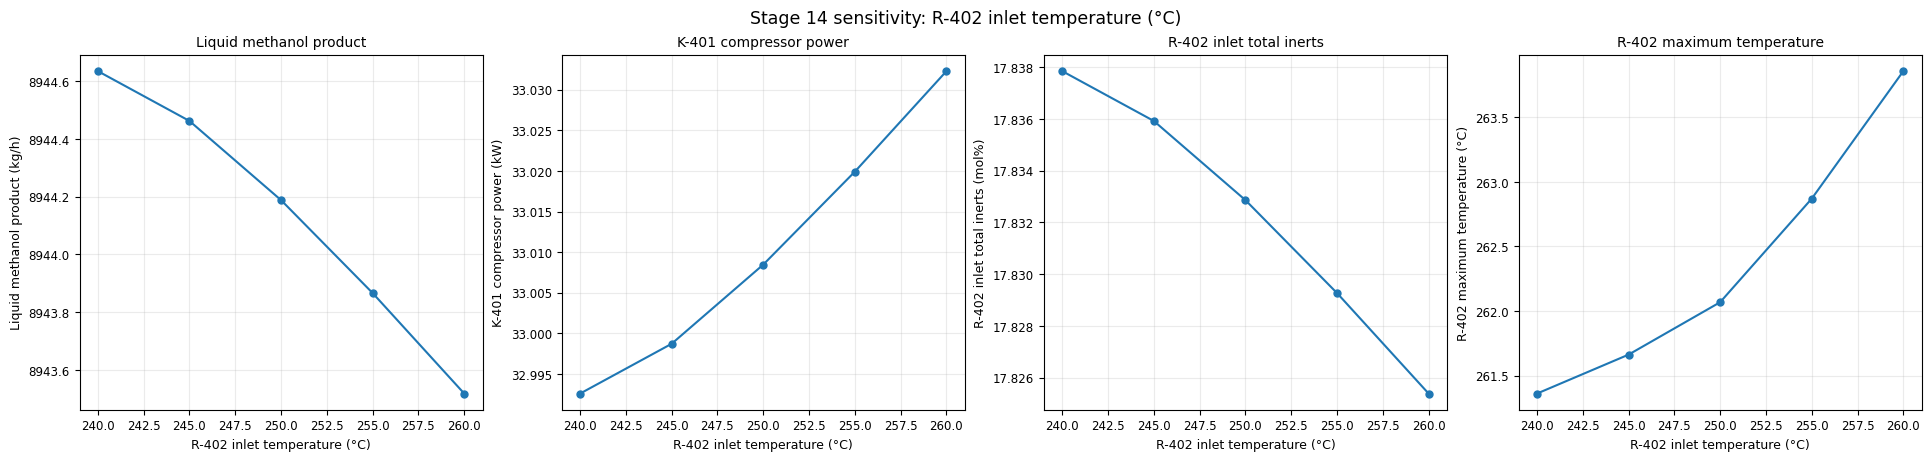

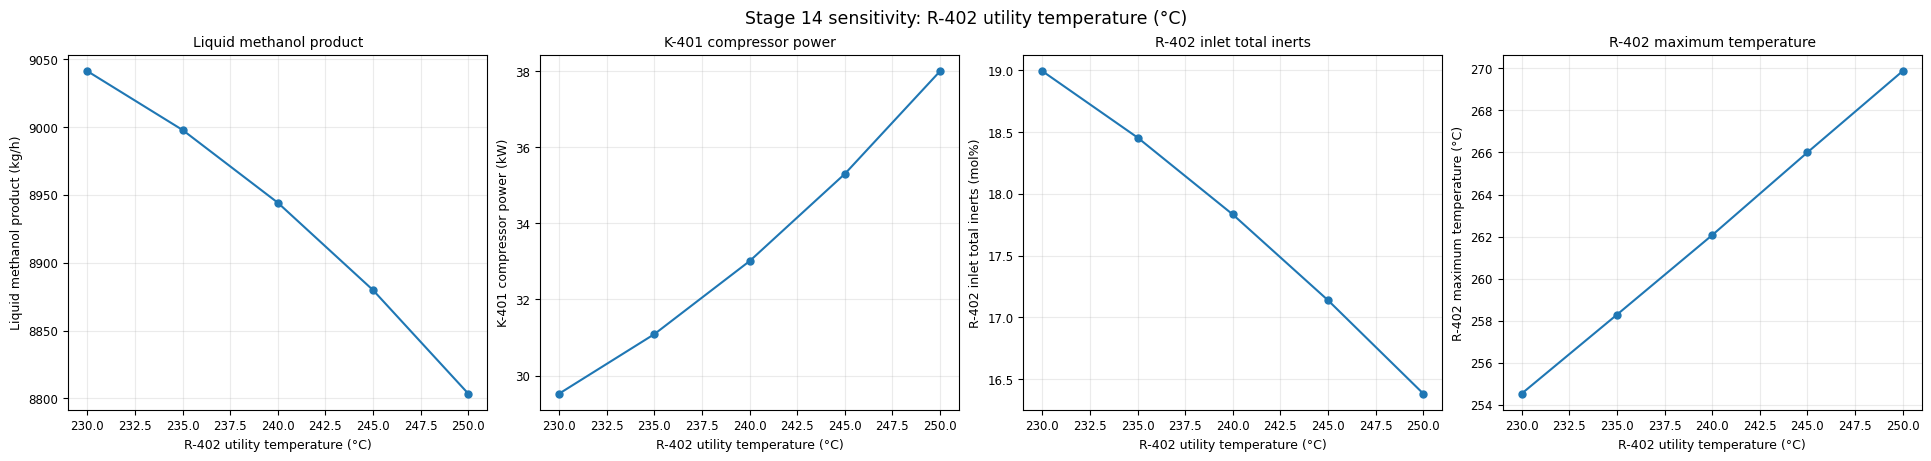

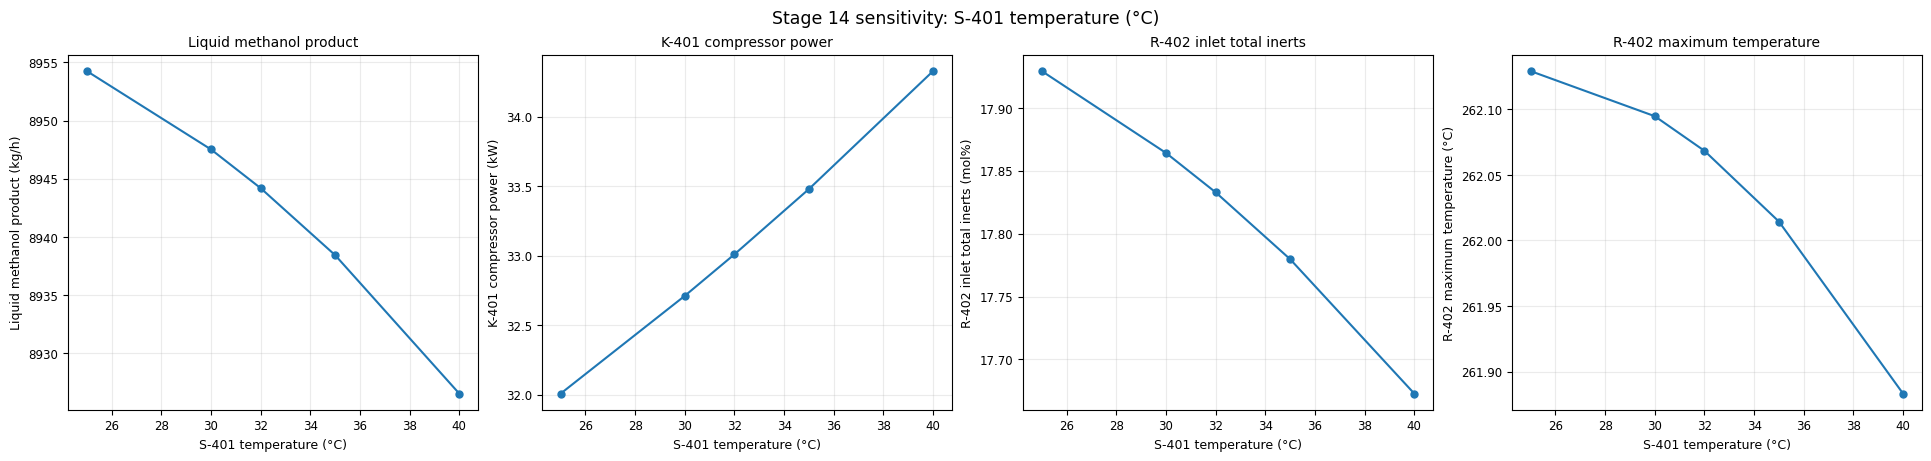

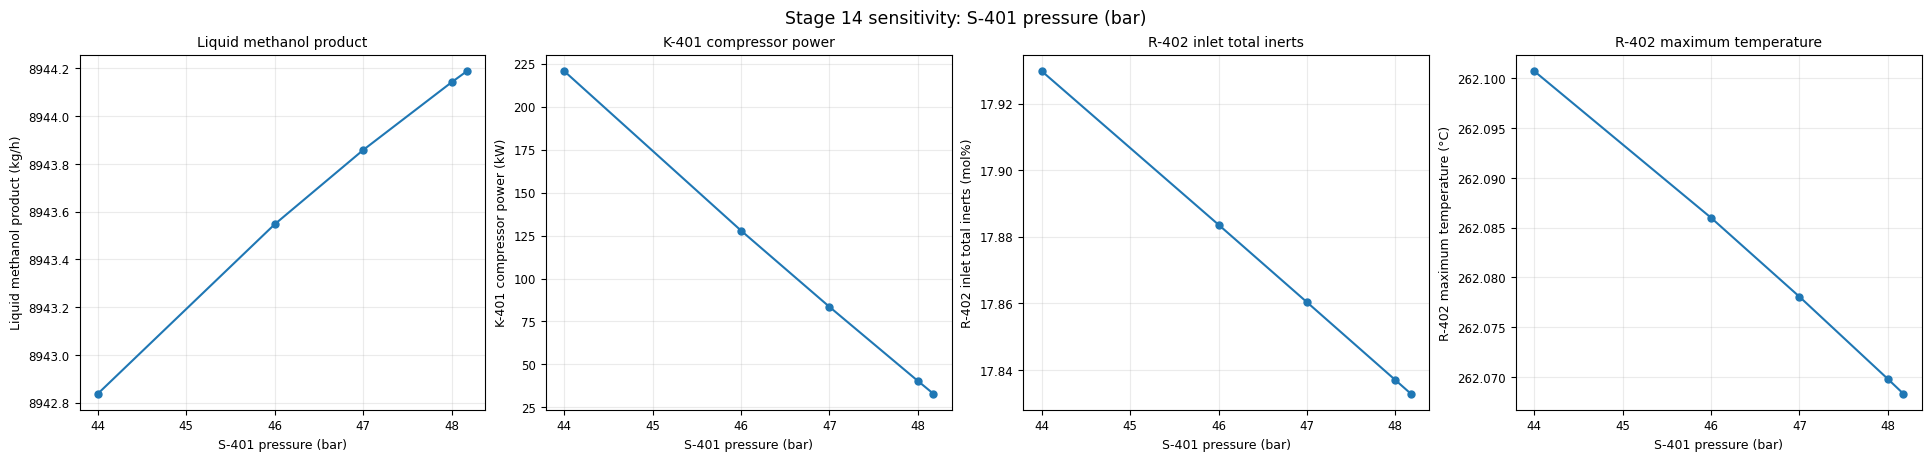

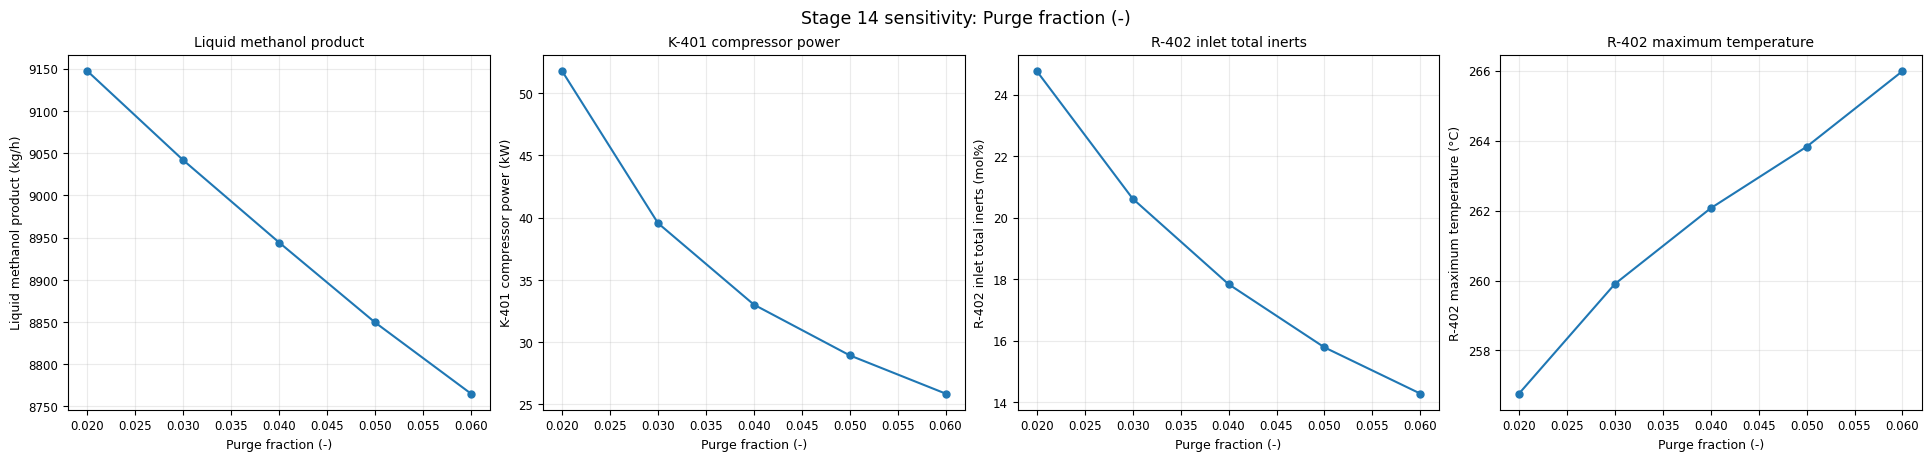

In [21]:
import matplotlib.pyplot as plt

if RUN_SENSITIVITY:
    plot_metrics = [
        ('product_MeOH_kg_h', 'Liquid methanol product', 'kg/h', 1.0),
        ('compressor_kW', 'K-401 compressor power', 'kW', 1.0),
        ('inert_molfrac', 'R-402 inlet total inerts', 'mol%', 100.0),
        ('R402_Tmax_C', 'R-402 maximum temperature', '°C', 1.0),
    ]
    variable_labels = {
        'T_R402_in_C': 'R-402 inlet temperature (°C)',
        'T_R402_utility_C': 'R-402 utility temperature (°C)',
        'T_S401_C': 'S-401 temperature (°C)',
        'P_S401_bar': 'S-401 pressure (bar)',
        'purge_frac': 'Purge fraction (-)',
    }

    for variable, table in sensitivity.items():
        fig, axes = plt.subplots(1, 4, figsize=(19.2, 4.5), constrained_layout=True)
        axes = np.atleast_1d(axes).ravel()
        x_label = variable_labels.get(variable, variable)

        for ax, (metric, title, unit, scale) in zip(axes, plot_metrics):
            if metric not in table.columns:
                ax.set_visible(False)
                continue

            y = table[metric] * scale
            ax.plot(table[variable], y, marker='o', linewidth=1.5, markersize=5)
            ax.set_xlabel(x_label)
            ax.set_ylabel(f'{title} ({unit})')
            ax.set_title(title, fontsize=10.0)
            ax.grid(True, alpha=0.25)
            ax.tick_params(labelsize=8.5)
            ax.xaxis.label.set_size(9.0)
            ax.yaxis.label.set_size(9.0)

        fig.suptitle(f'Stage 14 sensitivity: {x_label}', fontsize=12.5)
        plt.show()


In [22]:
_variable_names = {
    'T_R402_in_C':'R-402 inlet temperature',
    'T_R402_utility_C':'R-402 utility temperature',
    'T_S401_C':'S-401 temperature',
    'P_S401_bar':'S-401 pressure',
    'purge_frac':'Purge fraction',
}
summary_rows=[]
for variable,table in sensitivity.items():
    valid=table[table['status']!='FAILED'].copy()
    summary_rows.append({
        'Sensitivity variable':_variable_names.get(variable,variable),
        'Feasible points':f"{int((table['status']=='FEASIBLE').sum())} / {len(table)}",
        'Methanol product range (kg/h)':f"{valid['product_MeOH_kg_h'].min():,.1f} – {valid['product_MeOH_kg_h'].max():,.1f}" if not valid.empty else '—',
        'K-401 power range (kW)':f"{valid['compressor_kW'].min():.1f} – {valid['compressor_kW'].max():.1f}" if not valid.empty else '—',
        'Inert range (mol%)':f"{100*valid['inert_molfrac'].min():.2f} – {100*valid['inert_molfrac'].max():.2f}" if not valid.empty else '—',
        'R-402 Tmax range (°C)':f"{valid['R402_Tmax_C'].min():.2f} – {valid['R402_Tmax_C'].max():.2f}" if not valid.empty else '—',
    })
sensitivity_summary=pd.DataFrame(summary_rows)
show_table(sensitivity_summary, 'Stage 14 sensitivity summary')


Sensitivity variable,Feasible points,Methanol product range (kg/h),K-401 power range (kW),Inert range (mol%),R-402 Tmax range (°C)
R-402 inlet temperature,3 / 5,"8,943.5 – 8,944.6",33.0 – 33.0,17.83 – 17.84,261.36 – 263.86
R-402 utility temperature,1 / 5,"8,803.6 – 9,041.1",29.5 – 38.0,16.38 – 18.99,254.53 – 269.87
S-401 temperature,2 / 5,"8,926.5 – 8,954.3",32.0 – 34.3,17.67 – 17.93,261.88 – 262.13
S-401 pressure,5 / 5,"8,942.8 – 8,944.2",33.0 – 220.8,17.83 – 17.93,262.07 – 262.10
Purge fraction,1 / 5,"8,765.3 – 9,147.2",25.9 – 51.8,14.28 – 24.76,256.77 – 265.99


In [23]:
RUN_OPERATING_WINDOW = True
RUN_FINE_OPERATING_WINDOWS = True
OW_GRID_POINTS = 9
OW_PRODUCT_TARGET_KG_H = 9000.0
OW_PRODUCT_TOLERANCE = 0.02
OW_PRODUCT_LOWER_KG_H = 8820.0
OW_PRODUCT_UPPER_KG_H = 9180.0
OW_LEVELS = {'T_R402_in_C': [240.0, 250.0, 260.0], 'T_R402_utility_C': [230.0, 240.0, 250.0], 'T_S401_C': [25.0, 32.0, 40.0], 'P_S401_bar': [44.0, 46.0, 48.174372291889], 'purge_frac': [0.02, 0.04, 0.06]}
OW_VARIABLE_INFO = {'T_R402_in_C': ('R-402 inlet temperature', '°C', 1.0), 'T_R402_utility_C': ('R-402 utility temperature', '°C', 1.0), 'T_S401_C': ('S-401 temperature', '°C', 1.0), 'P_S401_bar': ('S-401 pressure', 'bar', 1.0), 'purge_frac': ('Purge fraction', '%', 100.0)}
OW_PAIRS = [('T_R402_in_C', 'T_R402_utility_C'), ('T_R402_in_C', 'T_S401_C'), ('T_R402_in_C', 'P_S401_bar'), ('T_R402_in_C', 'purge_frac'), ('T_R402_utility_C', 'T_S401_C'), ('T_R402_utility_C', 'P_S401_bar'), ('T_R402_utility_C', 'purge_frac'), ('T_S401_C', 'P_S401_bar'), ('T_S401_C', 'purge_frac'), ('P_S401_bar', 'purge_frac')]
OW_SHORT_TITLES = {'T_R402_in_C__T_R402_utility_C': 'R-402 inlet T vs utility T', 'T_R402_in_C__T_S401_C': 'R-402 inlet T vs S-401 T', 'T_R402_in_C__P_S401_bar': 'R-402 inlet T vs S-401 P', 'T_R402_in_C__purge_frac': 'R-402 inlet T vs purge', 'T_R402_utility_C__T_S401_C': 'R-402 utility T vs S-401 T', 'T_R402_utility_C__P_S401_bar': 'R-402 utility T vs S-401 P', 'T_R402_utility_C__purge_frac': 'R-402 utility T vs purge', 'T_S401_C__P_S401_bar': 'S-401 T vs S-401 P', 'T_S401_C__purge_frac': 'S-401 T vs purge', 'P_S401_bar__purge_frac': 'S-401 P vs purge'}

def _fine_values(attr,n=OW_GRID_POINTS):
    vals=np.asarray(OW_LEVELS[attr],dtype=float)
    return np.linspace(float(vals.min()),float(vals.max()),int(n))

OPERATING_WINDOWS={}
for x_attr,y_attr in OW_PAIRS:
    x_name,x_unit,x_scale=OW_VARIABLE_INFO[x_attr]
    y_name,y_unit,y_scale=OW_VARIABLE_INFO[y_attr]
    key=f"{x_attr}__{y_attr}"
    OPERATING_WINDOWS[key]={'x_attr':x_attr,'y_attr':y_attr,'x_values':_fine_values(x_attr),'y_values':_fine_values(y_attr),'x_label':f"{x_name} ({x_unit})",'y_label':f"{y_name} ({y_unit})",'x_plot_scale':x_scale,'y_plot_scale':y_scale,'title':OW_SHORT_TITLES[key]}

window_basis=pd.DataFrame([
 ['Methanol product','8,820 – 9,180','kg/h'],
 ['Maximum total inerts',f"{100*CFG.total_inert_molfrac_max:.1f}",'mol%'],
 ['R-402 maximum temperature',f"{CFG.R402_Tmax_C:.1f}",'°C'],
 ['R-402 maximum pressure drop',f"{CFG.R402_dP_max_bar:.2f}",'bar'],
 ['Preliminary grid','3 × 3','points per window'],
 ['Fine post-TAC grid',f"{OW_GRID_POINTS} × {OW_GRID_POINTS}",'points per window']],
 columns=['Operating-window criterion','Value','Unit'])
show_table(window_basis,'Stage 15 operating-window basis')


Operating-window criterion,Value,Unit
Methanol product,"8,820 – 9,180",kg/h
Maximum total inerts,25.0,mol%
R-402 maximum temperature,280.0,°C
R-402 maximum pressure drop,0.50,bar
Preliminary grid,3 × 3,points per window
Fine post-TAC grid,9 × 9,points per window


In [24]:
from matplotlib.lines import Line2D

_PRELIMINARY_PAIRWISE_WINDOWS = {'T_R402_in_C__T_R402_utility_C': [{'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 240.0, 'y_value': 230.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9041.14186329237, 'inert_molfrac': 0.1899329901807274, 'compressor_kW': 29.527252993052866, 'R402_Tmax_C': 252.8385270498624, 'R402_dP_bar': 0.1225754885938111, 'recycle_ratio': 2.067136530641927, 'PCV_dP_bar': 0.1384001570985589, 'limiting': 'E-402 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 250.0, 'y_value': 230.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9041.057152635356, 'inert_molfrac': 0.18992231114306132, 'compressor_kW': 29.530292048706695, 'R402_Tmax_C': 254.53406496053947, 'R402_dP_bar': 0.12269422700518742, 'recycle_ratio': 2.067368924202272, 'PCV_dP_bar': 0.1381987082921441, 'limiting': 'E-402 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 260.0, 'y_value': 230.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9040.796330139849, 'inert_molfrac': 0.1898894462959592, 'compressor_kW': 29.539647647425788, 'R402_Tmax_C': 260.0, 'R402_dP_bar': 0.1228711835877504, 'recycle_ratio': 2.068084547750558, 'PCV_dP_bar': 0.1377675381093581, 'limiting': 'E-402 capacity; E-403 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 240.0, 'y_value': 240.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.635427000021, 'inert_molfrac': 0.17837847483814442, 'compressor_kW': 32.99257243584499, 'R402_Tmax_C': 261.36106022792126, 'R402_dP_bar': 0.1474082712110225, 'recycle_ratio': 2.328239187444572, 'PCV_dP_bar': 0.011714326314205437, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 250.0, 'y_value': 240.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 260.0, 'y_value': 240.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8943.517829821498, 'inert_molfrac': 0.17825383478962534, 'compressor_kW': 33.03230433816446, 'R402_Tmax_C': 263.8570316357799, 'R402_dP_bar': 0.14800143163281493, 'recycle_ratio': 2.3312514202388503, 'PCV_dP_bar': 0.009949459552778706, 'limiting': 'E-403 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 240.0, 'y_value': 250.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8804.003014994629, 'inert_molfrac': 0.1638797862734448, 'compressor_kW': 37.97894571580341, 'R402_Tmax_C': 269.77086163645686, 'R402_dP_bar': 0.1865577108220383, 'recycle_ratio': 2.702421837234005, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH lower; E-404 capacity; S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 250.0, 'y_value': 250.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8803.609014022333, 'inert_molfrac': 0.16384248571162402, 'compressor_kW': 37.992837591501186, 'R402_Tmax_C': 269.86777841347134, 'R402_dP_bar': 0.18685538727899081, 'recycle_ratio': 2.7034596251701264, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH lower; E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_R402_utility_C', 'x_value': 260.0, 'y_value': 250.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8802.449254674772, 'inert_molfrac': 0.16373221163743, 'compressor_kW': 38.033868780239374, 'R402_Tmax_C': 270.6797839797248, 'R402_dP_bar': 0.1874077421832643, 'recycle_ratio': 2.706509945545996, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH lower; E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'combined'}], 'T_R402_in_C__T_S401_C': [{'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 240.0, 'y_value': 25.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8954.652112413067, 'inert_molfrac': 0.1793380448463835, 'compressor_kW': 31.992626673782603, 'R402_Tmax_C': 261.42012515170063, 'R402_dP_bar': 0.144731335065877, 'recycle_ratio': 2.2857696303998543, 'PCV_dP_bar': 0.0292685544773334, 'limiting': 'E-404 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 250.0, 'y_value': 25.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8954.254284100014, 'inert_molfrac': 0.17929297109309697, 'compressor_kW': 32.00650319100361, 'R402_Tmax_C': 262.1290922699758, 'R402_dP_bar': 0.14497097716169433, 'recycle_ratio': 2.2868458771379023, 'PCV_dP_bar': 0.028616074300927608, 'limiting': 'E-403 capacity; E-404 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 260.0, 'y_value': 25.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8953.63930839737, 'inert_molfrac': 0.1792232997306123, 'compressor_kW': 32.02796018370897, 'R402_Tmax_C': 263.9076309987488, 'R402_dP_bar': 0.1452840568617079, 'recycle_ratio': 2.288508869217217, 'PCV_dP_bar': 0.0276648652534134, 'limiting': 'E-403 capacity; E-404 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 240.0, 'y_value': 32.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.635427000021, 'inert_molfrac': 0.17837847483814442, 'compressor_kW': 32.99257243584499, 'R402_Tmax_C': 261.36106022792126, 'R402_dP_bar': 0.1474082712110225, 'recycle_ratio': 2.328239187444572, 'PCV_dP_bar': 0.011714326314205437, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 250.0, 'y_value': 32.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 260.0, 'y_value': 32.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8943.517829821498, 'inert_molfrac': 0.17825383478962534, 'compressor_kW': 33.03230433816446, 'R402_Tmax_C': 263.8570316357799, 'R402_dP_bar': 0.14800143163281493, 'recycle_ratio': 2.3312514202388503, 'PCV_dP_bar': 0.009949459552778706, 'limiting': 'E-403 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 240.0, 'y_value': 40.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8927.04778735736, 'inert_molfrac': 0.1767850164672507, 'compressor_kW': 34.30751585326801, 'R402_Tmax_C': 261.17242234380046, 'R402_dP_bar': 0.1516616537196934, 'recycle_ratio': 2.3903614028980016, 'PCV_dP_bar': 0.0, 'limiting': 'S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 250.0, 'y_value': 40.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8926.522395155855, 'inert_molfrac': 0.17672782549739835, 'compressor_kW': 34.32655963064372, 'R402_Tmax_C': 261.8831831870125, 'R402_dP_bar': 0.1519503627764154, 'recycle_ratio': 2.3917704340270642, 'PCV_dP_bar': 0.0, 'limiting': 'S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'T_S401_C', 'x_value': 260.0, 'y_value': 40.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8925.758901820092, 'inert_molfrac': 0.1766446632867242, 'compressor_kW': 34.35425765796454, 'R402_Tmax_C': 263.6822287600172, 'R402_dP_bar': 0.1523196763550303, 'recycle_ratio': 2.3938169152319246, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; S-401 pressure path', 'source': 'combined'}], 'T_R402_in_C__P_S401_bar': [{'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 240.0, 'y_value': 44.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8943.306941409513, 'inert_molfrac': 0.1793512343478851, 'compressor_kW': 220.6440310414482, 'R402_Tmax_C': 261.3938405128572, 'R402_dP_bar': 0.1492565195913333, 'recycle_ratio': 2.3592169415971407, 'PCV_dP_bar': 4.133241059677808, 'limiting': 'nan', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 250.0, 'y_value': 44.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8942.838019966703, 'inert_molfrac': 0.17929806967032658, 'compressor_kW': 220.75496934111996, 'R402_Tmax_C': 262.100730577186, 'R402_dP_bar': 0.14952472529184074, 'recycle_ratio': 2.36047303288095, 'PCV_dP_bar': 4.1324473712787295, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 260.0, 'y_value': 44.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8942.148530679056, 'inert_molfrac': 0.1792201645444104, 'compressor_kW': 220.91779417794336, 'R402_Tmax_C': 263.8999447665967, 'R402_dP_bar': 0.1498683810860105, 'recycle_ratio': 2.3623214941313004, 'PCV_dP_bar': 4.131331502826775, 'limiting': 'E-403 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 240.0, 'y_value': 46.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.00678541432, 'inert_molfrac': 0.1788881534041118, 'compressor_kW': 127.86778902074332, 'R402_Tmax_C': 261.37896063134053, 'R402_dP_bar': 0.148346128471829, 'recycle_ratio': 2.34401235194006, 'PCV_dP_bar': 2.1597617260696325, 'limiting': 'nan', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 250.0, 'y_value': 46.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8943.547251142736, 'inert_molfrac': 0.17883638745466557, 'compressor_kW': 127.9309953636166, 'R402_Tmax_C': 262.08599857320723, 'R402_dP_bar': 0.14860998800252564, 'recycle_ratio': 2.345246414362134, 'PCV_dP_bar': 2.158999401440383, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 260.0, 'y_value': 46.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8942.867373764417, 'inert_molfrac': 0.178760043438563, 'compressor_kW': 128.02435589089947, 'R402_Tmax_C': 263.88011981320005, 'R402_dP_bar': 0.1489490444976743, 'recycle_ratio': 2.347073822758463, 'PCV_dP_bar': 2.157923226182412, 'limiting': 'E-403 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 240.0, 'y_value': 48.174372291889, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.635427000021, 'inert_molfrac': 0.17837847483814442, 'compressor_kW': 32.99257243584499, 'R402_Tmax_C': 261.36106022792126, 'R402_dP_bar': 0.1474082712110225, 'recycle_ratio': 2.328239187444572, 'PCV_dP_bar': 0.011714326314205437, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 250.0, 'y_value': 48.174372291889, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'P_S401_bar', 'x_value': 260.0, 'y_value': 48.174372291889, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8943.517829821498, 'inert_molfrac': 0.17825383478962534, 'compressor_kW': 33.03230433816446, 'R402_Tmax_C': 263.8570316357799, 'R402_dP_bar': 0.14800143163281493, 'recycle_ratio': 2.3312514202388503, 'PCV_dP_bar': 0.009949459552778706, 'limiting': 'E-403 capacity', 'source': 'OAT'}], 'T_R402_in_C__purge_frac': [{'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 240.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9147.476313348385, 'inert_molfrac': 0.2476757631800044, 'compressor_kW': 51.74898432308258, 'R402_Tmax_C': 255.8796347148769, 'R402_dP_bar': 0.2986602981713228, 'recycle_ratio': 3.695603480850085, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 250.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9147.169513195482, 'inert_molfrac': 0.24760653207280703, 'compressor_kW': 51.771524262412, 'R402_Tmax_C': 256.7674395767135, 'R402_dP_bar': 0.29920470494361595, 'recycle_ratio': 3.6973137134866167, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 260.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9146.57764966512, 'inert_molfrac': 0.2474731017323914, 'compressor_kW': 51.81500135059777, 'R402_Tmax_C': 260.0, 'R402_dP_bar': 0.2999923349367361, 'recycle_ratio': 3.700613003647337, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 240.0, 'y_value': 0.04, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.635427000021, 'inert_molfrac': 0.17837847483814442, 'compressor_kW': 32.99257243584499, 'R402_Tmax_C': 261.36106022792126, 'R402_dP_bar': 0.1474082712110225, 'recycle_ratio': 2.328239187444572, 'PCV_dP_bar': 0.011714326314205437, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 250.0, 'y_value': 0.04, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 260.0, 'y_value': 0.04, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8943.517829821498, 'inert_molfrac': 0.17825383478962534, 'compressor_kW': 33.03230433816446, 'R402_Tmax_C': 263.8570316357799, 'R402_dP_bar': 0.14800143163281493, 'recycle_ratio': 2.3312514202388503, 'PCV_dP_bar': 0.009949459552778706, 'limiting': 'E-403 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 240.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8765.696379647437, 'inert_molfrac': 0.1427814623733113, 'compressor_kW': 25.848416286606216, 'R402_Tmax_C': 265.11997492897217, 'R402_dP_bar': 0.1045074412431288, 'recycle_ratio': 1.8255957777814624, 'PCV_dP_bar': 0.2361301094046837, 'limiting': 'MeOH lower; E-402 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 250.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8765.277187205686, 'inert_molfrac': 0.14275253974647933, 'compressor_kW': 25.85806590610344, 'R402_Tmax_C': 265.9880303405988, 'R402_dP_bar': 0.1046633337773569, 'recycle_ratio': 1.8263229729080743, 'PCV_dP_bar': 0.23572835314489993, 'limiting': 'MeOH lower; E-402 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_in_C', 'y_attr': 'purge_frac', 'x_value': 260.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8764.583357455422, 'inert_molfrac': 0.1427046938219674, 'compressor_kW': 25.87403679988441, 'R402_Tmax_C': 267.2491155640796, 'R402_dP_bar': 0.1048733615986816, 'recycle_ratio': 1.8275265015058573, 'PCV_dP_bar': 0.2351113731776379, 'limiting': 'MeOH lower; E-402 capacity; E-403 capacity', 'source': 'combined'}], 'T_R402_utility_C__T_S401_C': [{'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 230.0, 'y_value': 25.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9048.120502684802, 'inert_molfrac': 0.1906926270946999, 'compressor_kW': 28.699966709813577, 'R402_Tmax_C': 254.51207866895527, 'R402_dP_bar': 0.1208730373186804, 'recycle_ratio': 2.0324887574882955, 'PCV_dP_bar': 0.1508731544091617, 'limiting': 'E-402 capacity; E-404 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 240.0, 'y_value': 25.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8954.254284100014, 'inert_molfrac': 0.17929297109309697, 'compressor_kW': 32.00650319100361, 'R402_Tmax_C': 262.1290922699758, 'R402_dP_bar': 0.14497097716169433, 'recycle_ratio': 2.2868458771379023, 'PCV_dP_bar': 0.028616074300927608, 'limiting': 'E-403 capacity; E-404 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 250.0, 'y_value': 25.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8818.021403296649, 'inert_molfrac': 0.1650100470088218, 'compressor_kW': 36.74639977167837, 'R402_Tmax_C': 269.994864805873, 'R402_dP_bar': 0.1827406234185118, 'recycle_ratio': 2.650511814518619, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH lower; E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 230.0, 'y_value': 32.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9041.057152635356, 'inert_molfrac': 0.18992231114306132, 'compressor_kW': 29.530292048706695, 'R402_Tmax_C': 254.53406496053947, 'R402_dP_bar': 0.12269422700518742, 'recycle_ratio': 2.067368924202272, 'PCV_dP_bar': 0.1381987082921441, 'limiting': 'E-402 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 240.0, 'y_value': 32.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 250.0, 'y_value': 32.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8803.609014022333, 'inert_molfrac': 0.16384248571162402, 'compressor_kW': 37.992837591501186, 'R402_Tmax_C': 269.86777841347134, 'R402_dP_bar': 0.18685538727899081, 'recycle_ratio': 2.7034596251701264, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH lower; E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 230.0, 'y_value': 40.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9027.98646815986, 'inert_molfrac': 0.1885905865063687, 'compressor_kW': 30.612411811548967, 'R402_Tmax_C': 254.44797836781825, 'R402_dP_bar': 0.125627824808713, 'recycle_ratio': 2.1180818957375824, 'PCV_dP_bar': 0.1191941246618455, 'limiting': 'E-402 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 240.0, 'y_value': 40.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8926.522395155855, 'inert_molfrac': 0.17672782549739835, 'compressor_kW': 34.32655963064372, 'R402_Tmax_C': 261.8831831870125, 'R402_dP_bar': 0.1519503627764154, 'recycle_ratio': 2.3917704340270642, 'PCV_dP_bar': 0.0, 'limiting': 'S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'T_S401_C', 'x_value': 250.0, 'y_value': 40.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8779.009701221185, 'inert_molfrac': 0.1619397379955404, 'compressor_kW': 39.65799280678, 'R402_Tmax_C': 269.5950224814418, 'R402_dP_bar': 0.1934257126109581, 'recycle_ratio': 2.782361650942993, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH lower; E-403 capacity; S-401 pressure path', 'source': 'combined'}], 'T_R402_utility_C__P_S401_bar': [{'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 230.0, 'y_value': 44.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9040.71136486988, 'inert_molfrac': 0.1911847940910616, 'compressor_kW': 197.4115425164349, 'R402_Tmax_C': 254.6062685760373, 'R402_dP_bar': 0.1242177033107169, 'recycle_ratio': 2.09675316585766, 'PCV_dP_bar': 4.268129777690554, 'limiting': 'E-402 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 240.0, 'y_value': 44.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8942.838019966703, 'inert_molfrac': 0.17929806967032658, 'compressor_kW': 220.75496934111996, 'R402_Tmax_C': 262.100730577186, 'R402_dP_bar': 0.14952472529184074, 'recycle_ratio': 2.36047303288095, 'PCV_dP_bar': 4.1324473712787295, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 250.0, 'y_value': 44.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8801.0807139833, 'inert_molfrac': 0.1645225250262056, 'compressor_kW': 254.1483784199246, 'R402_Tmax_C': 269.8760298813778, 'R402_dP_bar': 0.1891482739200443, 'recycle_ratio': 2.735802243188136, 'PCV_dP_bar': 3.921489355000873, 'limiting': 'MeOH lower; E-403 capacity; E-404 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 230.0, 'y_value': 46.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9040.92301252984, 'inert_molfrac': 0.190580785522981, 'compressor_kW': 114.42674751429983, 'R402_Tmax_C': 254.572101158602, 'R402_dP_bar': 0.1234678729116357, 'recycle_ratio': 2.082334778444127, 'PCV_dP_bar': 2.2904340476625507, 'limiting': 'E-402 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 240.0, 'y_value': 46.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8943.547251142736, 'inert_molfrac': 0.17883638745466557, 'compressor_kW': 127.9309953636166, 'R402_Tmax_C': 262.08599857320723, 'R402_dP_bar': 0.14860998800252564, 'recycle_ratio': 2.345246414362134, 'PCV_dP_bar': 2.158999401440383, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 250.0, 'y_value': 46.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8802.378034586032, 'inert_molfrac': 0.1642013202732964, 'compressor_kW': 147.26527543625684, 'R402_Tmax_C': 269.8731594224921, 'R402_dP_bar': 0.1880175014233868, 'recycle_ratio': 2.7199157759387025, 'PCV_dP_bar': 1.954363470997244, 'limiting': 'MeOH lower; E-403 capacity; E-404 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 230.0, 'y_value': 48.174372291889, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9041.057152635356, 'inert_molfrac': 0.18992231114306132, 'compressor_kW': 29.530292048706695, 'R402_Tmax_C': 254.53406496053947, 'R402_dP_bar': 0.12269422700518742, 'recycle_ratio': 2.067368924202272, 'PCV_dP_bar': 0.1381987082921441, 'limiting': 'E-402 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 240.0, 'y_value': 48.174372291889, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'P_S401_bar', 'x_value': 250.0, 'y_value': 48.174372291889, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8803.609014022333, 'inert_molfrac': 0.16384248571162402, 'compressor_kW': 37.992837591501186, 'R402_Tmax_C': 269.86777841347134, 'R402_dP_bar': 0.18685538727899081, 'recycle_ratio': 2.7034596251701264, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH lower; E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'OAT'}], 'T_R402_utility_C__purge_frac': [{'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 230.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9201.111965423865, 'inert_molfrac': 0.2606139833948101, 'compressor_kW': 47.75796159355834, 'R402_Tmax_C': 250.0, 'R402_dP_bar': 0.2575056002047937, 'recycle_ratio': 3.3992560018876965, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH upper; Inerts 25 mol%; E-402 capacity; E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 240.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9147.169513195482, 'inert_molfrac': 0.24760653207280703, 'compressor_kW': 51.771524262412, 'R402_Tmax_C': 256.7674395767135, 'R402_dP_bar': 0.29920470494361595, 'recycle_ratio': 3.6973137134866167, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 250.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9062.29397414471, 'inert_molfrac': 0.2297553521940407, 'compressor_kW': 57.99796069836815, 'R402_Tmax_C': 265.29366789105416, 'R402_dP_bar': 0.368559634340303, 'recycle_ratio': 4.16381951524843, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 230.0, 'y_value': 0.04, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9041.057152635356, 'inert_molfrac': 0.18992231114306132, 'compressor_kW': 29.530292048706695, 'R402_Tmax_C': 254.53406496053947, 'R402_dP_bar': 0.12269422700518742, 'recycle_ratio': 2.067368924202272, 'PCV_dP_bar': 0.1381987082921441, 'limiting': 'E-402 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 240.0, 'y_value': 0.04, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 250.0, 'y_value': 0.04, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8803.609014022333, 'inert_molfrac': 0.16384248571162402, 'compressor_kW': 37.992837591501186, 'R402_Tmax_C': 269.86777841347134, 'R402_dP_bar': 0.18685538727899081, 'recycle_ratio': 2.7034596251701264, 'PCV_dP_bar': 0.0, 'limiting': 'MeOH lower; E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 230.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8901.746422297258, 'inert_molfrac': 0.1528670409098043, 'compressor_kW': 22.68920921739252, 'R402_Tmax_C': 258.40803695175373, 'R402_dP_bar': 0.0855471842884086, 'recycle_ratio': 1.5876130919198883, 'PCV_dP_bar': 0.3344474003635582, 'limiting': 'E-402 capacity', 'source': 'combined'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 240.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8765.277187205686, 'inert_molfrac': 0.14275253974647933, 'compressor_kW': 25.85806590610344, 'R402_Tmax_C': 265.9880303405988, 'R402_dP_bar': 0.1046633337773569, 'recycle_ratio': 1.8263229729080743, 'PCV_dP_bar': 0.23572835314489993, 'limiting': 'MeOH lower; E-402 capacity', 'source': 'OAT'}, {'x_attr': 'T_R402_utility_C', 'y_attr': 'purge_frac', 'x_value': 250.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8574.32161448923, 'inert_molfrac': 0.1306111470913372, 'compressor_kW': 30.243035008788937, 'R402_Tmax_C': 273.14109992813405, 'R402_dP_bar': 0.1338142557348217, 'recycle_ratio': 2.1533190681713967, 'PCV_dP_bar': 0.0857934755638893, 'limiting': 'MeOH lower', 'source': 'combined'}], 'T_S401_C__P_S401_bar': [{'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 25.0, 'y_value': 44.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8953.961465543513, 'inert_molfrac': 0.1803503356181011, 'compressor_kW': 213.8626183241741, 'R402_Tmax_C': 262.18712246695657, 'R402_dP_bar': 0.1465841400887724, 'recycle_ratio': 2.3152022887382167, 'PCV_dP_bar': 4.152519740897787, 'limiting': 'E-404 capacity', 'source': 'combined'}, {'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 32.0, 'y_value': 44.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8942.838019966703, 'inert_molfrac': 0.17929806967032658, 'compressor_kW': 220.75496934111996, 'R402_Tmax_C': 262.100730577186, 'R402_dP_bar': 0.14952472529184074, 'recycle_ratio': 2.36047303288095, 'PCV_dP_bar': 4.1324473712787295, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 40.0, 'y_value': 44.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8923.483329249046, 'inert_molfrac': 0.1775556148876955, 'compressor_kW': 229.87567923422367, 'R402_Tmax_C': 261.8799637258534, 'R402_dP_bar': 0.1541967460501659, 'recycle_ratio': 2.4270197355664456, 'PCV_dP_bar': 4.102244546610223, 'limiting': 'nan', 'source': 'combined'}, {'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 25.0, 'y_value': 46.0, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8954.140950036997, 'inert_molfrac': 0.1798442440490851, 'compressor_kW': 123.99176773114684, 'R402_Tmax_C': 262.159671884721, 'R402_dP_bar': 0.1457910572917759, 'recycle_ratio': 2.301300297397028, 'PCV_dP_bar': 2.17783614158828, 'limiting': 'E-403 capacity; E-404 capacity', 'source': 'combined'}, {'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 32.0, 'y_value': 46.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8943.547251142736, 'inert_molfrac': 0.17883638745466557, 'compressor_kW': 127.9309953636166, 'R402_Tmax_C': 262.08599857320723, 'R402_dP_bar': 0.14860998800252564, 'recycle_ratio': 2.345246414362134, 'PCV_dP_bar': 2.158999401440383, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 40.0, 'y_value': 46.0, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8925.04078005046, 'inert_molfrac': 0.1771654519523696, 'compressor_kW': 133.12836556915076, 'R402_Tmax_C': 261.8829522781775, 'R402_dP_bar': 0.1530876794893294, 'recycle_ratio': 2.409688226619524, 'PCV_dP_bar': 2.130690668520721, 'limiting': 'nan', 'source': 'combined'}, {'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 25.0, 'y_value': 48.174372291889, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8954.254284100014, 'inert_molfrac': 0.17929297109309697, 'compressor_kW': 32.00650319100361, 'R402_Tmax_C': 262.1290922699758, 'R402_dP_bar': 0.14497097716169433, 'recycle_ratio': 2.2868458771379023, 'PCV_dP_bar': 0.028616074300927608, 'limiting': 'E-403 capacity; E-404 capacity', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 32.0, 'y_value': 48.174372291889, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'P_S401_bar', 'x_value': 40.0, 'y_value': 48.174372291889, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8926.522395155855, 'inert_molfrac': 0.17672782549739835, 'compressor_kW': 34.32655963064372, 'R402_Tmax_C': 261.8831831870125, 'R402_dP_bar': 0.1519503627764154, 'recycle_ratio': 2.3917704340270642, 'PCV_dP_bar': 0.0, 'limiting': 'S-401 pressure path', 'source': 'OAT'}], 'T_S401_C__purge_frac': [{'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 25.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9154.825792974078, 'inert_molfrac': 0.2491079427265643, 'compressor_kW': 50.23903045393417, 'R402_Tmax_C': 256.794765869278, 'R402_dP_bar': 0.293594873173451, 'recycle_ratio': 3.6344877228848, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 32.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9147.169513195482, 'inert_molfrac': 0.24760653207280703, 'compressor_kW': 51.771524262412, 'R402_Tmax_C': 256.7674395767135, 'R402_dP_bar': 0.29920470494361595, 'recycle_ratio': 3.6973137134866167, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 40.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9132.907525629224, 'inert_molfrac': 0.2449373892655874, 'compressor_kW': 53.855930922041146, 'R402_Tmax_C': 256.6384306151433, 'R402_dP_bar': 0.3088672406907938, 'recycle_ratio': 3.7949388397034407, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; S-401 pressure path', 'source': 'combined'}, {'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 25.0, 'y_value': 0.04, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8954.254284100014, 'inert_molfrac': 0.17929297109309697, 'compressor_kW': 32.00650319100361, 'R402_Tmax_C': 262.1290922699758, 'R402_dP_bar': 0.14497097716169433, 'recycle_ratio': 2.2868458771379023, 'PCV_dP_bar': 0.028616074300927608, 'limiting': 'E-403 capacity; E-404 capacity', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 32.0, 'y_value': 0.04, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 40.0, 'y_value': 0.04, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8926.522395155855, 'inert_molfrac': 0.17672782549739835, 'compressor_kW': 34.32655963064372, 'R402_Tmax_C': 261.8831831870125, 'R402_dP_bar': 0.1519503627764154, 'recycle_ratio': 2.3917704340270642, 'PCV_dP_bar': 0.0, 'limiting': 'S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 25.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8777.52773253643, 'inert_molfrac': 0.1434661491165197, 'compressor_kW': 25.06407596567361, 'R402_Tmax_C': 266.0601141081801, 'R402_dP_bar': 0.1028715834304411, 'recycle_ratio': 1.7932215153348785, 'PCV_dP_bar': 0.2478502628709407, 'limiting': 'MeOH lower; E-402 capacity; E-404 capacity', 'source': 'combined'}, {'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 32.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8765.277187205686, 'inert_molfrac': 0.14275253974647933, 'compressor_kW': 25.85806590610344, 'R402_Tmax_C': 265.9880303405988, 'R402_dP_bar': 0.1046633337773569, 'recycle_ratio': 1.8263229729080743, 'PCV_dP_bar': 0.23572835314489993, 'limiting': 'MeOH lower; E-402 capacity', 'source': 'OAT'}, {'x_attr': 'T_S401_C', 'y_attr': 'purge_frac', 'x_value': 40.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8744.463031359513, 'inert_molfrac': 0.141608146181546, 'compressor_kW': 26.88647535890333, 'R402_Tmax_C': 265.7705407198706, 'R402_dP_bar': 0.1074254796306043, 'recycle_ratio': 1.873820363864963, 'PCV_dP_bar': 0.2180570547910747, 'limiting': 'MeOH lower; E-402 capacity', 'source': 'combined'}], 'P_S401_bar__purge_frac': [{'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 44.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9146.62503404164, 'inert_molfrac': 0.2493197386022771, 'compressor_kW': 346.2994359196066, 'R402_Tmax_C': 256.79272300568186, 'R402_dP_bar': 0.3038018501397222, 'recycle_ratio': 3.7504897795004952, 'PCV_dP_bar': 3.3095243210050143, 'limiting': 'E-403 capacity; E-404 capacity', 'source': 'combined'}, {'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 46.0, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9146.935740034727, 'inert_molfrac': 0.248502626540603, 'compressor_kW': 200.668588342229, 'R402_Tmax_C': 256.78117532455894, 'R402_dP_bar': 0.3015379763564467, 'recycle_ratio': 3.724397188621199, 'PCV_dP_bar': 1.3629074738590958, 'limiting': 'E-403 capacity; E-404 capacity', 'source': 'combined'}, {'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 48.174372291889, 'y_value': 0.02, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 9147.169513195482, 'inert_molfrac': 0.24760653207280703, 'compressor_kW': 51.771524262412, 'R402_Tmax_C': 256.7674395767135, 'R402_dP_bar': 0.29920470494361595, 'recycle_ratio': 3.6973137134866167, 'PCV_dP_bar': 0.0, 'limiting': 'E-403 capacity; E-404 capacity; S-401 pressure path', 'source': 'OAT'}, {'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 44.0, 'y_value': 0.04, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8942.838019966703, 'inert_molfrac': 0.17929806967032658, 'compressor_kW': 220.75496934111996, 'R402_Tmax_C': 262.100730577186, 'R402_dP_bar': 0.14952472529184074, 'recycle_ratio': 2.36047303288095, 'PCV_dP_bar': 4.1324473712787295, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 46.0, 'y_value': 0.04, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8943.547251142736, 'inert_molfrac': 0.17883638745466557, 'compressor_kW': 127.9309953636166, 'R402_Tmax_C': 262.08599857320723, 'R402_dP_bar': 0.14860998800252564, 'recycle_ratio': 2.345246414362134, 'PCV_dP_bar': 2.158999401440383, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 48.174372291889, 'y_value': 0.04, 'feasible': True, 'status': 'FEASIBLE', 'product_MeOH_kg_h': 8944.188340290846, 'inert_molfrac': 0.17832860769350078, 'compressor_kW': 33.008464432793595, 'R402_Tmax_C': 262.06832703034945, 'R402_dP_bar': 0.1476669780058693, 'recycle_ratio': 2.329444445026266, 'PCV_dP_bar': 0.010986898006187573, 'limiting': 'None', 'source': 'OAT'}, {'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 44.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8763.21654815077, 'inert_molfrac': 0.1433858924662304, 'compressor_kW': 172.91551655428935, 'R402_Tmax_C': 266.0346561959981, 'R402_dP_bar': 0.1057784885683655, 'recycle_ratio': 1.8484230631071317, 'PCV_dP_bar': 4.373220536807366, 'limiting': 'MeOH lower; E-402 capacity', 'source': 'combined'}, {'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 46.0, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8764.278059631564, 'inert_molfrac': 0.1430847865943462, 'compressor_kW': 100.21260705360773, 'R402_Tmax_C': 266.0132505590757, 'R402_dP_bar': 0.105229291404495, 'recycle_ratio': 1.837576188868178, 'PCV_dP_bar': 2.3917323954071605, 'limiting': 'MeOH lower; E-402 capacity', 'source': 'combined'}, {'x_attr': 'P_S401_bar', 'y_attr': 'purge_frac', 'x_value': 48.174372291889, 'y_value': 0.06, 'feasible': False, 'status': 'INFEASIBLE', 'product_MeOH_kg_h': 8765.277187205686, 'inert_molfrac': 0.14275253974647933, 'compressor_kW': 25.85806590610344, 'R402_Tmax_C': 265.9880303405988, 'R402_dP_bar': 0.1046633337773569, 'recycle_ratio': 1.8263229729080743, 'PCV_dP_bar': 0.23572835314489993, 'limiting': 'MeOH lower; E-402 capacity', 'source': 'OAT'}]}

if not RUN_OPERATING_WINDOW:
    summary_rows=[]
    fig,axes=plt.subplots(3,4,figsize=(19.2,11.7),constrained_layout=True)
    axes=np.asarray(axes).ravel()

    summary_rows=[]

    for ax,(x_attr,y_attr) in zip(axes,OW_PAIRS):
        key=f'{x_attr}__{y_attr}'
        df=pd.DataFrame(_PRELIMINARY_PAIRWISE_WINDOWS[key])

        x_name,x_unit,x_scale=OW_VARIABLE_INFO[x_attr]
        y_name,y_unit,y_scale=OW_VARIABLE_INFO[y_attr]

        x_raw=np.asarray(OW_LEVELS[x_attr],dtype=float)
        y_raw=np.asarray(OW_LEVELS[y_attr],dtype=float)
        x_plot=x_raw*x_scale
        y_plot=y_raw*y_scale

        Z=np.zeros((len(y_raw),len(x_raw)))
        for iy,yv in enumerate(y_raw):
            for ix,xv in enumerate(x_raw):
                rr=df[np.isclose(df['x_value'].astype(float),xv) &
                      np.isclose(df['y_value'].astype(float),yv)]
                Z[iy,ix]=1.0 if (not rr.empty and bool(rr.iloc[0]['feasible'])) else 0.0

        X,Y=np.meshgrid(x_plot,y_plot)

        ax.contourf(X,Y,Z,levels=[-0.5,0.5,1.5],alpha=0.22)

        if np.nanmin(Z)<0.5 and np.nanmax(Z)>0.5:
            cs=ax.contour(X,Y,Z,levels=[0.5],linewidths=1.7)
            if len(cs.allsegs[0])>0:
                ax.clabel(cs,fmt={0.5:'cut-off'},fontsize=7,inline=True)

        feasible_pts=np.argwhere(Z>0.5)
        infeasible_pts=np.argwhere(Z<=0.5)

        if len(feasible_pts):
            ax.scatter(
                [x_plot[ix] for iy,ix in feasible_pts],
                [y_plot[iy] for iy,ix in feasible_pts],
                marker='o',s=34,zorder=4
            )
        if len(infeasible_pts):
            ax.scatter(
                [x_plot[ix] for iy,ix in infeasible_pts],
                [y_plot[iy] for iy,ix in infeasible_pts],
                marker='x',s=42,zorder=4
            )

        x_base=float(getattr(CFG,x_attr))*x_scale
        y_base=float(getattr(CFG,y_attr))*y_scale
        ax.scatter([x_base],[y_base],marker='*',s=95,zorder=5)

        ax.set_xlabel(f'{x_name} ({x_unit})',fontsize=9)
        ax.set_ylabel(f'{y_name} ({y_unit})',fontsize=9)
        ax.set_title(OW_SHORT_TITLES[key],fontsize=10.5,pad=7)
        ax.tick_params(axis='both',labelsize=8)
        ax.grid(True,alpha=0.18)
        ax.margins(x=0.05,y=0.07)

        failed=[]
        for text in df.loc[~df['feasible'].astype(bool),'limiting'].dropna():
            failed.extend([
                s.strip() for s in str(text).split(';')
                if s.strip() and s.strip() not in ('None','nan')
            ])
        dominant=pd.Series(failed).value_counts().index[0] if failed else 'None'
        summary_rows.append([
            OW_SHORT_TITLES[key],
            f"{int(df['feasible'].sum())} / {len(df)}",
            dominant
        ])

    for ax in axes[len(OW_PAIRS):]:
        ax.axis('off')

    legend_handles=[
        Line2D([0],[0],marker='o',linestyle='None',markersize=6,label='Feasible grid point'),
        Line2D([0],[0],marker='x',linestyle='None',markersize=7,label='Infeasible grid point'),
        Line2D([0],[0],marker='*',linestyle='None',markersize=9,label='Current base point'),
        Line2D([0],[0],linestyle='-',linewidth=1.7,label='Feasibility cut-off'),
    ]

    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=4,
        frameon=True,
        fontsize=9,
        bbox_to_anchor=(0.5,-0.015)
    )
    fig.suptitle(
        'Preliminary pairwise operating windows — current fixed equipment',
        fontsize=14,
        y=1.015
    )
    plt.show()

    pairwise_window_summary=pd.DataFrame(summary_rows,columns=['Operating window','Feasible grid points','Most frequent limiting constraint'])
    show_table(pairwise_window_summary,'Stage 15 pairwise operating-window summary')
else:
    print('Embedded preliminary operating-window results skipped; live grids will be recalculated from the current inputs.')


Embedded preliminary operating-window results skipped; live grids will be recalculated from the current inputs.


In [25]:
def operating_window_point(res, eq=EQ):
    cfg = res['cfg']
    product = float(res['liquid_product']['CH3OH'])
    inerts = float(total_inert_molfrac(res['R402_feed']))
    r402 = res['R402']

    margins = {
        'MeOH lower': product - OW_PRODUCT_LOWER_KG_H,
        'MeOH upper': OW_PRODUCT_UPPER_KG_H - product,
        'Inerts 25 mol%': cfg.total_inert_molfrac_max - inerts,
        'R-402 Tmax': cfg.R402_Tmax_C - float(r402['T_max_C']),
        'R-402 ΔP': cfg.R402_dP_max_bar - float(r402['dP_bar']),
        'E-402 capacity': float(res['E402']['Q_capacity_kW'] - res['E402']['Q_required_kW']),
        'E-403 capacity': float(res['E403']['Q_capacity_kW'] - res['E403']['Q_required_kW']),
        'E-404 capacity': float(res['E404']['Q_capacity_kW'] - res['E404']['Q_required_kW']),
        'S-401 pressure path': float(res['S401_PCV']['P_S401_full_open_bar'] - cfg.P_S401_bar),
        'R-401 ΔP': float(eq.R401_allow_dP_bar - res['R401']['dP_bar']),
    }

    discrete_checks = {
        'Recycle convergence': bool(res['coupled_converged']),
        'Mass closure': abs(float(res['external_mass_residual_kg_h'])) <= cfg.mass_closure_abs_tol_kg_h,
        'E-401 ΔP': bool(res['E401']['pressure_ok']),
        'E-402 ΔP': bool(res['E402']['tube_pressure_ok']),
        'E-403 ΔP': bool(res['E403']['tube_pressure_ok']),
        'E-404 ΔP': bool(res['E404']['pressure_ok']),
    }

    failed = [name for name, margin in margins.items()
              if not np.isfinite(margin) or margin < 0.0]
    failed += [name for name, ok in discrete_checks.items() if not ok]

    return {
        'product_MeOH_kg_h': product,
        'inert_molfrac': inerts,
        'recycle_ratio': float(res['recycle'].sum()/FRESH_342.sum()),
        'compressor_kW': float(res['compressor']['power_kW']),
        'R402_Tmax_C': float(r402['T_max_C']),
        'R402_dP_bar': float(r402['dP_bar']),
        'PCV_dP_bar': float(res['S401_PCV']['dP_bar']),
        'mass_residual_kg_h': float(res['external_mass_residual_kg_h']),
        'feasible': len(failed) == 0,
        'status': 'FEASIBLE' if len(failed) == 0 else 'INFEASIBLE',
        'Limiting constraint(s)': 'None' if len(failed) == 0 else '; '.join(failed),
        **{f'margin::{name}': value for name, value in margins.items()},
    }

def run_operating_window_slice(base_res, x_attr, x_values, y_attr, y_values,
                               eq=EQ, mode='screening', progress=True):
    base_cfg = base_res['cfg']
    rows = []
    last_rec = base_res['recycle']
    last_delta = base_res['reactor_delta']

    y_values = list(map(float, y_values))
    x_values = list(map(float, x_values))
    total = len(x_values) * len(y_values)
    count = 0

    for j, yv in enumerate(y_values):
        x_order = x_values if j % 2 == 0 else list(reversed(x_values))

        for xv in x_order:
            count += 1
            cfg = replace(base_cfg, **{x_attr: xv, y_attr: yv})

            try:
                res = solve_closed_loop(
                    cfg, eq,
                    recycle0=last_rec,
                    delta0=last_delta,
                    mode=mode,
                )
                metrics = operating_window_point(res, eq)
                last_rec = res['recycle']
                last_delta = res['reactor_delta']
                row = {x_attr: xv, y_attr: yv, **metrics}

            except Exception as exc:
                row = {
                    x_attr: xv,
                    y_attr: yv,
                    'feasible': False,
                    'status': 'FAILED',
                    'Limiting constraint(s)': 'Numerical/physical solve failure',
                    'error': str(exc),
                }

            rows.append(row)

            if progress:
                print(f'\r{x_attr} vs {y_attr}: {count}/{total} points', end='')

    if progress:
        print()

    return pd.DataFrame(rows).sort_values([y_attr, x_attr]).reset_index(drop=True)

window_results = {}

if RUN_OPERATING_WINDOW:
    for name, spec in OPERATING_WINDOWS.items():
        print(f"\nRunning {spec['title']}")
        window_results[name] = run_operating_window_slice(
            base_result,
            spec['x_attr'], spec['x_values'],
            spec['y_attr'], spec['y_values'],
            eq=EQ,
            mode='screening',
            progress=True,
        )
else:
    print(
        'Stage 15 is fully coded but has not been executed. '
        'Set RUN_OPERATING_WINDOW = True to reconverge the full 2-D grids.'
    )



Running R-402 inlet T vs utility T
T_R402_in_C vs T_R402_utility_C: 81/81 points

Running R-402 inlet T vs S-401 T
T_R402_in_C vs T_S401_C: 81/81 points

Running R-402 inlet T vs S-401 P
T_R402_in_C vs P_S401_bar: 81/81 points

Running R-402 inlet T vs purge
T_R402_in_C vs purge_frac: 81/81 points

Running R-402 utility T vs S-401 T
T_R402_utility_C vs T_S401_C: 81/81 points

Running R-402 utility T vs S-401 P
T_R402_utility_C vs P_S401_bar: 81/81 points

Running R-402 utility T vs purge
T_R402_utility_C vs purge_frac: 81/81 points

Running S-401 T vs S-401 P
T_S401_C vs P_S401_bar: 81/81 points

Running S-401 T vs purge
T_S401_C vs purge_frac: 81/81 points

Running S-401 P vs purge
P_S401_bar vs purge_frac: 81/81 points


Reusing the freshly recalculated live operating-window grids for fine-grid plotting.


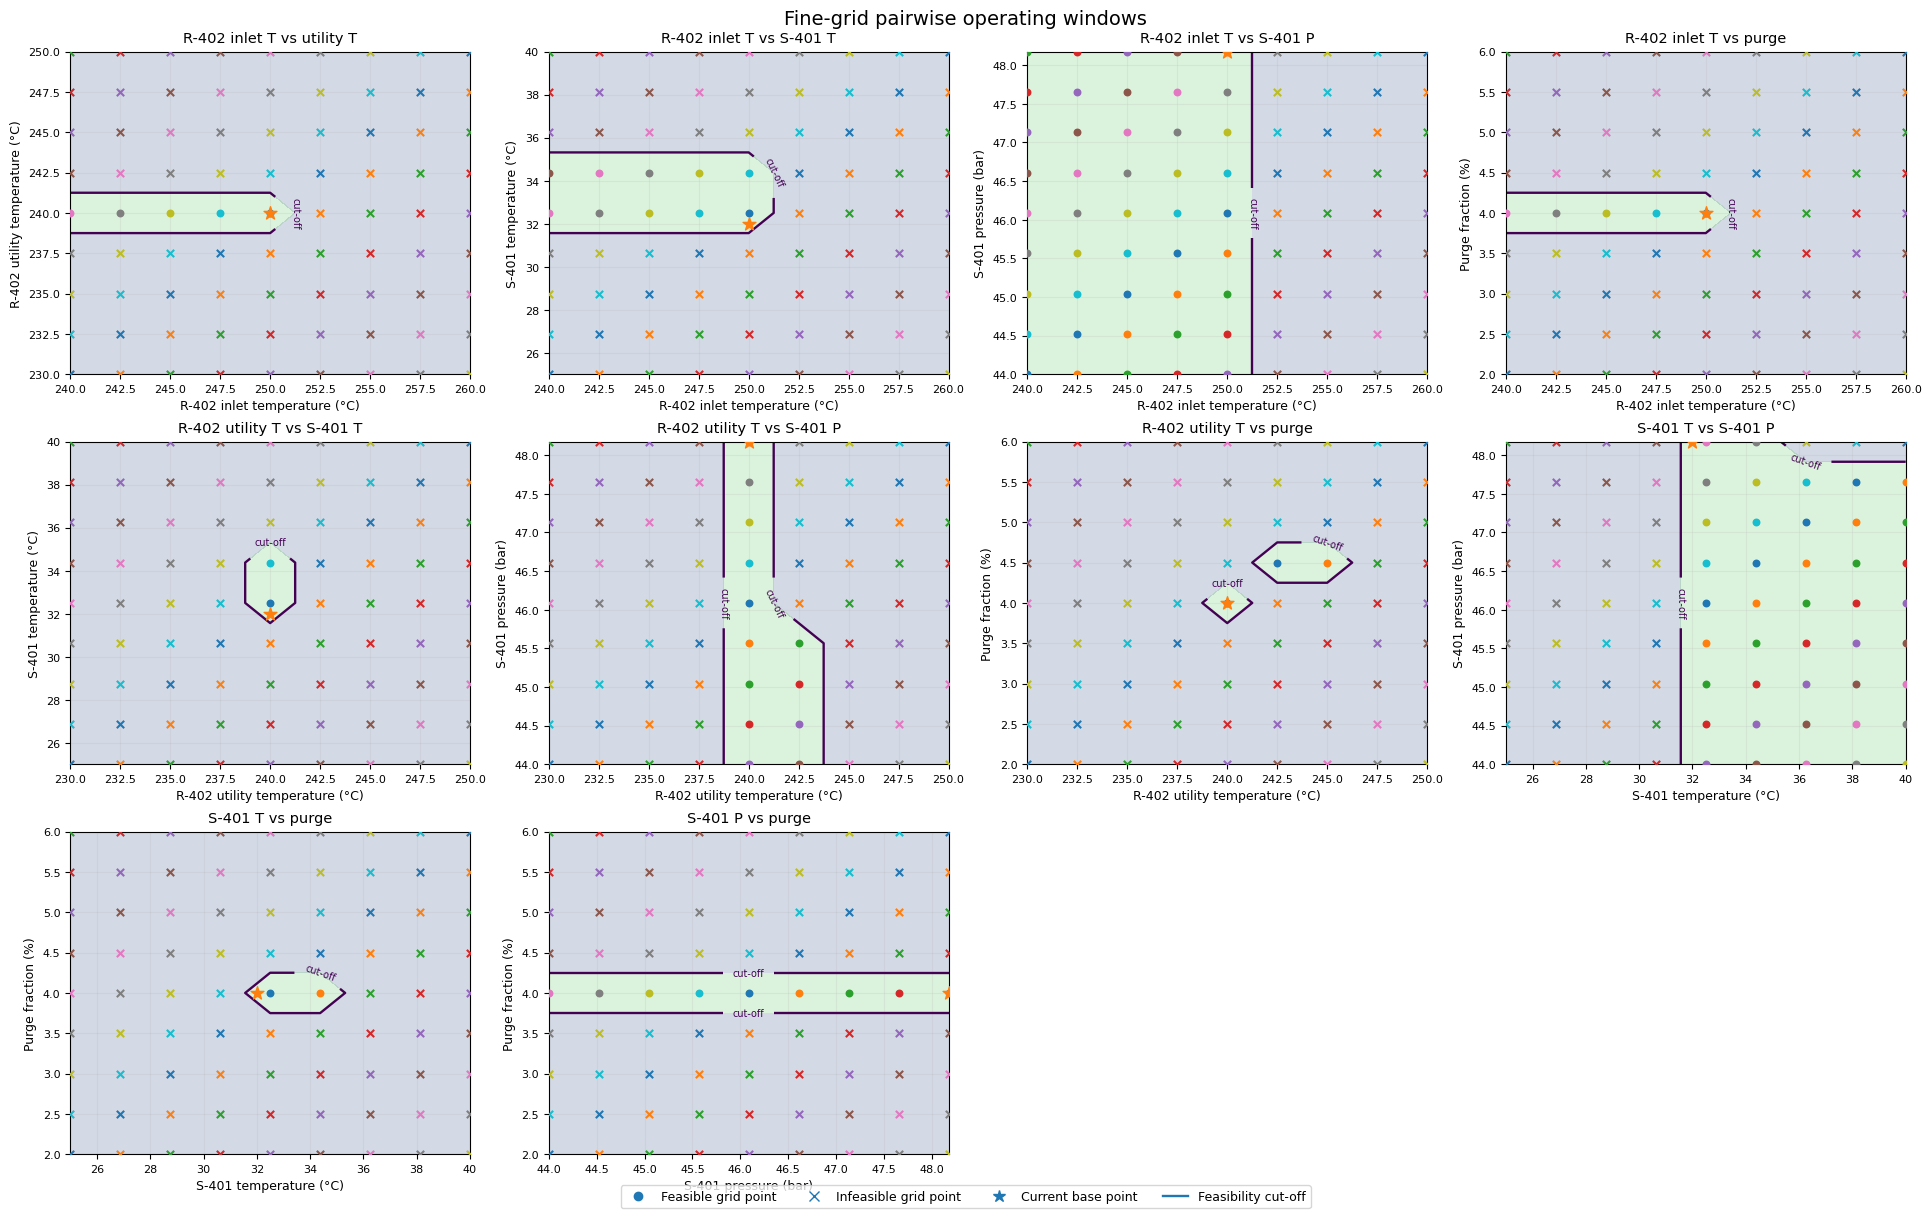

In [27]:
from matplotlib.lines import Line2D

def run_all_fine_operating_windows(base_res,eq=EQ,mode='screening'):
    results={}
    for key,spec in OPERATING_WINDOWS.items():
        print(f"Running {spec['title']}")
        results[key]=run_operating_window_slice(base_res,spec['x_attr'],spec['x_values'],spec['y_attr'],spec['y_values'],eq=eq,mode=mode,progress=True)
    return results

def _pivot_grid(df, x_attr, y_attr, value_col, x_values, y_values):
    """Convert operating-window point results into a y-by-x numerical grid."""
    pivot = df.pivot_table(
        index=y_attr,
        columns=x_attr,
        values=value_col,
        aggfunc='first'
    )

    # Reindex explicitly so the grid follows the same order as the requested
    # operating-window x and y arrays, even if pandas sorts them differently.
    pivot = pivot.reindex(
        index=np.asarray(y_values, dtype=float),
        columns=np.asarray(x_values, dtype=float)
    )

    return pivot.to_numpy(dtype=float)


def plot_all_fine_operating_windows(window_results, cfg=CFG):
    fig,axes=plt.subplots(3,4,figsize=(19.2,11.7),constrained_layout=True)
    axes=np.asarray(axes).ravel()

    for ax,(key,spec) in zip(axes,OPERATING_WINDOWS.items()):
        df=window_results[key]
        x_attr=spec['x_attr']; y_attr=spec['y_attr']
        xs_raw=np.asarray(spec['x_values'],dtype=float)
        ys_raw=np.asarray(spec['y_values'],dtype=float)
        xs=xs_raw*spec['x_plot_scale']
        ys=ys_raw*spec['y_plot_scale']
        X,Y=np.meshgrid(xs,ys)

        feasible=_pivot_grid(df,x_attr,y_attr,'feasible',xs_raw,ys_raw)
        feasible=np.where(np.isfinite(feasible),feasible,0.0)

        ax.contourf(X,Y,feasible,levels=[-0.5,0.5,1.5],alpha=0.22)

        if np.nanmin(feasible)<0.5 and np.nanmax(feasible)>0.5:
            cs=ax.contour(X,Y,feasible,levels=[0.5],linewidths=1.7)
            if len(cs.allsegs[0])>0:
                ax.clabel(cs,fmt={0.5:'cut-off'},fontsize=7,inline=True)

        for iy,yv in enumerate(ys):
            for ix,xv in enumerate(xs):
                if feasible[iy,ix]>0.5:
                    ax.scatter([xv],[yv],marker='o',s=22,zorder=4)
                else:
                    ax.scatter([xv],[yv],marker='x',s=28,zorder=4)

        ax.scatter(
            [float(getattr(cfg,x_attr))*spec['x_plot_scale']],
            [float(getattr(cfg,y_attr))*spec['y_plot_scale']],
            marker='*',s=95,zorder=5
        )

        ax.set_xlabel(spec['x_label'],fontsize=9)
        ax.set_ylabel(spec['y_label'],fontsize=9)
        ax.set_title(spec['title'],fontsize=10.5,pad=7)
        ax.tick_params(axis='both',labelsize=8)
        ax.grid(True,alpha=0.18)
        ax.margins(x=0.04,y=0.05)

    for ax in axes[len(OPERATING_WINDOWS):]:
        ax.axis('off')

    legend_handles=[
        Line2D([0],[0],marker='o',linestyle='None',markersize=6,label='Feasible grid point'),
        Line2D([0],[0],marker='x',linestyle='None',markersize=7,label='Infeasible grid point'),
        Line2D([0],[0],marker='*',linestyle='None',markersize=9,label='Current base point'),
        Line2D([0],[0],linestyle='-',linewidth=1.7,label='Feasibility cut-off'),
    ]

    fig.legend(
        handles=legend_handles,
        loc='lower center',
        ncol=4,
        frameon=True,
        fontsize=9,
        bbox_to_anchor=(0.5,-0.015)
    )
    fig.suptitle('Fine-grid pairwise operating windows',fontsize=14,y=1.015)
    plt.show()

fine_window_results={}
if RUN_FINE_OPERATING_WINDOWS:
    # Cell 24 already recalculates the full OPERATING_WINDOWS grids when RUN_OPERATING_WINDOW=True.
    # Reuse those freshly calculated results here so a full Run All does not solve the same 810 cases twice.
    if RUN_OPERATING_WINDOW and window_results:
        fine_window_results = window_results
        print('Reusing the freshly recalculated live operating-window grids for fine-grid plotting.')
    else:
        fine_window_results = run_all_fine_operating_windows(base_result,EQ,mode='screening')
    plot_all_fine_operating_windows(fine_window_results,CFG)
else:
    print('Fine operating-window plotting is disabled.')


In [28]:
from dataclasses import replace
import math

TAC_BASIS = {
    'cost_year': 2026,
    'CEPCI_base': 397.0,
    'CEPCI_2026': 878.8,
    'ZAR_per_USD': 16.39,
    'operating_hours_y': 8000.0,
    'discount_rate': 0.08,
    'project_life_y': 20.0,
    'electricity_R_per_kWh': 2.22,
    'HPS_R_per_GJ': 160.0,
    'cooling_R_per_GJ': 10.0,
    'R402_catalyst_R_per_kg': 492.0,
    'R402_catalyst_life_y': 5.0,
    'R401_ZnO_R_per_kg': 246.0,
    'R401_ZnO_life_y': 3.11,
    'product_target_kg_h': 9000.0,
    'product_tolerance_fraction': 0.01,
    'R402_reactor_multiplier': 3.0,
}

TURTON = {
    'floating_head': {
        'K': (4.8306, -0.8509, 0.3187),
        'B1': 1.63, 'B2': 1.66,
        'C': (0.03881, -0.11272, 0.08183),
        'size_range_m2': (10.0, 1000.0),
        'pressure_max_barg': 140.0,
    },
    'vertical_vessel': {
        'K': (3.4974, 0.4485, 0.1074),
        'B1': 2.25, 'B2': 1.82,
        'size_range_m3': (0.3, 520.0),
    },
    'rotary_compressor': {
        'K': (5.0355, -1.8002, 0.8253),
        'FBM_CS': 2.4,
        'power_range_kW': (18.0, 950.0),
    },
}

FM = {
    'HX_SS_shell_SS_tubes': 2.70,
    'HX_CS_shell_SS_tubes': 1.80,
    'vessel_SS': 3.10,
    'vessel_CS': 1.00,
}

def capital_recovery_factor(rate, years):
    return rate*(1.0+rate)**years / ((1.0+rate)**years - 1.0)

def _turton_purchase_cost(K, size):
    if size <= 0:
        raise ValueError('Turton size parameter must be positive.')
    L = math.log10(float(size))
    return 10.0**(K[0] + K[1]*L + K[2]*L*L)

def _turton_hx_pressure_factor(P_abs_bar):
    P_barg = max(float(P_abs_bar) - 1.01325, 0.0)
    if P_barg <= 0:
        return 1.0
    C1, C2, C3 = TURTON['floating_head']['C']
    LP = math.log10(P_barg)
    return max(1.0, 10.0**(C1 + C2*LP + C3*LP*LP))

def _turton_hx_bare_module_2001_USD(area_m2, P_abs_bar, material_factor):
    d = TURTON['floating_head']
    Cp0 = _turton_purchase_cost(d['K'], area_m2)
    Fp = _turton_hx_pressure_factor(P_abs_bar)
    return Cp0*(d['B1'] + d['B2']*material_factor*Fp)

def _turton_vessel_pressure_factor(D_m, P_abs_bar):

    P = max(float(P_abs_bar) - 1.01325, 0.0)
    numerator = ((P + 1.0)*float(D_m))/(2.0*(850.0 - 0.6*(P + 1.0))) + 0.00315
    return max(1.0, numerator/0.0063)

def _turton_vertical_vessel_bare_module_2001_USD(V_m3, D_m, P_abs_bar, material_factor):
    d = TURTON['vertical_vessel']
    Cp0 = _turton_purchase_cost(d['K'], V_m3)
    Fp = _turton_vessel_pressure_factor(D_m, P_abs_bar)
    return Cp0*(d['B1'] + d['B2']*material_factor*Fp)

def _turton_rotary_compressor_bare_module_2001_USD(power_kW):
    d = TURTON['rotary_compressor']
    Cp0 = _turton_purchase_cost(d['K'], power_kW)
    return Cp0*d['FBM_CS']

def _to_2026_ZAR(cost_2001_USD):
    escalation = TAC_BASIS['CEPCI_2026']/TAC_BASIS['CEPCI_base']
    return float(cost_2001_USD)*escalation*TAC_BASIS['ZAR_per_USD']

CRF_TAC = capital_recovery_factor(TAC_BASIS['discount_rate'], TAC_BASIS['project_life_y'])

basis_table = pd.DataFrame([
    ['Cost year', TAC_BASIS['cost_year'], '—'],
    ['CEPCI', TAC_BASIS['CEPCI_2026'], '—'],
    ['Turton base CEPCI', TAC_BASIS['CEPCI_base'], '—'],
    ['Operating time', TAC_BASIS['operating_hours_y'], 'h/y'],
    ['Discount rate', 100*TAC_BASIS['discount_rate'], '%/y'],
    ['Project life', TAC_BASIS['project_life_y'], 'y'],
    ['Capital recovery factor', CRF_TAC, '1/y'],
    ['Electricity', TAC_BASIS['electricity_R_per_kWh'], 'R/kWh'],
    ['HPS', TAC_BASIS['HPS_R_per_GJ'], 'R/GJ'],
    ['Cooling', TAC_BASIS['cooling_R_per_GJ'], 'R/GJ'],
    ['TAC product range', '8,910 – 9,090', 'kg/h'],
], columns=['Economic input','Value','Unit'])
show_table(basis_table, 'Stage 16 economic basis')


Economic input,Value,Unit
Cost year,2026,—
CEPCI,878.800000,—
Turton base CEPCI,397.000000,—
Operating time,8000.000000,h/y
Discount rate,8.000000,%/y
Project life,20.000000,y
Capital recovery factor,0.101852,1/y
Electricity,2.220000,R/kWh
HPS,160.000000,R/GJ
Cooling,10.000000,R/GJ


In [29]:
def _candidate_required_areas(res):
    cfg = res['cfg']
    e1, e2, e3, e4 = res['E401'], res['E402'], res['E403'], res['E404']

    A1 = e1['Q_kW']*1000.0/(e1['U_W_m2K']*e1['LMTD_K']*e1['Ft'])

    lm2 = _lmtd(275.6, 275.6, e1['T_cold_out_C'], 250.0)
    A2 = e2['Q_required_kW']*1000.0/(e2['U_W_m2K']*lm2)

    lm3 = _lmtd(275.6, 275.6, res['Tmix_C'], cfg.T_R402_in_C)
    A3 = e3['Q_required_kW']*1000.0/(e3['U_W_m2K']*lm3)

    A4 = e4['Q_required_kW']*1000.0/(e4['U_W_m2K']*e4['LMTD_K']*e4['Ft'])

    areas = {'E401':float(A1),'E402':float(A2),'E403':float(A3),'E404':float(A4)}
    if not all(np.isfinite(v) and v > 0 for v in areas.values()):
        raise RuntimeError('A positive finite heat-transfer area is required for TAC costing.')
    return areas

def tac_economics(res, eq=EQ):
    cfg = res['cfg']
    areas = _candidate_required_areas(res)

    cbm_2001 = {}
    cbm_2001['E401'] = _turton_hx_bare_module_2001_USD(
        areas['E401'], max(cfg.P_fresh_342_bar, res['R402']['P_out_bar']), FM['HX_SS_shell_SS_tubes'])
    cbm_2001['E402'] = _turton_hx_bare_module_2001_USD(
        areas['E402'], max(cfg.P_R402_in_bar, 60.0), FM['HX_CS_shell_SS_tubes'])
    cbm_2001['E403'] = _turton_hx_bare_module_2001_USD(
        areas['E403'], max(cfg.P_R402_in_bar, 60.0), FM['HX_CS_shell_SS_tubes'])
    cbm_2001['E404'] = _turton_hx_bare_module_2001_USD(
        areas['E404'], res['S401_PCV']['P_out_bar'], FM['HX_CS_shell_SS_tubes'])

    cbm_2001['R401'] = _turton_vertical_vessel_bare_module_2001_USD(
        eq.R401_bed_volume_m3, eq.R401_ID_m, cfg.P_fresh_342_bar, FM['vessel_SS'])

    # Cost R-402 from its CURRENT geometry.  The original 1565-tube reactor was
    # represented as two approximately equal high-pressure exchanger-type modules.
    # Preserve that costing basis while allowing the total tube count and bed length
    # to change during reactor sizing.
    nA = eq.R402_N_tubes//2
    nB = eq.R402_N_tubes - nA
    area_A = nA*math.pi*eq.R402_tube_OD_m*eq.R402_bed_length_m
    area_B = nB*math.pi*eq.R402_tube_OD_m*eq.R402_bed_length_m
    P_R402_cost = max(cfg.P_R402_in_bar, res['R402']['utility_Psat_bar'])
    reactor_equiv = (
        _turton_hx_bare_module_2001_USD(area_A, P_R402_cost, FM['HX_CS_shell_SS_tubes']) +
        _turton_hx_bare_module_2001_USD(area_B, P_R402_cost, FM['HX_CS_shell_SS_tubes'])
    )
    cbm_2001['R402'] = TAC_BASIS['R402_reactor_multiplier']*reactor_equiv

    D_S401, H_S401 = 1.20, 3.60
    V_S401 = math.pi*D_S401**2*H_S401/4.0
    cbm_2001['S401'] = _turton_vertical_vessel_bare_module_2001_USD(
        V_S401, D_S401, cfg.P_S401_bar, FM['vessel_CS'])

    power_kW = float(res['compressor']['power_kW'])
    cbm_2001['K401'] = _turton_rotary_compressor_bare_module_2001_USD(power_kW)

    installed_2026_ZAR = {k:_to_2026_ZAR(v) for k,v in cbm_2001.items()}
    total_installed = float(sum(installed_2026_ZAR.values()))
    annualised_capital = CRF_TAC*total_installed

    h = TAC_BASIS['operating_hours_y']
    electricity = power_kW*h*TAC_BASIS['electricity_R_per_kWh']
    heating = (res['E402']['Q_required_kW'] + res['E403']['Q_required_kW'])*0.0036*h*TAC_BASIS['HPS_R_per_GJ']
    cooling = (res['E404']['Q_required_kW'] + res['R402']['Q_removed_kW'])*0.0036*h*TAC_BASIS['cooling_R_per_GJ']
    catalyst = eq.R402_catalyst_kg*TAC_BASIS['R402_catalyst_R_per_kg']/TAC_BASIS['R402_catalyst_life_y']
    zno = eq.R401_sorbent_kg*TAC_BASIS['R401_ZnO_R_per_kg']/TAC_BASIS['R401_ZnO_life_y']

    annual_costs = {
        'Annualised installed capital': annualised_capital,
        'K-401 electricity': electricity,
        'E-402/E-403 HPS': heating,
        'E-404/R-402 cooling': cooling,
        'R-402 catalyst replacement': catalyst,
        'R-401 ZnO replacement': zno,
    }
    AOC = electricity + heating + cooling + catalyst + zno
    TAC = annualised_capital + AOC

    return {
        'TAC_R_y': TAC,
        'ACC_R_y': annualised_capital,
        'AOC_R_y': AOC,
        'total_installed_capital_R': total_installed,
        'installed_costs_R': installed_2026_ZAR,
        'annual_costs_R_y': annual_costs,
        'required_areas_m2': areas,
        'R402_shell_areas_m2': (area_A, area_B),
    }

def tac_constraint_status(res, econ, eq=EQ):
    cfg = res['cfg']
    product = float(res['liquid_product']['CH3OH'])
    lower = TAC_BASIS['product_target_kg_h']*(1-TAC_BASIS['product_tolerance_fraction'])
    upper = TAC_BASIS['product_target_kg_h']*(1+TAC_BASIS['product_tolerance_fraction'])
    inerts = float(total_inert_molfrac(res['R402_feed']))

    A_lo, A_hi = TURTON['floating_head']['size_range_m2']
    W_lo, W_hi = TURTON['rotary_compressor']['power_range_kW']
    areas = econ['required_areas_m2']
    power = float(res['compressor']['power_kW'])

    checks = {
        'Methanol 9000 ±1%': lower <= product <= upper,
        'Recycle convergence': bool(res['coupled_converged']),
        'Mass closure': abs(float(res['external_mass_residual_kg_h'])) <= cfg.mass_closure_abs_tol_kg_h,
        'Total inerts ≤25 mol%': inerts <= cfg.total_inert_molfrac_max,
        'R-402 Tmax ≤280°C': float(res['R402']['T_max_C']) <= cfg.R402_Tmax_C,
        'R-402 ΔP ≤0.50 bar': float(res['R402']['dP_bar']) <= cfg.R402_dP_max_bar,
        'S-401 pressure path': bool(res['S401_pressure_feasible']),
        'R-401 ΔP': bool(res['R401']['pressure_ok']),
        'E-401 ΔP': bool(res['E401']['pressure_ok']),
        'HX cost-correlation area range': all(A_lo <= v <= A_hi for v in areas.values()),
        'K-401 rotary cost-correlation range': W_lo <= power <= W_hi,
    }
    failed = [name for name,ok in checks.items() if not bool(ok)]
    return checks, failed

base_TAC_econ = tac_economics(base_result)
base_TAC_checks, base_TAC_failed = tac_constraint_status(base_result, base_TAC_econ)

base_tac_table = pd.DataFrame([
    ['Installed capital', base_TAC_econ['total_installed_capital_R']/1e6, 'R million'],
    ['Annualised capital cost', base_TAC_econ['ACC_R_y']/1e6, 'R million/y'],
    ['Annual operating cost', base_TAC_econ['AOC_R_y']/1e6, 'R million/y'],
    ['Total annual cost', base_TAC_econ['TAC_R_y']/1e6, 'R million/y'],
    ['Liquid methanol', float(base_result['liquid_product']['CH3OH']), 'kg/h'],
], columns=['Base-case TAC result','Value','Unit'])
show_table(base_tac_table, 'Base-case TAC on the locked 2026 basis')


Base-case TAC result,Value,Unit
Installed capital,135.640839,R million
Annualised capital cost,13.815319,R million/y
Annual operating cost,27.736020,R million/y
Total annual cost,41.551339,R million/y
Liquid methanol,8944.188340,kg/h


In [30]:
TAC_BOUNDS = {
    'T_R402_in_C': (200.0, 260.0),
    'T_R402_utility_C': (200.0, 250.0),
    'T_S401_C': (25.0, 40.0),
    'P_S401_bar': (44.0, 48.174372291889),
    'purge_frac': (0.02, 0.08),
}
TAC_VARIABLES = list(TAC_BOUNDS)

TAC_WARM_START = {
    'T_R402_in_C': 240.0,
    'T_R402_utility_C': 230.0,
    'T_S401_C': 36.0,
    'P_S401_bar': 48.174372291889,
    'purge_frac': 0.0577,
}

TAC_INITIAL_STEPS = {
    'T_R402_in_C': 2.5,
    'T_R402_utility_C': 2.5,
    'T_S401_C': 1.0,
    'P_S401_bar': 0.50,
    'purge_frac': 0.0005,
}
TAC_MIN_STEPS = {
    'T_R402_in_C': 1.25,
    'T_R402_utility_C': 1.25,
    'T_S401_C': 0.50,
    'P_S401_bar': 0.25,
    'purge_frac': 0.00025,
}

RUN_TAC_OPTIMISATION = True
MAX_TAC_EVALUATIONS = 30

_TAC_CACHE = {}
_TAC_SOLUTIONS = {}

def _eq_key(eq):
    return (
        int(eq.R402_N_tubes),
        round(float(eq.R402_bed_length_m), 8),
        round(float(eq.R402_tube_ID_m), 8),
        round(float(eq.R402_tube_OD_m), 8),
        round(float(eq.R402_voidage), 8),
        round(float(eq.R402_particle_density), 8),
        round(float(eq.R402_catalyst_particle_m), 8),
    )

def _tac_key(values, eq=EQ):
    return (_eq_key(eq),) + tuple(round(float(values[v]), 8) for v in TAC_VARIABLES)

def evaluate_TAC_candidate(values, eq=EQ, warm_res=None, mode='screening'):
    values = {k:float(values[k]) for k in TAC_VARIABLES}
    key = _tac_key(values, eq)
    if key in _TAC_CACHE:
        return _TAC_CACHE[key], _TAC_SOLUTIONS.get(key)

    cfg = replace(
        CFG,
        **values,
        product_tolerance_fraction=TAC_BASIS['product_tolerance_fraction'],
    )
    seed = base_result if warm_res is None else warm_res
    row = {**values}
    row.update({
        'R402_N_tubes': int(eq.R402_N_tubes),
        'R402_bed_length_m': float(eq.R402_bed_length_m),
        'R402_catalyst_kg': float(eq.R402_catalyst_kg),
    })

    try:
        res = solve_closed_loop(
            cfg, eq,
            recycle0=seed['recycle'],
            delta0=seed['reactor_delta'],
            mode=mode,
        )
        econ = tac_economics(res, eq)
        checks, failed = tac_constraint_status(res, econ, eq)
        feasible = len(failed) == 0
        row.update({
            'feasible': feasible,
            'status': 'FEASIBLE' if feasible else 'INFEASIBLE',
            'TAC_R_y': econ['TAC_R_y'] if feasible else np.nan,
            'TAC_R_million_y': econ['TAC_R_y']/1e6 if feasible else np.nan,
            'ACC_R_million_y': econ['ACC_R_y']/1e6,
            'AOC_R_million_y': econ['AOC_R_y']/1e6,
            'installed_capital_R_million': econ['total_installed_capital_R']/1e6,
            'product_MeOH_kg_h': float(res['liquid_product']['CH3OH']),
            'compressor_kW': float(res['compressor']['power_kW']),
            'R402_Tmax_C': float(res['R402']['T_max_C']),
            'R402_dP_bar': float(res['R402']['dP_bar']),
            'inert_molfrac': float(total_inert_molfrac(res['R402_feed'])),
            'E402_kW': float(res['E402']['Q_required_kW']),
            'E403_kW': float(res['E403']['Q_required_kW']),
            'E404_kW': float(res['E404']['Q_required_kW']),
            'R402_cooling_kW': float(res['R402']['Q_removed_kW']),
            'failed_constraints': 'None' if feasible else '; '.join(failed),
        })
        for tag,A in econ['required_areas_m2'].items():
            row[f'{tag}_area_m2'] = A
        _TAC_SOLUTIONS[key] = res
    except Exception as exc:
        res = None
        row.update({
            'feasible': False,
            'status': 'FAILED',
            'TAC_R_y': np.nan,
            'TAC_R_million_y': np.nan,
            'failed_constraints': 'Numerical/physical solve failure',
            'error': str(exc),
        })

    _TAC_CACHE[key] = row
    return row, res

def run_TAC_pattern_search(
    eq=EQ,
    max_evaluations=MAX_TAC_EVALUATIONS,
    warm_start_values=None,
    seed_res=None,
):
    base_values = {v:float(getattr(CFG,v)) for v in TAC_VARIABLES}
    seed_res = base_result if seed_res is None else seed_res
    warm_start_values = dict(TAC_WARM_START if warm_start_values is None else warm_start_values)

    base_row, base_res = evaluate_TAC_candidate(base_values, eq, seed_res)
    start_row, start_res = evaluate_TAC_candidate(warm_start_values, eq, seed_res)

    if start_row['feasible']:
        current_values = dict(warm_start_values)
        current_row = start_row
        current_res = start_res
    elif base_row['feasible']:
        current_values = base_values
        current_row = base_row
        current_res = base_res if base_res is not None else seed_res
    else:
        # A geometry can make the original base and warm-start operating points
        # infeasible.  Try the supplied seed operating point before giving up.
        seed_values = {v:float(getattr(seed_res['cfg'],v)) for v in TAC_VARIABLES}
        seed_row, seed_solution = evaluate_TAC_candidate(seed_values, eq, seed_res)
        if seed_row['feasible']:
            current_values = seed_values
            current_row = seed_row
            current_res = seed_solution
        else:
            raise RuntimeError('No feasible starting operating point was found for this reactor geometry.')

    steps = dict(TAC_INITIAL_STEPS)

    while sum(1 for k in _TAC_CACHE if k[0] == _eq_key(eq)) < max_evaluations:
        best_trial = None
        best_trial_res = None
        improved = False

        for var in TAC_VARIABLES:
            for direction in (-1.0, 1.0):
                n_for_eq = sum(1 for k in _TAC_CACHE if k[0] == _eq_key(eq))
                if n_for_eq >= max_evaluations:
                    break
                lo, hi = TAC_BOUNDS[var]
                trial = dict(current_values)
                trial[var] = float(np.clip(trial[var] + direction*steps[var], lo, hi))
                if abs(trial[var] - current_values[var]) < 1e-12:
                    continue
                row, res = evaluate_TAC_candidate(trial, eq, current_res)
                if row['feasible'] and (best_trial is None or row['TAC_R_y'] < best_trial['TAC_R_y']):
                    best_trial, best_trial_res = row, res
            n_for_eq = sum(1 for k in _TAC_CACHE if k[0] == _eq_key(eq))
            if n_for_eq >= max_evaluations:
                break

        if best_trial is not None and best_trial['TAC_R_y'] < current_row['TAC_R_y'] - 1.0:
            current_values = {v:float(best_trial[v]) for v in TAC_VARIABLES}
            current_row = best_trial
            current_res = best_trial_res
            improved = True

        if not improved:
            new_steps = {v:0.5*steps[v] for v in TAC_VARIABLES}
            if all(new_steps[v] < TAC_MIN_STEPS[v] for v in TAC_VARIABLES):
                break
            steps = new_steps

    eq_rows = [r for k,r in _TAC_CACHE.items() if k[0] == _eq_key(eq)]
    results = pd.DataFrame(eq_rows)
    feasible = results[results['feasible']==True].copy()
    if feasible.empty:
        raise RuntimeError('No feasible TAC candidate was found for this reactor geometry.')
    best_idx = feasible['TAC_R_y'].idxmin()
    best_row = feasible.loc[best_idx].to_dict()
    best_values = {v:float(best_row[v]) for v in TAC_VARIABLES}
    best_key = _tac_key(best_values, eq)
    best_res = _TAC_SOLUTIONS[best_key]
    return results, best_row, best_res

def run_TAC_local_refinement(best_row, best_res, eq=EQ):
    centre = {v: float(best_row[v]) for v in TAC_VARIABLES}
    refine_steps = {
        'T_R402_in_C': 1.0,
        'T_R402_utility_C': 1.0,
        'T_S401_C': 0.5,
        'P_S401_bar': 0.25,
        'purge_frac': 0.0005,
    }
    points = [dict(centre)]
    seen = {_tac_key(centre, eq)}
    for var in TAC_VARIABLES:
        lo, hi = TAC_BOUNDS[var]
        for direction in (-1.0, 1.0):
            point = dict(centre)
            point[var] = float(np.clip(centre[var] + direction*refine_steps[var], lo, hi))
            key = _tac_key(point, eq)
            if key not in seen:
                points.append(point)
                seen.add(key)

    rows=[]
    warm=best_res
    for point in points:
        row,res=evaluate_TAC_candidate(point,eq,warm)
        rows.append(row)
        if res is not None:
            warm=res

    local=pd.DataFrame(rows)
    all_rows=pd.DataFrame([r for k,r in _TAC_CACHE.items() if k[0] == _eq_key(eq)])
    feasible=all_rows[all_rows['feasible']==True]
    if feasible.empty:
        raise RuntimeError('No feasible point was found in TAC local refinement.')
    idx=feasible['TAC_R_y'].idxmin()
    best=feasible.loc[idx].to_dict()
    best_values={v:float(best[v]) for v in TAC_VARIABLES}
    best_solution=_TAC_SOLUTIONS[_tac_key(best_values,eq)]
    return all_rows.reset_index(drop=True), best, best_solution, local

if RUN_TAC_OPTIMISATION:
    tac_search_results, tac_best_row, tac_best_result = run_TAC_pattern_search(
        EQ, MAX_TAC_EVALUATIONS, TAC_WARM_START, base_result
    )
    tac_best_econ = tac_economics(tac_best_result, EQ)
else:
    tac_search_results = pd.DataFrame()
    tac_best_row = None
    tac_best_result = None
    tac_best_econ = None


In [31]:
RUN_FAST_TAC_REFINEMENT = True

if RUN_FAST_TAC_REFINEMENT:
    if tac_best_row is None or tac_best_result is None:
        raise RuntimeError('Fast TAC refinement requires the full TAC optimisation to run first.')
    tac_search_results, tac_best_row, tac_best_result, fast_tac_results = run_TAC_local_refinement(
        tac_best_row, tac_best_result, EQ
    )
    tac_best_econ = tac_economics(tac_best_result, EQ)
else:
    fast_tac_results = pd.DataFrame()

# Preserve the fixed-reactor operating optimum.  This is the operating point used
# as the centre of the reactor-geometry search in the next stage.
tac_initial_search_results = tac_search_results.copy()
tac_initial_best_row = dict(tac_best_row)
tac_initial_best_result = tac_best_result
tac_initial_best_econ = tac_best_econ


In [32]:
if RUN_TAC_OPTIMISATION or RUN_FAST_TAC_REFINEMENT:
    base_TAC = base_TAC_econ['TAC_R_y']
    best_TAC = tac_best_econ['TAC_R_y']
    saving = 100.0*(base_TAC-best_TAC)/base_TAC

    comparison = pd.DataFrame([
        ['R-402 inlet temperature', CFG.T_R402_in_C, tac_best_row['T_R402_in_C'], '°C'],
        ['R-402 utility temperature', CFG.T_R402_utility_C, tac_best_row['T_R402_utility_C'], '°C'],
        ['S-401 temperature', CFG.T_S401_C, tac_best_row['T_S401_C'], '°C'],
        ['S-401 pressure', CFG.P_S401_bar, tac_best_row['P_S401_bar'], 'bar'],
        ['Purge fraction', 100*CFG.purge_frac, 100*tac_best_row['purge_frac'], '%'],
        ['Liquid methanol', float(base_result['liquid_product']['CH3OH']), tac_best_row['product_MeOH_kg_h'], 'kg/h'],
        ['Installed capital', base_TAC_econ['total_installed_capital_R']/1e6, tac_best_econ['total_installed_capital_R']/1e6, 'R million'],
        ['Annualised capital', base_TAC_econ['ACC_R_y']/1e6, tac_best_econ['ACC_R_y']/1e6, 'R million/y'],
        ['Annual operating cost', base_TAC_econ['AOC_R_y']/1e6, tac_best_econ['AOC_R_y']/1e6, 'R million/y'],
        ['TAC', base_TAC/1e6, best_TAC/1e6, 'R million/y'],
        ['TAC reduction', 0.0, saving, '%'],
    ], columns=['Quantity','Base case','Best tested feasible','Unit'])
    show_table(comparison, 'Initial constrained TAC optimisation result')

    cost_breakdown = pd.DataFrame([
        [name, base_TAC_econ['annual_costs_R_y'][name]/1e6, tac_best_econ['annual_costs_R_y'][name]/1e6]
        for name in base_TAC_econ['annual_costs_R_y']
    ], columns=['Annual TAC contribution','Base (R million/y)','Best tested (R million/y)'])
    show_table(cost_breakdown, 'Annual TAC contribution breakdown')

    area_comparison = pd.DataFrame([
        [tag, base_TAC_econ['required_areas_m2'][tag], tac_best_econ['required_areas_m2'][tag]]
        for tag in ['E401','E402','E403','E404']
    ], columns=['Exchanger','Base required area (m²)','Best-tested required area (m²)'])
    show_table(area_comparison, 'Continuous exchanger areas used for TAC costing')

    boundary_rows=[]
    for var,(lo,hi) in TAC_BOUNDS.items():
        val=float(tac_best_row[var])
        span=max(hi-lo,1e-30)
        near_lo=abs(val-lo)<=1e-6*max(1.0,span)
        near_hi=abs(val-hi)<=1e-6*max(1.0,span)
        boundary_rows.append([var,val,lo,hi,'LOWER' if near_lo else ('UPPER' if near_hi else 'Interior')])
    boundary_table=pd.DataFrame(boundary_rows,columns=['Variable','Best value','Lower bound','Upper bound','Location'])
    show_table(boundary_table,'TAC search-bound diagnostic')

    active_nonphysical=[]
    for _,r in boundary_table.iterrows():
        if r['Variable'] in ['T_R402_in_C','T_R402_utility_C','T_S401_C','purge_frac'] and r['Location']!='Interior':
            active_nonphysical.append(f"{r['Variable']} ({r['Location'].lower()} bound)")

    print(f"Feasible candidates tested: {int((tac_search_results['feasible']==True).sum())} / {len(tac_search_results)}")
    print(f"Best tested TAC: R{best_TAC/1e6:,.3f} million/y")
    if active_nonphysical:
        print('BOUND EXTENSION REQUIRED BEFORE FINAL OPTIMUM:', ', '.join(active_nonphysical))
    else:
        print('No non-physical study bound is active at the best tested point.')

    display_cols=['feasible','T_R402_in_C','T_R402_utility_C','T_S401_C','P_S401_bar','purge_frac',
                  'product_MeOH_kg_h','TAC_R_million_y','status','failed_constraints']
    show_table(tac_search_results[display_cols].sort_values(['feasible','TAC_R_million_y'],ascending=[False,True]),
               'TAC candidates tested')


Quantity,Base case,Best tested feasible,Unit
R-402 inlet temperature,250.000000,231.500000,°C
R-402 utility temperature,240.000000,227.500000,°C
S-401 temperature,32.000000,36.000000,°C
S-401 pressure,48.174372,48.174372,bar
Purge fraction,4.000000,5.770000,%
Liquid methanol,8944.188340,8935.920888,kg/h
Installed capital,135.640839,133.292440,R million
Annualised capital,13.815319,13.576129,R million/y
Annual operating cost,27.736020,19.213974,R million/y
TAC,41.551339,32.790103,R million/y


Annual TAC contribution,Base (R million/y),Best tested (R million/y)
Annualised installed capital,13.815319,13.576129
K-401 electricity,0.586230,0.409343
E-402/E-403 HPS,21.715585,13.857141
E-404/R-402 cooling,4.323167,3.836453
R-402 catalyst replacement,1.027215,1.027215
R-401 ZnO replacement,0.083822,0.083822


Exchanger,Base required area (m²),Best-tested required area (m²)
E401,125.100000,125.100000
E402,10.547547,14.638236
E403,95.298717,55.634802
E404,296.444863,245.859559


Variable,Best value,Lower bound,Upper bound,Location
T_R402_in_C,231.500000,200.000000,260.000000,Interior
T_R402_utility_C,227.500000,200.000000,250.000000,Interior
T_S401_C,36.000000,25.000000,40.000000,Interior
P_S401_bar,48.174372,44.000000,48.174372,UPPER
purge_frac,0.057700,0.020000,0.080000,Interior


Feasible candidates tested: 34 / 39
Best tested TAC: R32.790 million/y
No non-physical study bound is active at the best tested point.


feasible,T_R402_in_C,T_R402_utility_C,T_S401_C,P_S401_bar,purge_frac,product_MeOH_kg_h,TAC_R_million_y,status,failed_constraints
True,231.500000,227.500000,36.000000,48.174372,0.057700,8935.920888,32.790103,FEASIBLE,None
True,232.500000,226.500000,36.000000,48.174372,0.057700,8945.521774,32.811207,FEASIBLE,None
True,232.500000,227.500000,36.000000,48.174372,0.058200,8932.641144,32.825068,FEASIBLE,None
True,232.500000,227.500000,36.500000,48.174372,0.057700,8935.052242,32.867258,FEASIBLE,None
True,232.500000,227.500000,36.000000,48.174372,0.057700,8935.939309,32.901455,FEASIBLE,None
True,232.500000,227.500000,35.500000,48.174372,0.057700,8936.802663,32.936248,FEASIBLE,None
True,235.000000,225.000000,36.000000,48.174372,0.057700,8958.893308,32.964144,FEASIBLE,None
True,232.500000,227.500000,36.000000,48.174372,0.057200,8939.200635,32.980096,FEASIBLE,None
True,232.500000,228.500000,36.000000,48.174372,0.057700,8925.695853,33.001406,FEASIBLE,None
True,233.500000,227.500000,36.000000,48.174372,0.057700,8935.948433,33.013017,FEASIBLE,None


In [33]:
RUN_R402_GEOMETRY_OPTIMISATION = True
RECOMPUTE_R402_GEOMETRY = True

# Controlled R-402 geometry matrix.  Tube ID/OD, catalyst particle size, voidage
# and particle density remain fixed; only total parallel tubes and packed length vary.
R402_TUBE_COUNT_GRID = tuple(range(1000, 1601, 100))
R402_BED_LENGTH_GRID_M = (4.0, 4.5, 5.0, 5.5, 6.0, 6.5)
N_R402_REOPT_GEOMETRIES = 3

_R402_GEOMETRY_SOLUTIONS = {}

def _r402_geom_key(eq):
    return (int(eq.R402_N_tubes), round(float(eq.R402_bed_length_m), 6))

def _r402_inlet_superficial_velocity(res, eq):
    feed = res['R402_feed']
    F = np.array([
        float(feed.get(s,0.0))/MW[s]*1000.0/3600.0
        for s in REACTOR_SPECIES
    ])
    _, _, u = _local_hyd(
        F,
        res['cfg'].T_R402_in_C + 273.15,
        res['cfg'].P_R402_in_bar*1e5,
        eq,
    )
    return float(u)

def evaluate_R402_geometry(N_tubes, bed_length_m, cfg, warm_res):
    eq = replace(
        EQ,
        R402_N_tubes=int(N_tubes),
        R402_bed_length_m=float(bed_length_m),
    )
    row = {
        'R402_N_tubes': int(eq.R402_N_tubes),
        'R402_bed_length_m': float(eq.R402_bed_length_m),
        'R402_catalyst_kg': float(eq.R402_catalyst_kg),
        'R402_outside_area_m2': float(
            eq.R402_N_tubes*math.pi*eq.R402_tube_OD_m*eq.R402_bed_length_m
        ),
    }
    try:
        res = solve_closed_loop(
            cfg, eq,
            recycle0=warm_res['recycle'],
            delta0=warm_res['reactor_delta'],
            mode='screening',
        )
        econ = tac_economics(res, eq)
        checks, failed = tac_constraint_status(res, econ, eq)
        feasible = len(failed) == 0
        row.update({
            'feasible': feasible,
            'status': 'FEASIBLE' if feasible else 'INFEASIBLE',
            'TAC_R_y': econ['TAC_R_y'] if feasible else np.nan,
            'TAC_R_million_y': econ['TAC_R_y']/1e6 if feasible else np.nan,
            'installed_capital_R_million': econ['total_installed_capital_R']/1e6,
            'AOC_R_million_y': econ['AOC_R_y']/1e6,
            'product_MeOH_kg_h': float(res['liquid_product']['CH3OH']),
            'R402_Tmax_C': float(res['R402']['T_max_C']),
            'R402_dP_bar': float(res['R402']['dP_bar']),
            'R402_inlet_u_m_s': _r402_inlet_superficial_velocity(res, eq),
            'R402_cooling_kW': float(res['R402']['Q_removed_kW']),
            'recycle_ratio': float(res['recycle'].sum()/FRESH_342.sum()),
            'failed_constraints': 'None' if feasible else '; '.join(failed),
        })
        _R402_GEOMETRY_SOLUTIONS[_r402_geom_key(eq)] = res
        return row, res
    except Exception as exc:
        row.update({
            'feasible': False,
            'status': 'FAILED',
            'TAC_R_y': np.nan,
            'TAC_R_million_y': np.nan,
            'failed_constraints': 'Numerical/physical solve failure',
            'error': str(exc),
        })
        return row, None

if RUN_R402_GEOMETRY_OPTIMISATION and RECOMPUTE_R402_GEOMETRY:
    geom_values = {v:float(tac_initial_best_row[v]) for v in TAC_VARIABLES}
    R402_GEOM_CFG = replace(
        CFG,
        **geom_values,
        product_tolerance_fraction=TAC_BASIS['product_tolerance_fraction'],
    )

    geometry_points = [
        (N,L)
        for N in R402_TUBE_COUNT_GRID
        for L in R402_BED_LENGTH_GRID_M
    ]
    # Always include the original reactor geometry as an exact reference point.
    original_point = (int(EQ.R402_N_tubes), float(EQ.R402_bed_length_m))
    if original_point not in geometry_points:
        geometry_points.append(original_point)

    geometry_rows = []
    warm = tac_initial_best_result
    for N,L in geometry_points:
        row,res = evaluate_R402_geometry(N,L,R402_GEOM_CFG,warm)
        geometry_rows.append(row)
        if res is not None:
            warm = res

    r402_geometry_results = pd.DataFrame(geometry_rows)
    r402_geometry_feasible = (
        r402_geometry_results[r402_geometry_results['feasible']==True]
        .sort_values('TAC_R_y')
        .reset_index(drop=True)
    )
    if r402_geometry_feasible.empty:
        raise RuntimeError('No feasible R-402 geometry was found in the specified sizing matrix.')

    r402_geometry_shortlist = r402_geometry_feasible.head(
        min(N_R402_REOPT_GEOMETRIES, len(r402_geometry_feasible))
    ).copy()

    geom_display_cols = [
        'feasible','R402_N_tubes','R402_bed_length_m','R402_catalyst_kg',
        'R402_outside_area_m2','R402_inlet_u_m_s','product_MeOH_kg_h',
        'R402_Tmax_C','R402_dP_bar','TAC_R_million_y','failed_constraints'
    ]
    show_table(
        r402_geometry_results[geom_display_cols].sort_values(
            ['feasible','TAC_R_million_y'], ascending=[False,True]
        ),
        'R-402 geometry sizing matrix at the initial operating optimum'
    )
    show_table(
        r402_geometry_shortlist[geom_display_cols],
        f'Top {len(r402_geometry_shortlist)} R-402 geometries selected for operating re-optimisation'
    )

    best_geom_screen = r402_geometry_shortlist.iloc[0]
    at_N_boundary = int(best_geom_screen['R402_N_tubes']) in {
        min(R402_TUBE_COUNT_GRID), max(R402_TUBE_COUNT_GRID)
    }
    at_L_boundary = float(best_geom_screen['R402_bed_length_m']) in {
        min(R402_BED_LENGTH_GRID_M), max(R402_BED_LENGTH_GRID_M)
    }
    if at_N_boundary or at_L_boundary:
        print(
            'R-402 GEOMETRY BOUNDARY DIAGNOSTIC: the best screened geometry lies on '
            'a specified tube-count and/or bed-length bound. Consider extending that '
            'bound if a broader design study is required.'
        )
else:
    r402_geometry_results = pd.DataFrame()
    r402_geometry_shortlist = pd.DataFrame()


feasible,R402_N_tubes,R402_bed_length_m,R402_catalyst_kg,R402_outside_area_m2,R402_inlet_u_m_s,product_MeOH_kg_h,R402_Tmax_C,R402_dP_bar,TAC_R_million_y,failed_constraints
True,1300,6.500000,9423.992563,1168.044149,0.367775,8910.484198,252.168793,0.139245,32.030456,None
True,1600,5.500000,9814.335450,1216.424675,0.297544,8917.153329,253.855354,0.077759,32.347361,None
True,1500,6.000000,10037.388528,1244.070691,0.315544,8926.141258,253.229472,0.094731,32.479748,None
True,1400,6.500000,10148.915067,1257.893698,0.336944,8931.344392,252.594717,0.116352,32.539852,None
True,1565,5.981000,10439.179615,1293.870149,0.300537,8935.920889,253.458435,0.085507,32.790103,None
True,1600,6.000000,10706.547763,1327.008737,0.293109,8940.705365,253.547026,0.081461,33.033516,None
True,1500,6.500000,10873.837572,1347.743248,0.311890,8944.771117,252.910704,0.099289,33.187561,None
True,1600,6.500000,11598.760077,1437.592798,0.289045,8961.459864,253.979410,0.085115,33.723829,None
False,1000,4.000000,4461.061568,552.920307,0.679273,8242.369124,249.923688,0.320022,nan,Methanol 9000 ±1%; S-401 pressure path
False,1000,4.500000,5018.694264,622.035345,0.614659,8458.664486,250.358356,0.289790,nan,Methanol 9000 ±1%; S-401 pressure path


feasible,R402_N_tubes,R402_bed_length_m,R402_catalyst_kg,R402_outside_area_m2,R402_inlet_u_m_s,product_MeOH_kg_h,R402_Tmax_C,R402_dP_bar,TAC_R_million_y,failed_constraints
True,1300,6.500000,9423.992563,1168.044149,0.367775,8910.484198,252.168793,0.139245,32.030456,None
True,1600,5.500000,9814.335450,1216.424675,0.297544,8917.153329,253.855354,0.077759,32.347361,None
True,1500,6.000000,10037.388528,1244.070691,0.315544,8926.141258,253.229472,0.094731,32.479748,None


R-402 GEOMETRY BOUNDARY DIAGNOSTIC: the best screened geometry lies on a specified tube-count and/or bed-length bound. Consider extending that bound if a broader design study is required.


In [34]:
RUN_R402_OPERATING_REOPTIMISATION = True
RUN_R402_REOPT_LOCAL_REFINEMENT = True

if RUN_R402_OPERATING_REOPTIMISATION:
    if r402_geometry_shortlist.empty:
        raise RuntimeError('R-402 operating re-optimisation requires a feasible geometry shortlist.')

    reopt_rows = []
    _R402_REOPT_DETAILS = {}

    for _,g in r402_geometry_shortlist.iterrows():
        eq_trial = replace(
            EQ,
            R402_N_tubes=int(g['R402_N_tubes']),
            R402_bed_length_m=float(g['R402_bed_length_m']),
        )
        geom_key = _r402_geom_key(eq_trial)
        seed_res = _R402_GEOMETRY_SOLUTIONS[geom_key]
        warm_values = {v:float(tac_initial_best_row[v]) for v in TAC_VARIABLES}

        search_df, best_row, best_res = run_TAC_pattern_search(
            eq=eq_trial,
            max_evaluations=MAX_TAC_EVALUATIONS,
            warm_start_values=warm_values,
            seed_res=seed_res,
        )

        if RUN_R402_REOPT_LOCAL_REFINEMENT:
            search_df, best_row, best_res, local_df = run_TAC_local_refinement(
                best_row, best_res, eq_trial
            )
        else:
            local_df = pd.DataFrame()

        best_econ = tac_economics(best_res, eq_trial)
        reopt_rows.append({
            'R402_N_tubes': int(eq_trial.R402_N_tubes),
            'R402_bed_length_m': float(eq_trial.R402_bed_length_m),
            'R402_catalyst_kg': float(eq_trial.R402_catalyst_kg),
            **{v:float(best_row[v]) for v in TAC_VARIABLES},
            'product_MeOH_kg_h': float(best_row['product_MeOH_kg_h']),
            'R402_Tmax_C': float(best_row['R402_Tmax_C']),
            'R402_dP_bar': float(best_row['R402_dP_bar']),
            'TAC_R_y': float(best_econ['TAC_R_y']),
            'TAC_R_million_y': float(best_econ['TAC_R_y']/1e6),
            'installed_capital_R_million': float(best_econ['total_installed_capital_R']/1e6),
            'AOC_R_million_y': float(best_econ['AOC_R_y']/1e6),
        })
        _R402_REOPT_DETAILS[geom_key] = {
            'eq': eq_trial,
            'search': search_df,
            'local': local_df,
            'best_row': best_row,
            'best_res': best_res,
            'best_econ': best_econ,
        }

    r402_reoptimised_results = pd.DataFrame(reopt_rows).sort_values('TAC_R_y').reset_index(drop=True)
    final_geom_row = r402_reoptimised_results.iloc[0]
    final_geom_key = (
        int(final_geom_row['R402_N_tubes']),
        round(float(final_geom_row['R402_bed_length_m']),6),
    )
    _final_detail = _R402_REOPT_DETAILS[final_geom_key]

    R402_OPT_EQ = _final_detail['eq']
    tac_search_results = _final_detail['search']
    tac_best_row = dict(_final_detail['best_row'])
    tac_best_result = _final_detail['best_res']
    tac_best_econ = _final_detail['best_econ']

    show_table(
        r402_reoptimised_results,
        'R-402 shortlisted geometries after operating-condition re-optimisation'
    )

    reactor_comparison = pd.DataFrame([
        ['Tube count', EQ.R402_N_tubes, R402_OPT_EQ.R402_N_tubes, '—'],
        ['Packed bed length', EQ.R402_bed_length_m, R402_OPT_EQ.R402_bed_length_m, 'm'],
        ['Catalyst charge', EQ.R402_catalyst_kg, R402_OPT_EQ.R402_catalyst_kg, 'kg'],
        ['Outside tube heat-transfer area',
         EQ.R402_N_tubes*math.pi*EQ.R402_tube_OD_m*EQ.R402_bed_length_m,
         R402_OPT_EQ.R402_N_tubes*math.pi*R402_OPT_EQ.R402_tube_OD_m*R402_OPT_EQ.R402_bed_length_m,
         'm²'],
        ['Methanol product',
         float(tac_initial_best_result['liquid_product']['CH3OH']),
         float(tac_best_result['liquid_product']['CH3OH']),
         'kg/h'],
        ['R-402 Tmax',
         float(tac_initial_best_result['R402']['T_max_C']),
         float(tac_best_result['R402']['T_max_C']),
         '°C'],
        ['R-402 pressure drop',
         float(tac_initial_best_result['R402']['dP_bar']),
         float(tac_best_result['R402']['dP_bar']),
         'bar'],
        ['TAC',
         float(tac_initial_best_econ['TAC_R_y']/1e6),
         float(tac_best_econ['TAC_R_y']/1e6),
         'R million/y'],
    ], columns=['Quantity','Fixed-reactor optimum','Reactor-sized + re-optimised','Unit'])
    show_table(reactor_comparison,'Effect of R-402 resizing and operating re-optimisation')

    final_at_N_boundary = int(R402_OPT_EQ.R402_N_tubes) in {
        min(R402_TUBE_COUNT_GRID), max(R402_TUBE_COUNT_GRID)
    }
    final_at_L_boundary = float(R402_OPT_EQ.R402_bed_length_m) in {
        min(R402_BED_LENGTH_GRID_M), max(R402_BED_LENGTH_GRID_M)
    }
    if final_at_N_boundary or final_at_L_boundary:
        print(
            'FINAL R-402 BOUNDARY DIAGNOSTIC: the selected re-optimised reactor '
            'still lies on a geometry-study bound. Extend the relevant bound before '
            'claiming a fully interior reactor-size optimum.'
        )
    else:
        print('Final R-402 geometry is interior to the specified sizing matrix.')
else:
    R402_OPT_EQ = EQ
    r402_reoptimised_results = pd.DataFrame()


R402_N_tubes,R402_bed_length_m,R402_catalyst_kg,T_R402_in_C,T_R402_utility_C,T_S401_C,P_S401_bar,purge_frac,product_MeOH_kg_h,R402_Tmax_C,R402_dP_bar,TAC_R_y,TAC_R_million_y,installed_capital_R_million,AOC_R_million_y
1300,6.500000,9423.992563,223.000000,225.000000,36.000000,48.174372,0.057700,8931.103472,249.479849,0.134579,30905304.242547,30.905304,123.842389,18.291683
1600,5.500000,9814.335450,220.500000,227.500000,36.000000,48.174372,0.057700,8915.163145,253.568240,0.078017,31134380.862195,31.134381,127.380751,18.160370
1500,6.000000,10037.388528,220.500000,227.500000,36.000000,48.174372,0.057700,8924.272156,253.094928,0.095037,31272040.424514,31.272040,129.416515,18.090682


Quantity,Fixed-reactor optimum,Reactor-sized + re-optimised,Unit
Tube count,1565.000000,1300.000000,—
Packed bed length,5.981000,6.500000,m
Catalyst charge,10439.179615,9423.992563,kg
Outside tube heat-transfer area,1293.870149,1168.044149,m²
Methanol product,8935.920888,8931.103472,kg/h
R-402 Tmax,253.458435,249.479849,°C
R-402 pressure drop,0.085507,0.134579,bar
TAC,32.790103,30.905304,R million/y


FINAL R-402 BOUNDARY DIAGNOSTIC: the selected re-optimised reactor still lies on a geometry-study bound. Extend the relevant bound before claiming a fully interior reactor-size optimum.


In [35]:
if tac_best_row is None:
    raise RuntimeError('No current TAC optimum is available for final equipment sizing.')
FINAL_CFG = replace(
    CFG,
    **{v: float(tac_best_row[v]) for v in TAC_VARIABLES},
    product_tolerance_fraction=TAC_BASIS['product_tolerance_fraction'],
)
FINAL_BASIS = solve_closed_loop(FINAL_CFG,R402_OPT_EQ,mode='screening')
_FS_DO = [0.016,0.020,0.025,0.030,0.038,0.050]

def _fs_bundle(Nt,do,Np):
    K,n={1:(0.319,2.142),2:(0.249,2.207),4:(0.175,2.285),6:(0.0743,2.499)}[Np]
    Db=do*(Nt/K)**(1/n)
    return Db,Db+(0.05 if Db<0.3 else 0.07 if Db<0.5 else 0.09 if Db<1.0 else 0.11)

def _fs_nt(A,do,L,Np):
    N=int(math.ceil(A/(math.pi*do*L)))
    return N if N%Np==0 else N+Np-N%Np

def _fs_e401(r):
    cfg=r['cfg']; cold=FRESH_342; hot=r['R402_out']; Q=r['E401']['Q_kW']*1000
    Tci=40.0; Thi=r['R402']['T_out_C']; cp_c=mix_cp_mass(cold)*1000; cp_h=mix_cp_mass(hot)*1000
    Cc=cold.sum()/3600*cp_c*_E401_ENERGY_FACTOR; Ch=hot.sum()/3600*cp_h
    Tco=Tci+Q/Cc; Tho=Thi-Q/Ch; lm=_lmtd(Thi,Tho,Tci,Tco); Ft=_Ft_multi(Thi,Tho,Tci,Tco,2)
    Pc=cfg.P_fresh_342_bar; Ph=r['R402']['P_out_bar']; rc=_gas_rho(cold,0.5*(Tci+Tco),Pc,1.01); rh=_gas_rho(hot,0.5*(Thi+Tho),Ph,1.02)
    mc=cold.sum()/3600; mh=hot.sum()/3600; rows=[]
    for do in _FS_DO:
        di=do-0.004; L=4.88; Np=4; Ns=2; U=200.0
        for _ in range(80):
            A=Q/(U*lm*Ft); Nt=_fs_nt(A,do,L,Np); Db,Ds=_fs_bundle(Nt,do,Np)
            ht,Ret,ut=_tube_htc(di,Nt,Np,mc,rc,2.3e-5,0.10,cp_c); de=_de_shell(do)
            hs,Res,us,lB=_shell_htc(Ds,do,de,mh,rh,2.5e-5,0.12,cp_h,Ns,1.0); Un=_Uo(ht,hs,do,di,45.0)*_E401_U_FACTOR
            if abs(Un-U)/U<0.01: U=Un; break
            U=Un
        Areq=Q/(U*lm*Ft); Nt=_fs_nt(Areq,do,L,Np); Db,Ds=_fs_bundle(Nt,do,Np); Ainst=Nt*math.pi*do*L
        ht,Ret,ut=_tube_htc(di,Nt,Np,mc,rc,2.3e-5,0.10,cp_c); de=_de_shell(do); hs,Res,us,lB=_shell_htc(Ds,do,de,mh,rh,2.5e-5,0.12,cp_h,Ns,1.0)
        U=_Uo(ht,hs,do,di,45.0)*_E401_U_FACTOR; Areq=Q/(U*lm*Ft); dpt=_tube_dp(Np,L,di,rc,ut,Ret)/1000; dps=_shell_dp(Ds,de,L,lB,rh,us,Res,Ns)/1000
        ok=Ainst>=Areq and 5<=ut<=10 and 5<=us<=10 and dpt<=10*(Pc-1.01325) and dps<=10*(Ph-1.01325) and 5<=L/Ds<=10
        if ok: rows.append(dict(tag='E401',do=do,di=di,Nt=Nt,L=L,Np=Np,Ns=Ns,Ds=Ds,Areq=Areq,Ainst=Ainst,U=U,ut=ut,us=us,dpt=dpt,dps=dps,L_D=L/Ds))
    return min(rows,key=lambda x:x['Ainst'])

def _fs_hps(tag,r):
    cfg=r['cfg']
    if tag=='E402': stream=FRESH_342; Tin=r['E401']['T_cold_out_C']; Ttarget=250.0; P=cfg.P_fresh_342_bar; L=2.44; Np=1; Z=1.01; mu=2.6e-5; k=0.125; ef=_E402_ENERGY_FACTOR; uf=_E402_U_FACTOR
    else: stream=r['mixed_feed']; Tin=r['Tmix_C']; Ttarget=cfg.T_R402_in_C; P=cfg.P_R402_in_bar; L=4.88; Np=2; Z=1.02; mu=2.5e-5; k=0.12; ef=_E403_ENERGY_FACTOR; uf=_E403_U_FACTOR
    m=stream.sum()/3600; cp=mix_cp_mass(stream)*1000; rho=_gas_rho(stream,0.5*(Tin+Ttarget),P,Z); rows=[]
    for do in _FS_DO:
        di=do-0.004
        for Nt in range(Np,2001,Np):
            Db,Ds=_fs_bundle(Nt,do,Np); q=_rate_HPS_heater(stream,Tin,Ttarget,P,do,di,Nt,L,Np,Ds,Z,mu,k,ef,uf); ht,Re,u=_tube_htc(di,Nt,Np,m,rho,mu,k,cp)
            A=Nt*math.pi*do*L; lm=_lmtd(275.6,275.6,Tin,Ttarget); Areq=q['Q_required_kW']*1000/(q['U_W_m2K']*lm)
            if q['capacity_ok'] and q['tube_pressure_ok'] and 5<=u<=10 and 5<=L/Ds<=10:
                rows.append(dict(tag=tag,do=do,di=di,Nt=Nt,L=L,Np=Np,Ns=1,Ds=Ds,Areq=Areq,Ainst=A,U=q['U_W_m2K'],ut=u,us=np.nan,dpt=q['dP_tube_kPa'],dps=q['dP_shell_kPa'],L_D=L/Ds)); break
    return min(rows,key=lambda x:x['Ainst'])

def _fs_e404(r):
    cfg=r['cfg']; hot=r['R402_out']; Tin=r['E401']['T_hot_out_C']; Tout=cfg.T_S401_C; P=r['S401_PCV']['P_out_bar']; liq=r['liquid_product']; m=hot.sum()/3600; cp=mix_cp_mass(hot)*1000; rho=_gas_rho(hot,0.5*(Tin+Tout),P,1.015); rows=[]
    for do in _FS_DO:
        di=do-0.004; L=4.88; Np=4
        for Nt in range(Np,4001,Np):
            Db,Ds=_fs_bundle(Nt,do,Np); A=Nt*math.pi*do*L; e=replace(R402_OPT_EQ,E404_do=do,E404_di=di,E404_Nt=Nt,E404_L=L,E404_Np=Np,E404_Ds=Ds,E404_area=A); q=rate_E404(hot,Tin,Tout,P,liq,e)
            ht,Re,u=_tube_htc(di,Nt,Np,m,rho,2.2e-5,0.080,cp); mw=q['cooling_water_kg_s']; rw=(998.2+995.7)/2; uw=(0.001002+0.000798)/2; kw=(0.598+0.615)/2; de=_de_shell(do); hs,Res,us,lB=_shell_htc(Ds,do,de,mw,rw,uw,kw,4180.0,1,1.0)
            Areq=q['Q_required_kW']*1000/(q['U_W_m2K']*q['LMTD_K']*q['Ft'])
            if q['capacity_ok'] and q['pressure_ok'] and 5<=u<=10 and 0.3<=us<=1.0 and 5<=L/Ds<=10:
                rows.append(dict(tag='E404',do=do,di=di,Nt=Nt,L=L,Np=Np,Ns=1,Ds=Ds,Areq=Areq,Ainst=A,U=q['U_W_m2K'],ut=u,us=us,dpt=q['dP_tube_kPa'],dps=q['dP_shell_kPa'],L_D=L/Ds)); break
    return min(rows,key=lambda x:x['Ainst'])

FS401=_fs_e401(FINAL_BASIS); FS402=_fs_hps('E402',FINAL_BASIS); FS403=_fs_hps('E403',FINAL_BASIS); FS404=_fs_e404(FINAL_BASIS)
FINAL_EQ=replace(R402_OPT_EQ,E401_do=FS401['do'],E401_di=FS401['di'],E401_Nt=FS401['Nt'],E401_L=FS401['L'],E401_Np=FS401['Np'],E401_Ds=FS401['Ds'],E401_area=FS401['Ainst'],E402_do=FS402['do'],E402_di=FS402['di'],E402_Nt=FS402['Nt'],E402_L=FS402['L'],E402_Np=FS402['Np'],E402_Ds=FS402['Ds'],E403_do=FS403['do'],E403_di=FS403['di'],E403_Nt=FS403['Nt'],E403_L=FS403['L'],E403_Np=FS403['Np'],E403_Ds=FS403['Ds'],E404_do=FS404['do'],E404_di=FS404['di'],E404_Nt=FS404['Nt'],E404_L=FS404['L'],E404_Np=FS404['Np'],E404_Ds=FS404['Ds'],E404_area=FS404['Ainst'])
FINAL_RESULT=solve_closed_loop(FINAL_CFG,FINAL_EQ,mode='verification')

final_hx=pd.DataFrame([[x['tag'],1000*x['do'],1000*x['di'],x['Nt'],x['L'],x['Np'],x['Ns'],x['Ds'],x['Areq'],x['Ainst'],x['U'],x['ut'],x['us'],x['dpt'],x['dps'],x['L_D']] for x in [FS401,FS402,FS403,FS404]],columns=['Equipment','OD (mm)','ID (mm)','Tubes','Tube length (m)','Tube passes','Shell passes','Shell D (m)','Required area (m²)','Installed area (m²)','U (W/m².K)','Tube velocity (m/s)','Shell velocity (m/s)','Tube dP (kPa)','Shell dP (kPa)','L/Ds'])
show_table(final_hx,'Final heat-exchanger sizing')

final_equipment=pd.DataFrame([
['R-401','ID / packed height',f'{FINAL_EQ.R401_ID_m:.3f} m / {FINAL_EQ.R401_bed_height_m:.3f} m'],
['R-401','ZnO charge',f'{FINAL_EQ.R401_sorbent_kg:.1f} kg'],
['R-402','Total tubes',f'{FINAL_EQ.R402_N_tubes:d}'],
['R-402','Tube ID / OD',f'{1000*FINAL_EQ.R402_tube_ID_m:.0f} / {1000*FINAL_EQ.R402_tube_OD_m:.0f} mm'],
['R-402','Bed length',f'{FINAL_EQ.R402_bed_length_m:.3f} m'],
['R-402','Total catalyst charge',f'{FINAL_EQ.R402_catalyst_kg:.1f} kg'],
['R-402','Total outside tube area',f'{FINAL_EQ.R402_N_tubes*math.pi*FINAL_EQ.R402_tube_OD_m*FINAL_EQ.R402_bed_length_m:.2f} m²'],
['S-401','Diameter / height','1.200 m / 3.600 m'],
['K-401','Required compressor power',f"{FINAL_RESULT['compressor']['power_kW']:.2f} kW"],
],columns=['Equipment','Sizing item','Final value'])
show_table(final_equipment,'Final fixed-equipment sizing')

final_checks=pd.DataFrame([
['Liquid methanol',FINAL_RESULT['liquid_product']['CH3OH'],'kg/h',8910<=FINAL_RESULT['liquid_product']['CH3OH']<=9090],
['R-402 Tmax',FINAL_RESULT['R402']['T_max_C'],'°C',FINAL_RESULT['R402']['T_max_C']<=280],
['R-402 dP',FINAL_RESULT['R402']['dP_bar'],'bar',FINAL_RESULT['R402']['dP_bar']<=0.50],
['E-401 pressure',1.0,'—',FINAL_RESULT['E401']['pressure_ok']],
['E-402 capacity',1.0,'—',FINAL_RESULT['E402']['capacity_ok']],
['E-403 capacity',1.0,'—',FINAL_RESULT['E403']['capacity_ok']],
['E-404 capacity',1.0,'—',FINAL_RESULT['E404']['capacity_ok']],
['E-404 pressure',1.0,'—',FINAL_RESULT['E404']['pressure_ok']],
['S-401 pressure path',1.0,'—',FINAL_RESULT['S401_pressure_feasible']],
['R-401 pressure',1.0,'—',FINAL_RESULT['R401']['pressure_ok']],
],columns=['Check','Value','Unit','Pass'])
show_table(final_checks,'Final-sized subsystem verification')

final_operating=pd.DataFrame([
['R-402 inlet temperature',FINAL_CFG.T_R402_in_C,'°C'],
['R-402 utility temperature',FINAL_CFG.T_R402_utility_C,'°C'],
['S-401 temperature',FINAL_CFG.T_S401_C,'°C'],
['S-401 pressure',FINAL_CFG.P_S401_bar,'bar'],
['Purge fraction',100*FINAL_CFG.purge_frac,'%'],
['Liquid methanol',FINAL_RESULT['liquid_product']['CH3OH'],'kg/h'],
['K-401 power',FINAL_RESULT['compressor']['power_kW'],'kW'],
['E-401 duty',FINAL_RESULT['E401']['Q_kW'],'kW'],
['E-402 duty',FINAL_RESULT['E402']['Q_required_kW'],'kW'],
['E-403 duty',FINAL_RESULT['E403']['Q_required_kW'],'kW'],
['E-404 duty',FINAL_RESULT['E404']['Q_required_kW'],'kW'],
['R-402 cooling',FINAL_RESULT['R402']['Q_removed_kW'],'kW'],
],columns=['Final operating result','Value','Unit'])
show_table(final_operating,'Final-sized optimum operating point')


Equipment,OD (mm),ID (mm),Tubes,Tube length (m),Tube passes,Shell passes,Shell D (m),Required area (m²),Installed area (m²),U (W/m².K),Tube velocity (m/s),Shell velocity (m/s),Tube dP (kPa),Shell dP (kPa),L/Ds
E401,25.000000,21.000000,244,4.880000,4,2,0.684325,92.719397,93.518930,231.606848,8.344808,9.101336,23.291132,24.432703,7.131115
E402,25.000000,21.000000,84,2.440000,1,1,0.407251,16.096642,16.097521,533.179774,7.677850,nan,2.588185,0.020776,5.991390
E403,50.000000,46.000000,64,4.880000,2,1,0.707933,41.228963,49.059111,609.747774,9.731704,nan,7.455062,0.051514,6.893309
E404,20.000000,16.000000,744,4.880000,4,1,0.864480,227.582199,228.124866,503.258530,9.069924,0.926247,44.683336,12.280595,5.645012


Equipment,Sizing item,Final value
R-401,ID / packed height,0.950 m / 1.300 m
R-401,ZnO charge,1059.7 kg
R-402,Total tubes,1300
R-402,Tube ID / OD,40 / 44 mm
R-402,Bed length,6.500 m
R-402,Total catalyst charge,9424.0 kg
R-402,Total outside tube area,1168.04 m²
S-401,Diameter / height,1.200 m / 3.600 m
K-401,Required compressor power,23.16 kW


Check,Value,Unit,Pass
Liquid methanol,8931.003047,kg/h,True
R-402 Tmax,249.720084,°C,True
R-402 dP,0.134625,bar,True
E-401 pressure,1.000000,—,True
E-402 capacity,1.000000,—,True
E-403 capacity,1.000000,—,True
E-404 capacity,1.000000,—,True
E-404 pressure,1.000000,—,True
S-401 pressure path,1.000000,—,False
R-401 pressure,1.000000,—,True


Final operating result,Value,Unit
R-402 inlet temperature,223.000000,°C
R-402 utility temperature,225.000000,°C
S-401 temperature,36.000000,°C
S-401 pressure,48.174372,bar
Purge fraction,5.770000,%
Liquid methanol,8931.003047,kg/h
K-401 power,23.162043,kW
E-401 duty,1268.496158,kW
E-402 duty,392.975385,kW
E-403 duty,2444.067200,kW
